# CNN to DNN Knowledge Distillation Framework (PyTorch)

This notebook implements a complete knowledge distillation pipeline to convert CNN models to compact DNN models for edge deployment.

In [36]:
import torch
# Force a call to the driver immediately
try:
    torch.cuda.init()
    print("Success!")
except Exception as e:
    print(f"Failed: {e}")

print(torch.cuda.is_available())

Success!
True


# Dataset Loading and Preparation

In [37]:
import os
import gc
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as nnf
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

#Set random seed
seed=22
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
#Device configuration
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def create_dataset(shape_input, file, values_name, labels_name, threshold, percentage=1.0):
    "Creation from a .npz file"
    # Verify Shapes
    if len(shape_input)==3:
        height, width, channels=shape_input
    elif len(shape_input)==2:
        height, width=shape_input
        channels=1
    else:
        raise ValueError("Shape Input must be (height, width) or (height, width, channels)")
    
    # Dataset Loading
    dataset=np.load(file)
    samples=dataset[values_name][:, :height, :width]
    classes=dataset[labels_name].astype(int)
    
    # Filter/balance classes
    filtered_samples, filtered_classes=[], []
    unique_classes, counts=np.unique(classes, return_counts=True)
    keep_classes=unique_classes if threshold==-1 else unique_classes[counts>=threshold]
    
    for cls in keep_classes:
        cls_indices=np.where(classes==cls)[0]
        if threshold!=-1:
            cls_indices=np.random.choice(cls_indices, size=threshold, replace=False)
        filtered_samples.append(samples[cls_indices])
        filtered_classes.append(classes[cls_indices])
        
    filtered_samples=np.concatenate(filtered_samples)
    filtered_classes=np.concatenate(filtered_classes)
    
    # Normalize class indices
    unique_classes=np.unique(filtered_classes)
    class_mapping={cls: idx for idx, cls in enumerate(unique_classes)}
    filtered_classes=np.array([class_mapping[cls] for cls in filtered_classes])
    
    # Split into train/val/test
    X_train, X_temp, y_train, y_temp=train_test_split(filtered_samples, filtered_classes, test_size=0.3, random_state=seed)
    X_val, X_test, y_val, y_test=train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)
    
    # Dataset reduction
    if percentage<1.0:
        X_train_reduced, y_train_reduced=[], []
        for cls in np.unique(y_train):
            cls_indices=np.where(y_train==cls)[0]
            n_keep=int(len(cls_indices)*percentage)
            selected=np.random.choice(cls_indices, size=n_keep, replace=False)
            X_train_reduced.append(X_train[selected])
            y_train_reduced.append(y_train[selected])
        X_train=np.concatenate(X_train_reduced)
        y_train=np.concatenate(y_train_reduced)
    
    #Expand dims if grayscale input
    if len(shape_input)==2:
        X_train=np.expand_dims(X_train, axis=-1)
        X_val=np.expand_dims(X_val, axis=-1)
        X_test=np.expand_dims(X_test, axis=-1)
        
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    print(f"Number of classes: {len(unique_classes)}")
    unique_classes=np.unique(classes)
    return X_train, y_train, X_val, y_val, X_test, y_test, len(unique_classes)
    
shape_input=(40,40,1)
X_train, y_train, X_val, y_val, X_test, y_test, n_classes=create_dataset(shape_input, file="dataset_kws_multi.npz", values_name="features", labels_name="labels", threshold=-1, percentage=1.0)

print("\n"+"="*50)
print("FIXING DATASET SHAPE FOR MODEL COMPATIBILITY")
print("="*50)

# Add channel dimension
if X_train.ndim==3:
    X_train=np.expand_dims(X_train, axis=-1)
    X_val=np.expand_dims(X_val, axis=-1)
    X_test=np.expand_dims(X_test, axis=-1)
    
print(f"    X_train: {X_train.shape}")
print(f"    X_val: {X_val.shape}")
print(f"    X_test: {X_test.shape}")

class_names=['zero', 'eight', 'seven', 'five', 'nine', 'two', 'unknown', 'one', 'four', 'six', 'three']
print(class_names)
print(f"NUM CLASSES: {n_classes}")

# Convert to PyTorch tensors, using TensorFlow (B, H, W, C), PyTorch (B, C, H, W)
X_train_torch=torch.FloatTensor(X_train).permute(0, 3, 1, 2)
X_val_torch=torch.FloatTensor(X_val).permute(0, 3, 1, 2)
X_test_torch=torch.FloatTensor(X_test).permute(0, 3, 1, 2)
y_train_torch=torch.LongTensor(y_train)
y_val_torch=torch.LongTensor(y_val)
y_test_torch=torch.LongTensor(y_test)

print(f"\nPyTorch tensor shapes:")
print(f"Final Form X_train: {X_train_torch.shape}, y_train: {y_train_torch.shape}")
print(f"Final Form X_val: {X_val_torch.shape}, y_val: {y_val_torch.shape}")
print(f"Final Form X_test: {X_test_torch.shape}, y_test: {y_test_torch.shape}")

Using device: cuda
Train: (31235, 40, 40), Val: (6693, 40, 40), Test: (6694, 40, 40)
Number of classes: 11

FIXING DATASET SHAPE FOR MODEL COMPATIBILITY
    X_train: (31235, 40, 40, 1)
    X_val: (6693, 40, 40, 1)
    X_test: (6694, 40, 40, 1)
['zero', 'eight', 'seven', 'five', 'nine', 'two', 'unknown', 'one', 'four', 'six', 'three']
NUM CLASSES: 11

PyTorch tensor shapes:
Final Form X_train: torch.Size([31235, 1, 40, 40]), y_train: torch.Size([31235])
Final Form X_val: torch.Size([6693, 1, 40, 40]), y_val: torch.Size([6693])
Final Form X_test: torch.Size([6694, 1, 40, 40]), y_test: torch.Size([6694])


# Dataset Analysis

In [38]:
import numpy as np
import torch
import torch.nn as nn
from collections import Counter

def analyze_class_distribution(y_train, y_val, class_names):
    print("\n"+"="*70)
    print("CLASS DISTRIBUTION ANALYSIS")
    print("="*70)
    train_counts=Counter(y_train)
    val_counts=Counter(y_val)
    print(f"\n{'Class':<15} | {'Train':<12} | {'Val':<12}")
    print("-"*70)
    
    total_train=len(y_train)
    imbalance_ratios=[]
    for i, name in enumerate(class_names):
        train_count=train_counts.get(i, 0)
        val_count=val_counts.get(i, 0)
        train_pct=(train_count/total_train)*100
        print(f"\n{name:<15} | {train_count:<12} | {val_count:<12} | {train_pct:<12}%")
        if train_count>0:
            imbalance_ratios.append(train_count)
            
    max_count=max(imbalance_ratios)
    min_count=min(imbalance_ratios)
    imbalance_ratio=max_count/min_count
    
    print("="*70)
    print(f"\nImbalance ratio: {imbalance_ratio:.2f}x")
    if imbalance_ratio>3.0:
        print("SEVERE IMBALANCE - Class weights strongly recommended")
    elif imbalance_ratio>1.5:
        print("MODERATE IMBALANCE - Class weights recommended")
    else:
        print("BALANCED - No class weights needed")
        
    return train_counts, imbalance_ratio

def compute_class_weights(y_train, num_classes):
    class_counts=np.bincount(y_train, minlength=num_classes)
    class_counts=np.maximum(class_counts, 1)
    total_samples=len(y_train)
    class_weights=total_samples/(num_classes*class_counts)
    class_weights=class_weights/np.sum(class_weights)*num_classes
    
    print("\n"+"="*70)
    print("COMPUTED CLASS WEIGHTS")
    print("="*70)
    
    for i, weight in enumerate(class_weights):
        print(f"    Class {i}: {weight:.3f}")
        
    return {i: weight for i, weight in enumerate(class_weights)}

class RobustFlatAugmentation(nn.Module):
    """Data augmentation layer for flat (1D) inputs"""
    def __init__(self, noise_stddev=0.1, dropout_rate=0.2, mask_rate=0.1):
        super().__init__()
        self.noise_stddev=noise_stddev
        self.dropout_rate=dropout_rate
        self.mask_rate=mask_rate
        
    def forward(self, inputs, training=None):
        if training is None:
            training=self.training

        if not training:
            return inputs
        
        x=inputs
        if self.noise_stddev>0:
            noise=torch.randn_like(x)*self.noise_stddev
            x=x+noise
            x=torch.clamp(x, 0.0, 1.0)
            
        if self.dropout_rate>0:
            x=nnf.dropout(x, p=self.dropout_rate, training=True)
            
        if self.mask_rate>0:
            mask=torch.rand_like(x)>self.mask_rate
            x=torch.where(mask, x, torch.zeros_like(x))
        
        return x

# Configuration

In [39]:
CONFIG={
    "seed": 42,
    "input_shape": (40, 40, 1),
    "pixel_dim": 1600,
    "tracker_dim": 33, 
    "num_classes": 11, 
    "batch_size": 64,
    
    # STAGE 1 HINT
    "stage1_epochs": 300,
    "hint_weight": 0.3,
    "ce_weight": 1.0,
    "stage1_lr": 2e-4,
    
    # STAGE 2 DKD
    "stage2_epochs": 150,
    "kd_temperature": 3.0,
    "dkd_alpha": 1.0,
    "dkd_beta": 1.0,
    "stage2_lr": 8e-5,
    
    # STAGE 3 COMPRESS
    "stage3_epochs": 300, #Tiny Edge
    "stage3_lr": 2e-4,
    "stage3_curriculum": [1_000_000, 589_000, 350_000, 200_000],
    
    # ALL STAGES
    "weight_decay": 5e-4,
    "patience": 20,
    "focal_gamma": 2.0,
    "mixup_alpha": 0.2,
    "mixup_prob": 0.4,
    "unknown_penalty": 1.0,
    
    #File Paths
    "dataset_path": "dataset_kws_multi.npz",
    "teacher_weights": "kws_multi_cnn_model_pytorch.pth",
    "bridge_stage1_weights": "bridge_stage1_pytorch.pth",
    "bridge_stage2_weights": "bridge_stage2_pytorch.pth",
    "student_weights": "tiny_edge_final_pytorch.pth",
    "optim_kwargs": {'foreach': False, 'fused': False},
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CONFIG["seed"])

# ENFORCE Step 2 — Logit Refiner

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# ENFORCE Step 2 — Logit Refiner (dual-head autoencoder)
# Stabilises raw CNN logits before distillation.
# Trains once; its normalised latent is used as target in Stage 1 & 3.
# ═══════════════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.nn.functional as F

class LogitRefiner(nn.Module):
    """
    Dual-head autoencoder over CNN penultimate logits (ENFORCE Step 2).
    - Reconstruction head: preserves CNN knowledge (MSE).
    - Classification head: clusters latent by class (CE).
    lambda_cls=0.1 keeps reconstruction dominant so the latent
    space does not collapse into a pure classifier.
    """
    def __init__(self, num_classes, lambda_cls=0.1):
        super().__init__()
        latent = num_classes
        self.lambda_cls = lambda_cls
        self.encoder = nn.Sequential(
            nn.Linear(num_classes, latent * 2),
            nn.ReLU(),
            nn.Linear(latent * 2, latent),
        )
        self.recon_head = nn.Linear(latent, num_classes)
        self.cls_head   = nn.Linear(latent, num_classes)

    def forward(self, z_cnn):
        latent   = self.encoder(z_cnn)
        z_hat    = self.recon_head(latent)
        cls_logits = self.cls_head(latent)
        return latent, z_hat, cls_logits

    def refine_loss(self, z_cnn, z_hat, cls_logits, labels):
        recon_loss = F.mse_loss(z_hat, z_cnn)
        cls_loss   = F.cross_entropy(cls_logits, labels)
        return recon_loss + self.lambda_cls * cls_loss

    @torch.no_grad()
    def get_refined_targets(self, z_cnn):
        """Return normalised latent — used as distillation target."""        latent, _, _ = self.forward(z_cnn)
        return F.normalize(latent, dim=1)


def train_logit_refiner(teacher, X_train_torch, y_train_torch,
                        num_classes, device,
                        epochs=25, lr=1e-3, batch_size=64,
                        lambda_cls=0.1):
    """
    Pre-training pass for the LogitRefiner.
    Runs before Stage 1. Returns trained refiner and
    refined target tensors for train / val / test splits.
    """
    print("\n" + "="*65)
    print("ENFORCE STEP 2 — LOGIT REFINER PRE-TRAINING")
    print("="*65)
    print(f"  Epochs={epochs}  lr={lr}  lambda_cls={lambda_cls}")

    refiner = LogitRefiner(num_classes, lambda_cls=lambda_cls).to(device)
    opt     = torch.optim.Adam(refiner.parameters(), lr=lr)

    # Extract raw CNN logits for entire training set
    teacher.eval()
    all_logits = []
    with torch.no_grad():
        for i in range(0, len(X_train_torch), batch_size):
            xb = X_train_torch[i:i+batch_size].to(device)
            logits = teacher(xb)
            all_logits.append(logits.cpu())
    z_train = torch.cat(all_logits, dim=0)  # (N, num_classes)

    dataset  = torch.utils.data.TensorDataset(z_train, y_train_torch)
    loader   = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        refiner.train()
        ep_loss = 0.0
        for z_cnn, labels in loader:
            z_cnn  = z_cnn.to(device)
            labels = labels.to(device)
            opt.zero_grad()
            latent, z_hat, cls_logits = refiner(z_cnn)
            loss = refiner.refine_loss(z_cnn, z_hat, cls_logits, labels)
            loss.backward()
            opt.step()
            ep_loss += loss.item()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs}  loss={ep_loss/len(loader):.4f}")

    refiner.eval()
    print("  Refiner training complete.")
    return refiner


def extract_refined_targets(teacher, refiner, X_torch, device, batch_size=128):
    """Extract normalised latent targets for any data split."""    teacher.eval()
    refiner.eval()
    refined = []
    with torch.no_grad():
        for i in range(0, len(X_torch), batch_size):
            xb      = X_torch[i:i+batch_size].to(device)
            logits  = teacher(xb)
            targets = refiner.get_refined_targets(logits)
            refined.append(targets.cpu())
    return torch.cat(refined, dim=0)

print("LogitRefiner class ready")


# Architectures

In [54]:
class TeacherCNN(nn.Module):
    "Architecture from Training Script"
    def __init__(self, input_shape, num_classes):
        super(TeacherCNN, self).__init__()
        
        # Conv block 1
        self.conv1 = nn.Conv2d(input_shape[2], 32, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)  # teacher_hint_1: 20x20x32
        self.drop1 = nn.Dropout(0.2)
        
        # Conv block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)  # teacher_hint_2: 10x10x64
        self.drop2 = nn.Dropout(0.3)
        
        # Conv block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)  # teacher_hint_3: 5x5x128
        self.drop3 = nn.Dropout(0.4)
        
        # Dense layers
        self.flat_size = 128 * 5 * 5
        self.fc1 = nn.Linear(self.flat_size, 256, bias=False)
        self.bn4 = nn.BatchNorm1d(256)
        self.relu4 = nn.ReLU()
        self.drop4 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(256, 128, bias=False)
        self.bn5 = nn.BatchNorm1d(128)
        self.relu5 = nn.ReLU()
        self.drop5 = nn.Dropout(0.5)
        
        self.fc3 = nn.Linear(128, 64, bias=False)
        self.bn6 = nn.BatchNorm1d(64)
        self.relu6 = nn.ReLU()
        self.drop6 = nn.Dropout(0.5)
        
        self.fc_out = nn.Linear(64, num_classes)
        
        # Store hint outputs
        self.hint1=None #[B,32,20,20] -> 12800
        self.hint2=None #[B,64,10,10] -> 6400
        self.hint3=None #[B,128,5,5] -> 3200
        self.hint4=None #[B,256]
        self.hint5=None #[B,128]
        self.hint6=None #[B,64]

    def forward(self, x):
        # Conv blocks
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        self.hint1=x.detach()
        x = self.drop1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        self.hint2=x.detach()
        x = self.drop2(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        self.hint3=x.detach()
        x = self.drop3(x)
        
        # Flatten
        x = x.reshape(x.size(0), -1)
        
        # Dense layers
        x = self.fc1(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.drop4(x)
        self.hint4 = x.detach()
        
        x = self.fc2(x)
        x = self.bn5(x)
        x = self.relu5(x)
        x = self.drop5(x)
        self.hint5 = x.detach()
        
        x = self.fc3(x)
        x = self.bn6(x)
        x = self.relu6(x)
        x = self.drop6(x)
        self.hint6 = x.detach()
        
        x = self.fc_out(x)
        return x

    def get_hints(self):
        """Return saved hint activations"""
        return [self.hint1.view(self.hint1.size(0),-1), 
                self.hint2.view(self.hint2.size(0),-1), 
                self.hint3.view(self.hint3.size(0),-1), 
                self.hint4, 
                self.hint5, 
                self.hint6
        ]

TEACHER_HINT_DIMS=[12800, 6400, 3200, 256, 128, 64]

class HSRLayer(nn.Module):
    """
    Structural path: frozen convolution (stored as small kernel)
    Relaxation path: low-rank global correction
    """
    def __init__(self, teacher_conv, input_chw, rank=16):
        super().__init__()
        self.in_c, self.h, self.w=input_chw
        self.out_c=teacher_conv.out_channels
        self.k=teacher_conv.kernel_size[0]
        self.stride=teacher_conv.stride
        self.padding=teacher_conv.padding
        
        self.conv_prior=nn.Conv2d(self.in_c, self.out_c, kernel_size=self.k, stride=self.stride, padding=self.padding, bias=(teacher_conv.bias is not None))
        with torch.no_grad():
            self.conv_prior.weight.copy_(teacher_conv.weight)
            if teacher_conv.bias is not None:
                self.conv_prior.bias.copy_(teacher_conv.bias)
        self.conv_prior.weight.requires_grad=False
        if teacher_conv.bias is not None:
            self.conv_prior.bias.requires_grad=False
            
        flat_in=self.in_c*self.h*self.w
        flat_out=self.out_c*self.h*self.w
        self.V_r=nn.Linear(flat_in, rank, bias=False)
        self.U_r=nn.Linear(rank, flat_out, bias=False)
        nn.init.zeros_(self.U_r.weight)
        
    def forward(self, x):
        #x: [B, C, H, W]
        y_struct=self.conv_prior(x).flatten(1)
        x_flat=x.flatten(1)
        y_relax=self.U_r(self.V_r(x_flat))
        return y_struct+y_relax
    
class HSRBridge(nn.Module):
    def __init__(self, teacher, input_shape=(1,40,40), tracker_dim=33, embed_dim=128, ranks=(16,8,4), dropout=0.4):
        super().__init__()
        self.input_chw=input_shape
        self.tracker_dim=tracker_dim
        self.stage1=HSRLayer(teacher.conv1, (1,40,40), rank=ranks[0])
        self.stage2=HSRLayer(teacher.conv2, (32,20,20), rank=ranks[1])
        self.stage3=HSRLayer(teacher.conv3, (64,10,10), rank=ranks[2])
        with torch.no_grad():
            dummy=torch.zeros(1, *input_shape)
            x=self.stage1(dummy)
            x=nnf.relu(x.view(1,32,40,40))
            x=nnf.max_pool2d(x, 2)
            x=self.stage2(x)
            x=nnf.relu(x.view(1,64,20,20))
            x=nnf.max_pool2d(x, 2)
            x=self.stage3(x)
            x=nnf.relu(x.view(1,128,10,10))
            x=nnf.max_pool2d(x,2)
            flat_out=x.numel()//1
            
        self.fusion=nn.Sequential(
            nn.Linear(flat_out+tracker_dim, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, embed_dim, bias=False),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout/2)
        )
        self.classifier=nn.Linear(embed_dim, CONFIG['num_classes'])
        
    def forward(self, x_spatial, trackers):
        x=self.stage1(x_spatial)
        x=nnf.relu(x.view(-1,32,40,40))
        x=nnf.max_pool2d(x,2)
        x=self.stage2(x)
        x=nnf.relu(x.view(-1,64,20,20))
        x=nnf.max_pool2d(x,2)
        x=self.stage3(x)
        x=nnf.relu(x.view(-1,128,10,10))
        x=nnf.max_pool2d(x,2)
        x=x.flatten(1)
        combined=torch.cat([x, trackers], dim=1)
        embedding=self.fusion(combined)
        logits=self.classifier(embedding)
        return logits, embedding
    
    def forward_flat(self, x_flat, return_embedding=False):
        pixel_count=self.input_chw[0]*self.input_chw[1]*self.input_chw[2]
        x_spatial=x_flat[:,:pixel_count].view(-1, *self.input_chw)
        trackers=x_flat[:,pixel_count:]
        logits,embedding=self(x_spatial, trackers)
        if return_embedding:
            return logits, embedding
        return logits
    
def build_teacher_cnn():
    return TeacherCNN(input_shape=CONFIG["input_shape"], num_classes=CONFIG["num_classes"])

def build_consistent_bridge(teacher):
    h,w,c=CONFIG["input_shape"]
    return HSRBridge(teacher, input_shape=(c,h,w), tracker_dim=CONFIG["tracker_dim"])

print("\n"+"="*60)
print("ARCHITECTURE SUMMARY")
print("="*60)
_t=build_teacher_cnn().to(device)
print(f"Teacher CNN: {sum(p.numel() for p in _t.parameters()):,} params")
print(_t)
_b=build_consistent_bridge(_t).to(device)
print(f"HSRBridge: {sum(p.numel() for p in _b.parameters()):,} params")
print(_b)
del _t, _b
CONFIG["flat_dim"]=CONFIG["pixel_dim"]+CONFIG["tracker_dim"]
print(f"flat_dim={CONFIG["flat_dim"]} ({CONFIG["pixel_dim"]} px + {CONFIG["tracker_dim"]}tr)")


ARCHITECTURE SUMMARY
Teacher CNN: 954,667 params
TeacherCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.3, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop3)

# Loss Function

# Open-Set Aware Loss Functions

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Open-Set Aware Loss Functions
# Fixes the three unknown-class issues identified in diagnostics:
#   1. UnknownAwareHintLoss   — pushes unknown embeddings toward max-entropy
#   2. PrototypeContrastiveLoss — repels unknown embeddings from known clusters
#   3. get_unknown_weight      — ramps unknown penalty through training
# ═══════════════════════════════════════════════════════════════════════════

class UnknownAwareHintLoss(nn.Module):
    """
    For known samples  : HybridHintLoss (MSE + cosine) against refined target.
    For unknown samples: push logit distribution toward max-entropy uniform
                         AND minimise embedding norm (low confidence).
    Replaces the plain MSE hint loss in Stage 1.
    """
    def __init__(self, num_classes, unknown_idx,
                 lambda_mse=0.5, unknown_entropy_weight=1.5):
        super().__init__()
        self.unknown_idx            = unknown_idx
        self.lambda_mse             = lambda_mse
        self.unknown_entropy_weight = unknown_entropy_weight
        self.mse = nn.MSELoss(reduction='mean')
        self.register_buffer('uniform',
            torch.full((num_classes,), 1.0 / num_classes))

    def forward(self, teacher_hint, student_hint, student_logits, labels):
        known_mask   = (labels != self.unknown_idx)
        unknown_mask = ~known_mask
        device       = student_hint.device
        loss         = torch.tensor(0.0, device=device, requires_grad=True)

        # Known: standard hybrid hint (MSE + cosine)
        if known_mask.any():
            t = teacher_hint[known_mask].view(known_mask.sum(), -1)
            s = student_hint[known_mask].view(known_mask.sum(), -1)
            mse_l    = self.mse(s, t)
            cos_l    = 1 - F.cosine_similarity(s, t, dim=1).mean()
            loss = loss + self.lambda_mse * mse_l + (1 - self.lambda_mse) * cos_l

        # Unknown: entropy maximisation + embedding norm shrinkage
        if unknown_mask.any():
            unk_logits  = student_logits[unknown_mask]
            log_p       = F.log_softmax(unk_logits, dim=1)
            target      = self.uniform.unsqueeze(0).expand_as(log_p)
            entropy_loss = -(target * log_p).sum(dim=1).mean()
            unk_emb      = student_hint[unknown_mask]
            norm_loss    = unk_emb.norm(dim=1).mean()
            loss = loss + self.unknown_entropy_weight * (entropy_loss + 0.1 * norm_loss)

        return loss


class PrototypeContrastiveLoss(nn.Module):
    """
    EMA prototype per class.
    Known  → pull embedding toward class prototype.
    Unknown → push embedding away from all known prototypes (hinge margin).
    """
    def __init__(self, num_classes, unknown_idx, embed_dim=128,
                 momentum=0.99, margin=2.0, unknown_push_weight=1.0):
        super().__init__()
        self.unknown_idx        = unknown_idx
        self.momentum           = momentum
        self.margin             = margin
        self.unknown_push_weight= unknown_push_weight
        self.known_indices      = [i for i in range(num_classes) if i != unknown_idx]
        self.register_buffer('prototypes',   torch.zeros(num_classes, embed_dim))
        self.register_buffer('proto_counts', torch.zeros(num_classes))

    @torch.no_grad()
    def _update_prototypes(self, emb, labels):
        for cls in labels.unique():
            mask = (labels == cls)
            mean = emb[mask].mean(dim=0)
            if self.proto_counts[cls] == 0:
                self.prototypes[cls] = mean
            else:
                self.prototypes[cls] = (self.momentum * self.prototypes[cls]
                                        + (1 - self.momentum) * mean)
            self.proto_counts[cls] += 1

    def forward(self, embeddings, labels):
        self._update_prototypes(embeddings.detach(), labels)
        known_mask   = (labels != self.unknown_idx)
        unknown_mask = ~known_mask
        loss = torch.tensor(0.0, device=embeddings.device, requires_grad=True)

        if known_mask.any():
            emb_k  = embeddings[known_mask]
            protos  = self.prototypes[labels[known_mask]]
            loss = loss + F.mse_loss(emb_k, protos)

        if unknown_mask.any():
            emb_u        = embeddings[unknown_mask]
            known_protos = self.prototypes[self.known_indices]
            dists        = torch.cdist(emb_u, known_protos)
            push_loss    = F.relu(self.margin - dists).mean()
            loss = loss + self.unknown_push_weight * push_loss

        return loss


def get_unknown_weight(epoch, total_epochs, w_start=0.8, w_end=2.5):
    """Linearly ramp unknown penalty weight over training."""    return w_start + (w_end - w_start) * (epoch / total_epochs)


def extract_teacher_ood_scores(teacher, X_spatial_torch, known_indices, device, batch_size=128):
    """
    Appends teacher max-known-class confidence as an extra tracker dimension.
    Low values → teacher uncertain → likely OOD/unknown.
    Call once before building flat features; update CONFIG['flat_dim'] += 1.
    """
    teacher.eval()
    ood_scores = []
    ki = torch.tensor(known_indices, device=device)
    with torch.no_grad():
        for i in range(0, len(X_spatial_torch), batch_size):
            xb      = X_spatial_torch[i:i+batch_size].to(device)
            logits  = teacher(xb)
            kp      = torch.softmax(logits[:, ki], dim=1).max(dim=1).values
            ood_scores.append(kp.cpu())
    return torch.cat(ood_scores).unsqueeze(1)   # (N, 1)

print("Open-set loss functions ready")


In [72]:
class HybridHintLoss(nn.Module):
    """Combined MSE + Cosine Loss for hint learning"""
    def __init__(self, lambda_mse=0.5):
        super(HybridHintLoss, self).__init__()
        self.lambda_mse=lambda_mse
        self.mse=nn.MSELoss(reduction='mean')
        
    def forward(self, teacher_hint, student_hint):
        t_flat=teacher_hint.view(teacher_hint.size(0), -1)
        s_flat=student_hint.view(student_hint.size(0), -1)
        
        mse_loss=self.mse(s_flat, t_flat)
        cos_sim=nnf.cosine_similarity(s_flat, t_flat, dim=1).mean()
        cosine_loss=1-cos_sim
        return self.lambda_mse*mse_loss+(1-self.lambda_mse)*cosine_loss
    
class WeightedDKDLoss(nn.Module):
    """DKD Loss with class weighting"""
    def __init__(self, temperature=8.0, alpha=1.0, beta=1.0, class_weights=None):
        super(WeightedDKDLoss, self).__init__()
        self.temp = temperature
        self.alpha = alpha
        self.beta = beta
        if class_weights is not None:
            if isinstance(class_weights, torch.Tensor):
                self.register_buffer('class_weights', class_weights.cpu())
            else:
                self.register_buffer('class_weights', torch.FloatTensor(class_weights))
            self.ce_loss=nn.CrossEntropyLoss(reduction='none')
        else:
            self.class_weights=None
            self.ce_loss=nn.CrossEntropyLoss()
        
    def forward(self, labels, student_logits, teacher_logits):
        batch_size = student_logits.size(0)
        num_classes = student_logits.size(1)
        
        if self.class_weights is not None:
            ce_per_sample=self.ce_loss(student_logits, labels)
            weights=self.class_weights[labels]
            loss_ce=(ce_per_sample*weights).mean()
        else:
            loss_ce=self.ce_loss(student_logits, labels)
        
        # Create one-hot mask for ground truth
        gt_mask = nnf.one_hot(labels, num_classes=num_classes).float()
        
        # Soften the logits
        t_soft = nnf.softmax(teacher_logits / self.temp, dim=1)
        s_soft = nnf.log_softmax(student_logits / self.temp, dim=1)
        
        # ===== TCKD: Target Class Knowledge Distillation =====
        t_target=(t_soft*gt_mask).sum(dim=1, keepdim=True)
        s_target=(s_soft*gt_mask).sum(dim=1, keepdim=True)
        t_target=torch.clamp(t_target, 1e-7, 1.0-1e-7)
        s_target=torch.clamp(s_target, 1e-7, 1.0-1e-7)
        
        # Binary KL divergence
        loss_tckd=(t_target*torch.log(t_target/s_target))+((1.0-t_target)*torch.log((1.0-t_target)/(1.0-s_target)))
        loss_tckd=loss_tckd.squeeze(1).mean()
        
        # ===== NCKD: Non-Target Class Knowledge Distillation =====
        t_nontarget=t_soft*(1.0-gt_mask)
        t_nontarget=t_nontarget/(t_nontarget.sum(dim=1, keepdim=True)+1e-9)
        s_nontarget=s_soft*(1.0-gt_mask)
        s_nontarget=s_nontarget/(s_nontarget.sum(dim=1, keepdim=True)+1e-9)
        s_nontarget_log=torch.log(s_nontarget+1e-9)
        loss_nckd=nnf.kl_div(s_nontarget_log, t_nontarget, reduction="batchmean")
        total_loss=loss_ce+(self.alpha*(self.temp**2)*loss_tckd)+(self.beta*(self.temp**2)*loss_nckd)
        assert total_loss.dim()==0, f"Loss must be scalar, got shape {total_loss.shape}"
        return total_loss
    
class FocalLoss(nn.Module):
    """Focal Loss for class imbalance"""
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma=gamma
        self.weight=weight
        
    def forward(self, logits, labels):
        ce=nnf.cross_entropy(logits, labels, weight=self.weight, reduction='none')
        pt=torch.exp(-ce)
        return (((1-pt)**self.gamma)*ce).mean()
    
    def soft_forward(self, logits, y_soft):
        """With Mixup batches"""
        log_p=nnf.log_softmax(logits, dim=1)
        ce=-(y_soft*log_p).sum(dim=1)
        pt=torch.exp(-ce)
        return (((1-pt)**self.gamma)*ce).mean()
        

class OpenSetFocalLoss(nn.Module):
    def __init__(self, unknown_idx: int, num_classes: int, gamma: float = 2.0, weight=None, unknown_weight: float=0.5):
        super().__init__()
        self.unknown_idx=unknown_idx
        self.num_classes=num_classes
        self.gamma=gamma
        self.weight=weight
        self.unknown_weight=unknown_weight
        
        K=num_classes-1
        uniform=torch.zeros(num_classes)
        for c in range(num_classes):
            if c!=unknown_idx:
                uniform[c]=1.0/K
        self.register_buffer('uniform_target', uniform)

    def forward(self, logits, labels):
        known_mask=(labels!=self.unknown_idx)
        unknown_mask=~known_mask
        total_loss=torch.tensor(0.0, device=logits.device, requires_grad=True)
        if known_mask.any():
            k_logits = logits[known_mask]
            k_labels = labels[known_mask]
            ce = nnf.cross_entropy(k_logits, k_labels, weight=self.weight, reduction="none")
            pt = torch.exp(-ce)
            focal_loss=((1-pt)**self.gamma*ce).mean()
            total_loss=total_loss+focal_loss
        if unknown_mask.any():
            u_logits=logits[unknown_mask]
            log_p=nnf.log_softmax(u_logits, dim=1)
            target=self.uniform_target.to(logits.device).unsqueeze(0).expand_as(log_p)
            entropy_loss=-(target*log_p).sum(dim=1).mean()
            total_loss=total_loss+self.unknown_weight*entropy_loss
        return total_loss
    
    def soft_forward(self, logits, y_soft):
        """For mixup batches — same interface as FocalLoss."""
        log_p = nnf.log_softmax(logits, dim=1)
        ce    = -(y_soft * log_p).sum(dim=1)
        pt    = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

def tune_threshold(model, val_loader, unknown_idx, device, known_indices, verbose=True):
    """
    Sweep confidence thresholds on the validation set.
    Finds T that maximises harmonic_mean(unknown_recall, known_accuracy).
    Call once after Stage 1 and Stage 2 training.
    """
    if hasattr(model, 'eval'):
        model.eval()
    all_max_probs, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            # Handle both (x_flat, labels) and (x_spatial, x_flat, labels)
            x_flat  = batch[-2] if len(batch) == 3 else batch[0]
            labels  = batch[-1]
            logits, _ = model(x_flat.to(device))
            known_logits = logits[:, known_indices]
            known_probs  = torch.softmax(known_logits, dim=1)
            max_prob     = known_probs.max(dim=1).values
            all_max_probs.extend(max_prob.cpu().numpy())
            all_labels.extend(labels.numpy())

    probs  = np.array(all_max_probs)
    labels_np = np.array(all_labels)
    unk_m  = labels_np == unknown_idx
    kno_m  = ~unk_m

    if verbose:
        print("\n" + "="*58)
        print("THRESHOLD CALIBRATION ON VALIDATION SET")
        print("="*58)
        print(f"  Val samples — known: {kno_m.sum():,}  unknown: {unk_m.sum():,}")
        print(f"\n  {'T':>6} | {'Unk Recall':>10} | {'Known Acc':>10} | {'Harmonic':>10}")
        print("  " + "-"*46)

    best_T, best_h = 0.5, 0.0
    for T in np.arange(0.20, 0.92, 0.04):
        pred_unk   = probs < T
        unk_recall = pred_unk[unk_m].mean()   if unk_m.any()  else 0.0
        known_acc  = (~pred_unk[kno_m]).mean() if kno_m.any() else 0.0
        harmonic   = 2 * unk_recall * known_acc / (unk_recall + known_acc + 1e-8)
        marker = " ◄" if harmonic > best_h else ""
        if verbose:
            print(f"  T={T:.2f} | {unk_recall*100:>9.1f}% | {known_acc*100:>9.1f}% | {harmonic:>10.4f}{marker}")
        if harmonic > best_h:
            best_h, best_T = harmonic, float(T)

    if verbose:
        print(f"\n  ✓ Optimal threshold : {best_T:.2f}  (harmonic={best_h:.4f})")
        print("="*58)
    return best_T


def evaluate_with_threshold(model, test_loader, class_names, unknown_idx, device, known_indices, threshold):
    from sklearn.metrics import classification_report, confusion_matrix
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            # Handle (x_flat, labels) and (x_spatial, x_flat, labels)
            x_flat  = batch[1] if len(batch) == 3 else batch[0]
            labels  = batch[-1]
            logits, _ = model(x_flat.to(device))
            known_logits = logits[:, known_indices]
            known_probs  = torch.softmax(known_logits, dim=1)
            max_prob, best_known = known_probs.max(dim=1)
            known_idx_t  = torch.tensor(known_indices, device=device, dtype=torch.long)
            pred_known   = known_idx_t[best_known]
            final = torch.where(
                max_prob >= threshold,
                pred_known,
                torch.full_like(pred_known, unknown_idx)
            )
            all_preds.extend(final.cpu().numpy())
            all_labels.extend(labels.numpy())

    preds      = np.array(all_preds)
    labels_arr = np.array(all_labels)
    overall_acc = (preds == labels_arr).mean()

    print("\n" + "="*72)
    print(f"OPEN-SET EVALUATION  (threshold={threshold:.2f})")
    print("="*72)
    print(f"  Overall accuracy : {overall_acc*100:.2f}%")
    print(f"  {'Class':<10} {'Acc':>7}  {'Rejected↓':>10}  {'Samples':>8}  Notes")
    print("  " + "-"*60)

    for i, name in enumerate(class_names):
        mask = labels_arr == i
        n = mask.sum()
        if n == 0:
            continue
        correct      = (preds[mask] == i).sum()
        rejected     = (preds[mask] == unknown_idx).sum()  # known samples pushed to unknown
        wrong_class  = n - correct - (rejected if i != unknown_idx else 0)
        acc          = correct / n

        if i == unknown_idx:
            note = "← unknown detector"
            rej_str = "    n/a"
        else:
            rej_str = f"{rejected:>7} ({rejected/n*100:.1f}%)"
            note = "⚠ high rejection" if rejected/n > 0.15 else ""

        print(f"  {name:<10} {acc*100:>6.2f}%  {rej_str}  {n:>8}  {note}")

    print()
    report = classification_report(labels_arr, preds, target_names=class_names,
                                    zero_division=0)
    print(report)

    cm = confusion_matrix(labels_arr, preds)
    print("Confusion Matrix (rows=true, cols=predicted):")
    print(f"{'':>10}" + "".join(f"{n[:6]:>8}" for n in class_names))
    for i, name in enumerate(class_names):
        print(f"{name:>10}" + "".join(f"{cm[i,j]:>8}" for j in range(len(class_names))))

    return preds, labels_arr


# Imbalance Analysis + MFE Mixup

In [15]:
print("\n" + "="*70)
print("IMBALANCE ANALYSIS")
print("="*70)

from collections import Counter

X_train_original=X_train.copy()
y_train_original=y_train.copy()
class_counts=np.bincount(y_train)
max_count=class_counts.max()
imbalance=max_count/class_counts.min()

print(f"\nClass distribution:")
for i, name in enumerate(class_names):
    ratio=class_counts[i]/max_count
    bar='█'*int(ratio*20)
    print(f"{name:<10}: {class_counts[i]:5d}  {bar:<20} ({ratio:.1%} of max)")
print(f"Imbalance ratio: {imbalance:.2f}")

minority_threshold=0.8*max_count
minority_classes=[i for i, c in enumerate(class_counts) if c<minority_threshold]
print(f"\nMinority classes (<80% of max): {[class_names[i] for i in minority_classes]}")
print(f"Mixup alpha={CONFIG["mixup_alpha"]} prob={CONFIG["mixup_prob"]}\nApplication during training loop")

def mfe_mixup_batch(x_flat, labels, num_classes, alpha=CONFIG["mixup_alpha"], minority_classes=minority_classes):
    B=x_flat.size(0)
    device=x_flat.device
    y_oh=torch.zeros(B, num_classes, device=device)
    y_oh.scatter_(1, labels.unsqueeze(1), 1.0)
    
    lam=float(np.random.beta(alpha, alpha))
    if lam>0.85: lam=1.0
    if lam<0.15: lam=0.0
    if lam==1.0:
        return x_flat, y_oh
    idx_b=torch.randperm(B, device=device)
    
    x_min=lam*x_flat+(1.0-lam)*x_flat[idx_b]
    y_min=lam*y_oh+(1.0-lam)*y_oh[idx_b]
    return x_min, y_min


IMBALANCE ANALYSIS

Class distribution:
zero      :  2808  █████████████        (69.3% of max)
eight     :  2666  █████████████        (65.8% of max)
seven     :  2832  █████████████        (69.9% of max)
five      :  2819  █████████████        (69.5% of max)
nine      :  2705  █████████████        (66.7% of max)
two       :  2733  █████████████        (67.4% of max)
unknown   :  4054  ████████████████████ (100.0% of max)
one       :  2735  █████████████        (67.5% of max)
four      :  2603  ████████████         (64.2% of max)
six       :  2710  █████████████        (66.8% of max)
three     :  2570  ████████████         (63.4% of max)
Imbalance ratio: 1.58

Minority classes (<80% of max): ['zero', 'eight', 'seven', 'five', 'nine', 'two', 'one', 'four', 'six', 'three']
Mixup alpha=0.2 prob=0.4
Application during training loop


# Feature Extractor Input to find Relevant Features

In [16]:
class FeatureExtractorRegistry:
    """
    Registry for domain-specific feature extractors.
    Allows adding new domains without changing core code.
    """
    def __init__(self):
        self._extractors = {}
    
    def register(self, domain_name, extractor_fn, feature_dim):
        """Register a feature extractor for a domain"""
        self._extractors[domain_name] = {
            'function': extractor_fn,
            'dim': feature_dim
        }
        print(f"✓ Registered '{domain_name}' extractor: {feature_dim} features")
    
    def get(self, domain_name):
        """Get extractor for a domain"""
        if domain_name not in self._extractors:
            raise ValueError(f"Domain '{domain_name}' not registered")
        return self._extractors[domain_name]
    
    def list_domains(self):
        """List all registered domains"""
        return list(self._extractors.keys())
    
    def get_total_dim(self, domains):
        """Get total feature dimension for given domains"""
        total = 0
        for domain in domains:
            total += self._extractors[domain]['dim']
        return total

# Global registry
FEATURE_REGISTRY = FeatureExtractorRegistry()

Domain-Specific Feature Extractors

In [17]:
#==== AUDIO DOMAIN ====
def extract_audio_features(X_data):
    B=X_data.shape[0]
    if len(X_data.shape)==4 and X_data.shape[-1]==1:
        X=X_data.squeeze(-1) #[B, freq, time]
    else:
        X=X_data
        
    F, T=X.shape[1], X.shape[2]
    eps=1e-8
    features=[]
    
    # Spectral features
    freq_axis=np.arange(F)
    frame_power=X.sum(axis=1)+eps
    total_power=frame_power.sum(axis=1)+eps
    
    # Per-band power
    band_power=X.sum(axis=2)+eps
    total_band=band_power.sum(axis=1, keepdims=True)+eps
    
    # 1. Spectral centroid
    spectral_centroid=(band_power*freq_axis[None, :]).sum(axis=1)/total_band.squeeze()
    features.append(spectral_centroid.reshape(B, 1))
    
    # 2. Spectral bandwidth
    spectral_variance=((freq_axis[None,:]-spectral_centroid[:,None])**2*band_power).sum(axis=1)/total_band.squeeze()
    spectral_bandwidth=np.sqrt(spectral_variance)
    features.append(spectral_bandwidth.reshape(B, 1))
    
    # 3. Spectral rolloff
    cumulative_band=np.cumsum(band_power, axis=1)
    rolloff=np.argmax(cumulative_band>=0.85*total_band, axis=1)
    features.append(rolloff.reshape(B, 1))
    
    # Frequency band energies
    features.append(X[:,:F//3,:].mean(axis=(1,2)).reshape(B,1))
    features.append(X[:,F//3:2*F//3,:].mean(axis=(1,2)).reshape(B,1))
    features.append(X[:,2*F//3:,:].mean(axis=(1,2)).reshape(B,1))
    
    # Temporal features
    time_axis=np.arange(T)
    temporal_centroid=(frame_power*time_axis[None,:]).sum(axis=1)/total_power.squeeze()
    features.append(temporal_centroid.reshape(B,1))
    
    # Zero crossing rate
    freq_diffs=np.diff(X, axis=1)
    zcr=(freq_diffs[:,:-1,:]*freq_diffs[:,1:,:]<0).mean(axis=(1,2))
    features.append(zcr.reshape(B,1))
    
    # MFE approximations
    n_bands=13
    for b in range(n_bands):
        s=int(b*F/n_bands)
        e=int((b+1)*F/n_bands)
        features.append(X[:,s:e,:].mean(axis=(1,2)).reshape(B,1))
        
    # Onset strength
    onset_strength=np.maximum(0, np.diff(frame_power, axis=1)).mean(axis=1)
    features.append(onset_strength.reshape(B, 1))
    
    # Energy envelope
    features.append(frame_power.mean(axis=1).reshape(B, 1))
    features.append(frame_power.std(axis=1).reshape(B, 1))
    
    # Harmonicity
    freq_variance=X.var(axis=1).mean(axis=1)
    time_variance=X.var(axis=2).mean(axis=1)
    harmonicity=time_variance/(freq_variance+eps)
    features.append(harmonicity.reshape(B, 1))
    
    # Formants (peak frequencies)
    avg_spec=X.mean(axis=2)
    features.append(avg_spec[:,:F//2].argmax(axis=1).reshape(B, 1))
    features.append(avg_spec[:, F//4:3*F//4].argmax(axis=1).reshape(B, 1))
    features.append(avg_spec[:, F//2:].argmax(axis=1).reshape(B, 1))
    
    # Temporal segments
    seg=T//4
    for q in range(4):
        s=q*seg
        e=(q+1)*seg if q<3 else T
        features.append(X.sum(axis=1)[:, s:e].mean(axis=1).reshape(B, 1))
        
    # Delta features
    features.append(np.diff(avg_spec, axis=1).mean(axis=1).reshape(B, 1))
    return np.concatenate(features, axis=1).astype(np.float32)

# ========== VIDEO/IMAGE DOMAIN ==========
def extract_visual_features(X_data):
    """
    Extract visual features from images/video frames.
    Input: [batch, height, width, channels] or [batch, height, width]
    Output: [batch, 118] visual features
    """
    batch_size = X_data.shape[0]
    
    if len(X_data.shape) == 4 and X_data.shape[-1] == 1:
        X_img = X_data.squeeze(-1)
    else:
        X_img = X_data
    
    h, w = X_img.shape[1], X_img.shape[2]
    features = []
    
    # Spatial pyramid pooling
    for i in range(2):
        for j in range(2):
            region = X_img[:, i*h//2:(i+1)*h//2, j*w//2:(j+1)*w//2]
            features.append(region.mean(axis=(1,2)).reshape(batch_size, 1))
    
    for i in range(4):
        for j in range(4):
            region = X_img[:, i*h//4:(i+1)*h//4, j*w//4:(j+1)*w//4]
            features.append(region.mean(axis=(1,2)).reshape(batch_size, 1))
            features.append(region.std(axis=(1,2)).reshape(batch_size, 1))
    
    # Gradients
    grad_h = np.diff(X_img, axis=1)
    grad_v = np.diff(X_img, axis=2)
    
    features.extend([
        grad_h.mean(axis=(1,2)).reshape(batch_size, 1),
        grad_h.std(axis=(1,2)).reshape(batch_size, 1),
        grad_v.mean(axis=(1,2)).reshape(batch_size, 1),
        grad_v.std(axis=(1,2)).reshape(batch_size, 1)
    ])
    
    # Row/column projections
    row_means = X_img.mean(axis=2)
    col_means = X_img.mean(axis=1)
    row_stds = X_img.std(axis=2)
    col_stds = X_img.std(axis=1)
    
    features.extend([row_means, row_stds, col_means, col_stds])
    
    # Center of mass
    y_coords, x_coords = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    total_intensity = X_img.sum(axis=(1,2)) + 1e-8
    
    center_y = (X_img * y_coords[None, :, :]).sum(axis=(1,2)) / total_intensity
    center_x = (X_img * x_coords[None, :, :]).sum(axis=(1,2)) / total_intensity
    
    features.extend([
        center_y.reshape(batch_size, 1),
        center_x.reshape(batch_size, 1)
    ])
    
    visual_features = np.concatenate(features, axis=1)
    return visual_features

# ========== SENSOR DOMAIN (Example: IMU, accelerometer) ==========
def extract_sensor_features(X_data):
    """
    Extract features from sensor data (e.g., time-series from IMU).
    Input: [batch, height, width] - treating as time series
    Output: [batch, 30] sensor features
    """
    batch_size = X_data.shape[0]
    
    if len(X_data.shape) == 4:
        X_sensor = X_data.squeeze(-1)
    else:
        X_sensor = X_data
    
    # Flatten to time series
    X_flat = X_sensor.reshape(batch_size, -1)
    
    features = []
    
    # Statistical features
    features.extend([
        X_flat.mean(axis=1).reshape(batch_size, 1),
        X_flat.std(axis=1).reshape(batch_size, 1),
        X_flat.max(axis=1).reshape(batch_size, 1),
        X_flat.min(axis=1).reshape(batch_size, 1),
        np.median(X_flat, axis=1).reshape(batch_size, 1)
    ])
    
    # Temporal features
    diff = np.diff(X_flat, axis=1)
    features.extend([
        diff.mean(axis=1).reshape(batch_size, 1),
        diff.std(axis=1).reshape(batch_size, 1)
    ])
    
    # Frequency domain (simple)
    fft = np.fft.rfft(X_flat, axis=1)
    fft_magnitude = np.abs(fft)
    
    # Top 5 frequency components
    top_freqs_idx = np.argsort(fft_magnitude, axis=1)[:, -5:]
    for i in range(5):
        freq_energy = fft_magnitude[np.arange(batch_size), top_freqs_idx[:, i]]
        features.append(freq_energy.reshape(batch_size, 1))
    
    # Energy in frequency bands
    num_bands = 5
    band_size = fft_magnitude.shape[1] // num_bands
    for i in range(num_bands):
        start = i * band_size
        end = (i + 1) * band_size if i < num_bands - 1 else fft_magnitude.shape[1]
        band_energy = fft_magnitude[:, start:end].mean(axis=1)
        features.append(band_energy.reshape(batch_size, 1))
    
    # Autocorrelation (lag 1 and 2)
    for lag in [1, 2]:
        autocorr = (X_flat[:, :-lag] * X_flat[:, lag:]).mean(axis=1)
        features.append(autocorr.reshape(batch_size, 1))
    
    # Zero crossing rate
    zero_crossings = ((X_flat[:, :-1] * X_flat[:, 1:]) < 0).mean(axis=1)
    features.append(zero_crossings.reshape(batch_size, 1))
    
    # Peak count
    peaks = ((X_flat[:, 1:-1] > X_flat[:, :-2]) & (X_flat[:, 1:-1] > X_flat[:, 2:])).sum(axis=1)
    features.append(peaks.reshape(batch_size, 1))
    
    sensor_features = np.concatenate(features, axis=1)
    return sensor_features

def extract_directional_features(X_data):
    B=X_data.shape[0]
    if len(X_data.shape)==4 and X_data.shape[-1]==1:
        X=X_data.squeeze(-1)
    else:
        X=X_data
    eps=1e-8
    features=[]
    
    delta=np.diff(X, axis=2) 
    #Temporal First Order   
    features.append(delta.mean(axis=(1,2)).reshape(B,1))
    features.append(delta.std(axis=(1,2)).reshape(B,1))
    features.append(delta.min(axis=(1,2)).reshape(B,1))
    features.append(delta.max(axis=(1,2)).reshape(B,1))
    
    #Temporal Second Order
    accel=np.diff(delta, axis=2)
    features.append(accel.mean(axis=(1,2)).reshape(B,1))
    features.append(accel.std(axis=(1,2)).reshape(B,1))
    
    #Direction
    frame_e=X.sum(axis=1)
    early=frame_e[:,:X.shape[2]//3].mean(axis=1)
    late=frame_e[:,2*X.shape[2]//3:].mean(axis=1)
    energy_slope=(late-early)/(early+eps)
    features.append(energy_slope.reshape(B,1))
    
    #Centroid shift
    time_axis=np.arange(X.shape[2])
    mid=X.shape[2]//2
    
    centroid_early=(frame_e[:,:mid]*time_axis[:mid]).sum(axis=1)
    centroid_late=(frame_e[:,mid:]*time_axis[mid:]).sum(axis=1)
    
    centroid_shift=centroid_late-centroid_early
    features.append(centroid_shift.reshape(B,1))
    
    #Spectral Flux
    spectral_flux_up=np.maximum(0,delta).sum(axis=(1,2))
    spectral_flux_down=np.maximum(0,-delta).sum(axis=(1,2))
    flux_ratio=spectral_flux_down/(spectral_flux_up+eps)
    features.append(flux_ratio.reshape(B,1))

    #Energy Monotonicity
    energy_profile=X.mean(axis=1)
    mono=np.zeros(B)
    for i in range(B):
        profile=energy_profile[i]
        if profile.std()>1e-6:
            mono[i]=np.corrcoef(time_axis, profile)[0, 1]
    features.append(mono.reshape(B, 1))
    
    return np.concatenate(features, axis=1).astype(np.float32)
    
FEATURE_REGISTRY.register(
    domain_name="audio",
    extractor_fn=extract_audio_features,
    feature_dim=33
)

FEATURE_REGISTRY.register(
    domain_name="visual",
    extractor_fn=extract_visual_features,
    feature_dim=128
)

FEATURE_REGISTRY.register(
    domain_name="sensor",
    extractor_fn=extract_sensor_features,
    feature_dim=30
)

FEATURE_REGISTRY.register(
    domain_name="directional",
    extractor_fn=extract_directional_features,
    feature_dim=10
)

✓ Registered 'audio' extractor: 33 features
✓ Registered 'visual' extractor: 128 features
✓ Registered 'sensor' extractor: 30 features
✓ Registered 'directional' extractor: 10 features


In [18]:
def prepare_hybrid_features(X_data, domains=['visual'], base_flatten=True):
    """
    Create hybrid features by combining raw data with domain-specific features.
    """
    batch_size = X_data.shape[0]
    feature_components = []
    feature_info = {}
    
    # 1. Base flattened features (optional)
    if base_flatten:
        if len(X_data.shape) == 4:
            X_flat = X_data.reshape(batch_size, -1)
        else:
            X_flat = X_data.reshape(batch_size, -1)
        feature_components.append(X_flat)
        feature_info['base_flat'] = X_flat.shape[1]
        print(f"✓ Base features: {X_flat.shape[1]} dims")
    
    # 2. Domain-specific features
    for domain in domains:
        extractor_info = FEATURE_REGISTRY.get(domain)
        extractor_fn = extractor_info['function']
        expected_dim = extractor_info['dim']
        
        domain_features = extractor_fn(X_data)
        
        if domain_features.shape[1] != expected_dim:
            print(f"⚠️ Warning: {domain} extractor returned {domain_features.shape[1]} features, expected {expected_dim}")
        
        feature_components.append(domain_features)
        feature_info[domain] = domain_features.shape[1]
        print(f"✓ {domain.capitalize()} features: {domain_features.shape[1]} dims")
    
    # 3. Concatenate all features
    X_hybrid = np.concatenate(feature_components, axis=1)
    
    total_dims = X_hybrid.shape[1]
    print(f"✓ Total hybrid features: {total_dims} dims")
    print(f"  Breakdown: {feature_info}")
    
    return X_hybrid, feature_info

print("="*70)
print("PREPARING HYBRID FEATURES")
print("="*70)

domains=['audio']

X_train_hybrid, train_feature_info = prepare_hybrid_features(
    X_data=X_train,
    domains=domains, 
    base_flatten=True
)

X_val_hybrid, val_feature_info = prepare_hybrid_features(
    X_data=X_val,
    domains=domains,
    base_flatten=True
)

X_test_hybrid, test_feature_info = prepare_hybrid_features(
    X_data=X_test,
    domains=domains,
    base_flatten=True
)

# Convert to PyTorch tensors
X_train_flat_torch = torch.FloatTensor(X_train_hybrid)
X_val_flat_torch = torch.FloatTensor(X_val_hybrid)
X_test_flat_torch = torch.FloatTensor(X_test_hybrid)

y_train_torch=torch.LongTensor(y_train)
y_val_torch=torch.LongTensor(y_val)
y_test_torch=torch.LongTensor(y_test)

# Update configuration
CONFIG["flat_dim"] = X_train_hybrid.shape[1]
CONFIG["tracker_dim"]=CONFIG["flat_dim"]-CONFIG["pixel_dim"]

print(f"   Total features: {CONFIG['flat_dim']}")
print(f"   Domains: {domains}")
print(f"   Samples: Train={X_train_hybrid.shape[0]}, Val={X_val_hybrid.shape[0]}, Test={X_test_hybrid.shape[0]}")

#Analyze class distribution
train_counts, imbalance_ratio=analyze_class_distribution(y_train, y_val, class_names)
class_weights_dict=compute_class_weights(y_train, num_classes=len(class_names))
class_weights_tensor=torch.FloatTensor([class_weights_dict[i] for i in range(len(class_names))]).to(device)

#_unk_idx=list(class_names).index("unknown")
#_w=class_weights_tensor.clone()
#_w[_unk_idx]=_w[_unk_idx]*CONFIG["unknown_penalty"]
#class_weights_tensor=_w
#print("Class weights (unknown suppressed):")
#for i, name in enumerate(class_names):
#    print(f"    {name:<10}: {class_weights_tensor[i]:.4f}")
    
print("All tensors ready")

PREPARING HYBRID FEATURES
✓ Base features: 1600 dims
✓ Audio features: 33 dims
✓ Total hybrid features: 1633 dims
  Breakdown: {'base_flat': 1600, 'audio': 33}
✓ Base features: 1600 dims
✓ Audio features: 33 dims
✓ Total hybrid features: 1633 dims
  Breakdown: {'base_flat': 1600, 'audio': 33}
✓ Base features: 1600 dims
✓ Audio features: 33 dims
✓ Total hybrid features: 1633 dims
  Breakdown: {'base_flat': 1600, 'audio': 33}
   Total features: 1633
   Domains: ['audio']
   Samples: Train=31235, Val=6693, Test=6694

CLASS DISTRIBUTION ANALYSIS

Class           | Train        | Val         
----------------------------------------------------------------------

zero            | 2808         | 634          | 8.989915159276453%

eight           | 2666         | 548          | 8.535296942532415%

seven           | 2832         | 588          | 9.06675204097967%

five            | 2819         | 605          | 9.025132063390426%

nine            | 2705         | 587          | 8.660156875300

# OOD-Sensitivity Features

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# OOD-Sensitivity Features + Teacher Confidence Score
# Appends 4 hand-crafted OOD features + 1 teacher confidence scalar
# to the existing flat feature vector.
# Run AFTER prepare_hybrid_features and AFTER loading the teacher.
# ═══════════════════════════════════════════════════════════════════════════

def extract_ood_features(X_data):
    """
    4 features that are unstable / anomalous for OOD audio:
      1. Spectral flatness  — known words are tonal (low flatness)
      2. Temporal non-stationarity — unknown words are erratic
      3. High-frequency energy ratio — OOD often leaks into high freqs
      4. Spectral irregularity — unknown words have jagged spectra
    """
    B   = X_data.shape[0]
    X   = X_data.squeeze(-1) if (len(X_data.shape)==4 and X_data.shape[-1]==1) else X_data
    eps = 1e-8
    features = []

    avg_spec   = X.mean(axis=2) + eps
    geo_mean   = np.exp(np.log(avg_spec + eps).mean(axis=1))
    arith_mean = avg_spec.mean(axis=1)
    flatness   = geo_mean / (arith_mean + eps)
    features.append(flatness.reshape(B, 1))

    frame_e   = X.sum(axis=1)
    nonstatio = frame_e.var(axis=1) / (frame_e.mean(axis=1) + eps)
    features.append(nonstatio.reshape(B, 1))

    F_dim    = X.shape[1]
    hi_thresh = int(0.75 * F_dim)
    hi_energy = X[:, hi_thresh:, :].sum(axis=(1, 2))
    tot_energy= X.sum(axis=(1, 2)) + eps
    hf_ratio  = hi_energy / tot_energy
    features.append(hf_ratio.reshape(B, 1))

    irregularity = np.abs(np.diff(avg_spec, axis=1)).mean(axis=1)
    features.append(irregularity.reshape(B, 1))

    return np.concatenate(features, axis=1).astype(np.float32)


# Register OOD extractor
FEATURE_REGISTRY.register('ood_sensitivity', extract_ood_features, feature_dim=4)

# Append OOD features to existing flat tensors
print("Appending OOD-sensitivity features...")
ood_train = extract_ood_features(X_train)
ood_val   = extract_ood_features(X_val)
ood_test  = extract_ood_features(X_test)

X_train_flat_torch = torch.cat([X_train_flat_torch, torch.FloatTensor(ood_train)], dim=1)
X_val_flat_torch   = torch.cat([X_val_flat_torch,   torch.FloatTensor(ood_val)],   dim=1)
X_test_flat_torch  = torch.cat([X_test_flat_torch,  torch.FloatTensor(ood_test)],  dim=1)
CONFIG['flat_dim'] += 4
CONFIG['tracker_dim'] += 4
print(f"  flat_dim after OOD features: {CONFIG['flat_dim']}")

# Append teacher confidence score (requires teacher already loaded)
# Skip this block if teacher is not yet loaded; re-run after loading.
try:
    print("Appending teacher OOD confidence score...")
    unknown_idx_ood   = class_names.index('unknown')
    known_indices_ood = [i for i in range(CONFIG['num_classes']) if i != unknown_idx_ood]
    conf_train = extract_teacher_ood_scores(teacher, X_train_torch, known_indices_ood, device)
    conf_val   = extract_teacher_ood_scores(teacher, X_val_torch,   known_indices_ood, device)
    conf_test  = extract_teacher_ood_scores(teacher, X_test_torch,  known_indices_ood, device)
    X_train_flat_torch = torch.cat([X_train_flat_torch, conf_train], dim=1)
    X_val_flat_torch   = torch.cat([X_val_flat_torch,   conf_val],   dim=1)
    X_test_flat_torch  = torch.cat([X_test_flat_torch,  conf_test],  dim=1)
    CONFIG['flat_dim'] += 1
    CONFIG['tracker_dim'] += 1
    print(f"  flat_dim after teacher confidence: {CONFIG['flat_dim']}")
except NameError:
    print("  Teacher not yet loaded — re-run this cell after loading teacher in Stage 1.")


# STAGE 1 - HINT BASED TRAINING

In [73]:
#Load Teacher
teacher=build_teacher_cnn().to(device)
try:
    teacher.load_state_dict(torch.load(CONFIG["teacher_weights"], map_location=device))
    print("\n[INFO] Teacher loaded successfully")
except Exception as e:
    print(f"\n[ERROR] Could not load teacher: {e}")
    
teacher.eval()
for param in teacher.parameters():
    param.requires_grad=False
    
#Build bridge
#bridge=ConsistentBridge(pixel_dim=CONFIG["pixel_dim"], tracker_dim=CONFIG["tracker_dim"], num_classes=CONFIG["num_classes"], dropout_rate=0.45)
bridge=build_consistent_bridge(teacher).to(device)
bridge_params=sum(p.numel() for p in bridge.parameters())
print(f"Bridge initialized ({bridge_params:,} params)")

hint_loss_fn=HybridHintLoss(lambda_mse=0.5)
# Open-set: unknown samples excluded from CE — detected at inference by threshold
unknown_idx   = class_names.index('unknown')
known_indices = [i for i in range(CONFIG['num_classes']) if i != unknown_idx]
focal_loss_fn = KnownOnlyFocalLoss(
    unknown_idx = unknown_idx,
    gamma       = CONFIG["focal_gamma"],
    weight      = class_weights_tensor
)

opt_stage_1=torch.optim.AdamW(bridge.parameters(),lr=CONFIG["stage1_lr"], weight_decay=CONFIG["weight_decay"])

scheduler_s1=torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_stage_1,
    T_max=CONFIG["stage1_epochs"],
    eta_min=1e-6
)

#Data loaders
train_dataset=TensorDataset(X_train_torch, X_train_flat_torch, y_train_torch)
train_loader=DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
print("\n[INFO] Starting HINT-Based Training...")
#Load Teacher
teacher=build_teacher_cnn().to(device)
try:
    teacher.load_state_dict(torch.load(CONFIG["teacher_weights"], map_location=device))
    print("\n[INFO] Teacher loaded successfully")
except Exception as e:
    print(f"\n[ERROR] Could not load teacher: {e}")
    
teacher.eval()
for param in teacher.parameters():
    param.requires_grad=False
    
#Build bridge
#bridge=ConsistentBridge(pixel_dim=CONFIG["pixel_dim"], tracker_dim=CONFIG["tracker_dim"], num_classes=CONFIG["num_classes"], dropout_rate=0.45)
bridge=build_consistent_bridge(teacher).to(device)
bridge_params=sum(p.numel() for p in bridge.parameters())
print(f"Bridge initialized ({bridge_params:,} params)")

hint_loss_fn=HybridHintLoss(lambda_mse=0.5)
# Open-set: unknown samples excluded from CE — detected at inference by threshold
unknown_idx   = class_names.index('unknown')
known_indices = [i for i in range(CONFIG['num_classes']) if i != unknown_idx]
focal_loss_fn = OpenSetFocalLoss(
    unknown_idx = unknown_idx,
    num_classes = CONFIG["num_classes"],
    gamma       = CONFIG["focal_gamma"],
    weight      = class_weights_tensor,
    unknown_weight=0.5,
)

opt_stage_1=torch.optim.AdamW(bridge.parameters(),lr=CONFIG["stage1_lr"], weight_decay=CONFIG["weight_decay"])

scheduler_s1=torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_stage_1,
    T_max=CONFIG["stage1_epochs"],
    eta_min=1e-6
)

#Data loaders
train_dataset=TensorDataset(X_train_torch, X_train_flat_torch, y_train_torch)
train_loader=DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
val_dataset=TensorDataset(X_val_torch, X_val_flat_torch, y_val_torch)
val_loader=DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

print("\n"+"="*70)
print("STAGE 1: HINT-BASED PRE-TRAINING")
print("="*70)
print(f"    Loss: FocalCE(gamma={CONFIG["focal_gamma"]})x{CONFIG["ce_weight"]}+HybridHint(L2)x{CONFIG["hint_weight"]}")
print("="*70)


[INFO] Teacher loaded successfully
Bridge initialized (3,044,779 params)

[INFO] Starting HINT-Based Training...

[INFO] Teacher loaded successfully
Bridge initialized (3,044,779 params)

STAGE 1: HINT-BASED PRE-TRAINING
    Loss: FocalCE(gamma=2.0)x1.0+HybridHint(L2)x0.3


In [74]:
def get_hint_weight(epoch, total_epochs, w_start=0.5, w_end=0.05):
    progress=epoch/total_epochs
    return w_start*(1-progress)+w_end*progress

#Training loop
best_val_acc=0.0
patience_counter=0

for epoch in range(CONFIG["stage1_epochs"]):
    bridge.train()
    epoch_hint_loss=0.0
    epoch_ce_loss=0.0
    train_correct=0
    train_total=0
    for x_spatial, x_flat, labels in train_loader:
        x_spatial=x_spatial.to(device)
        x_flat=x_flat.to(device)
        labels=labels.to(device)
      
        use_soft=False
        if np.random.random()<CONFIG["mixup_prob"]:
            x_flat_in, y_soft=mfe_mixup_batch(x_flat, labels, CONFIG["num_classes"])
            use_soft=True
        else:
            x_flat_in=x_flat
            y_soft=None
        
        #Teacher
        with torch.no_grad():
            _=teacher(x_spatial)
            t_hints=teacher.get_hints()
        #Student
        opt_stage_1.zero_grad()
        #student_logits=bridge(x_flat_in)
        #s_guided=bridge.get_guided_outputs()
        student_logits, student_emb=bridge.forward_flat(x_flat_in, return_embedding=True)
        #CE
        if use_soft and y_soft is not None:
            ce_loss=focal_loss_fn.soft_forward(student_logits, y_soft)
        else:
            ce_loss=focal_loss_fn(student_logits, labels)
        #
        #hint_losses=[]
        #for s_guid, t_hint, scale in zip(s_guided, t_hints, HINT_SCALE_WEIGHTS):
        #    if s_guid is None or scale==0:
        #        continue
        #    hint_losses.append(scale*hint_loss_fn(t_hint, s_guid))
        #hint_loss=sum(hint_losses)
        #hint_w=get_hint_weight(epoch, CONFIG["stage1_epochs"])
        
        hint_loss=nn.functional.mse_loss(student_emb, t_hints[4])
        hint_w=get_hint_weight(epoch, CONFIG["stage1_epochs"])
        
        #total_loss=CONFIG["ce_weight"]*ce_loss+hint_w*hint_loss
        total_loss=ce_loss+(hint_w*hint_loss)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_([p for p in bridge.parameters() if p.requires_grad], 1.0)
        opt_stage_1.step()
        epoch_hint_loss+=hint_loss.item()
        epoch_ce_loss+=ce_loss.item()
        
        with torch.no_grad():
            hard_pred=student_logits.argmax(dim=1)
            target_labels=y_soft.argmax(dim=1) if (use_soft and y_soft is not None) else labels
        train_correct+=hard_pred.eq(target_labels).sum().item()
        train_total+=labels.size(0)
    scheduler_s1.step()
    n=len(train_loader)
    
    bridge.eval()
    val_correct=0
    val_total=0
    with torch.no_grad():
        for _, x_flat_v, labels_v in val_loader:
            x_flat_v=x_flat_v.to(device)
            labels_v=labels_v.to(device)
            logits_v=bridge.forward_flat(x_flat_v)
            val_correct+=logits_v.argmax(1).eq(labels_v).sum().item()
            val_total+=labels_v.size(0)
    
    val_acc=val_correct/val_total
    train_acc=train_correct/train_total
    lr_now=opt_stage_1.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1:3d}/{CONFIG["stage1_epochs"]} | Train: CE={epoch_ce_loss/n:.4f} HINT={epoch_hint_loss/n:.4f} | Train={train_acc*100:.2f}% Val={val_acc*100:.2f}% lr={lr_now:.1e}")
    
    if val_acc>best_val_acc:
        best_val_acc=val_acc
        torch.save(bridge.state_dict(), CONFIG["bridge_stage1_weights"])
        patience_counter=0
        print(f"    New best! Saved checkpoint. Val_acc: {val_acc*100:.2f}%")
    else:
        patience_counter+=1
        if patience_counter>=CONFIG["patience"]:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nStage 1 Complete! Bridge weights saved to {CONFIG["bridge_stage1_weights"]}")
print(f"\nStage 1 - Best validation acc: {best_val_acc*100:.2f}")

Epoch   1/300 | Train: CE=1.5778 HINT=0.6109 | Train=62.88% Val=76.63% lr=2.0e-04
    New best! Saved checkpoint. Val_acc: 76.63%
Epoch   2/300 | Train: CE=1.2925 HINT=0.4618 | Train=75.38% Val=79.17% lr=2.0e-04
    New best! Saved checkpoint. Val_acc: 79.17%
Epoch   3/300 | Train: CE=1.2050 HINT=0.3761 | Train=78.86% Val=80.40% lr=2.0e-04
    New best! Saved checkpoint. Val_acc: 80.40%
Epoch   4/300 | Train: CE=1.1847 HINT=0.3262 | Train=80.54% Val=81.74% lr=2.0e-04
    New best! Saved checkpoint. Val_acc: 81.74%
Epoch   5/300 | Train: CE=1.0880 HINT=0.3005 | Train=83.38% Val=83.16% lr=2.0e-04
    New best! Saved checkpoint. Val_acc: 83.16%
Epoch   6/300 | Train: CE=1.0684 HINT=0.2820 | Train=84.97% Val=83.91% lr=2.0e-04
    New best! Saved checkpoint. Val_acc: 83.91%
Epoch   7/300 | Train: CE=1.0661 HINT=0.2588 | Train=86.27% Val=83.56% lr=2.0e-04
Epoch   8/300 | Train: CE=1.0223 HINT=0.2466 | Train=87.90% Val=84.51% lr=2.0e-04
    New best! Saved checkpoint. Val_acc: 84.51%
Epoch   

# Stage 1 — Improved Training Loop (open-set aware)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# STAGE 1 — Hint-Based Pre-Training (with open-set improvements)
# Changes from baseline:
#   • UnknownAwareHintLoss instead of plain MSE hint
#   • PrototypeContrastiveLoss on embeddings
#   • Ramped unknown_weight (0.8 → 2.5) via get_unknown_weight
#   • ENFORCE refined targets as hint (if refiner is available)
# ═══════════════════════════════════════════════════════════════════════════

# Initialise open-set losses
unknown_aware_hint = UnknownAwareHintLoss(
    num_classes           = CONFIG['num_classes'],
    unknown_idx           = unknown_idx,
    lambda_mse            = 0.5,
    unknown_entropy_weight= 1.5,
).to(device)

proto_loss_fn = PrototypeContrastiveLoss(
    num_classes        = CONFIG['num_classes'],
    unknown_idx        = unknown_idx,
    embed_dim          = 128,
    momentum           = 0.99,
    margin             = 2.0,
    unknown_push_weight= 1.0,
).to(device)

# ── (Optional) ENFORCE Step 2 ──────────────────────────────────────────────
# If the teacher is already loaded, train the refiner now.
# Set USE_ENFORCE_REFINER=False to skip and use raw hint5 as before.
USE_ENFORCE_REFINER = True

if USE_ENFORCE_REFINER:
    refiner = train_logit_refiner(
        teacher       = teacher,
        X_train_torch = X_train_torch,
        y_train_torch = y_train_torch,
        num_classes   = CONFIG['num_classes'],
        device        = device,
        epochs        = 25,
        lr            = 1e-3,
        lambda_cls    = 0.1,
    )
    # Pre-compute refined targets for the full training set
    z_refined_train = extract_refined_targets(teacher, refiner, X_train_torch, device)
    print(f"Refined target tensor: {z_refined_train.shape}")
else:
    refiner         = None
    z_refined_train = None

# ── Training loop ──────────────────────────────────────────────────────────
best_val_acc    = 0.0
patience_counter= 0

print("\n" + "="*70)
print("STAGE 1: HINT-BASED PRE-TRAINING (open-set aware)")
print("="*70)

for epoch in range(CONFIG['stage1_epochs']):
    bridge.train()
    epoch_hint_loss = 0.0
    epoch_ce_loss   = 0.0
    epoch_proto_loss= 0.0
    train_correct   = 0
    train_total     = 0

    # Ramp unknown weight
    unk_w = get_unknown_weight(epoch, CONFIG['stage1_epochs'])
    focal_loss_fn_ep = OpenSetFocalLoss(
        unknown_idx    = unknown_idx,
        num_classes    = CONFIG['num_classes'],
        gamma          = CONFIG['focal_gamma'],
        weight         = class_weights_tensor,
        unknown_weight = unk_w,
    )

    for batch_idx, (x_spatial, x_flat, labels) in enumerate(train_loader):
        x_spatial = x_spatial.to(device)
        x_flat    = x_flat.to(device)
        labels    = labels.to(device)

        use_soft = False
        if np.random.random() < CONFIG['mixup_prob']:
            x_flat_in, y_soft = mfe_mixup_batch(x_flat, labels, CONFIG['num_classes'])
            use_soft = True
        else:
            x_flat_in = x_flat
            y_soft    = None

        with torch.no_grad():
            _ = teacher(x_spatial)
            t_hints = teacher.get_hints()

        opt_stage_1.zero_grad()
        student_logits, student_emb = bridge.forward_flat(x_flat_in, return_embedding=True)

        # CE loss
        if use_soft and y_soft is not None:
            ce_loss = focal_loss_fn_ep.soft_forward(student_logits, y_soft)
        else:
            ce_loss = focal_loss_fn_ep(student_logits, labels)

        # Hint loss (open-set aware)
        if USE_ENFORCE_REFINER and z_refined_train is not None:
            # Use ENFORCE refined targets
            start = batch_idx * CONFIG['batch_size']
            end   = start + labels.size(0)
            refined_target = z_refined_train[start:end].to(device)
            hint_loss = unknown_aware_hint(
                refined_target, student_emb, student_logits, labels)
        else:
            hint_loss = unknown_aware_hint(
                t_hints[4], student_emb, student_logits, labels)

        # Prototype contrastive loss
        proto_loss = proto_loss_fn(student_emb, labels)

        hint_w     = get_hint_weight(epoch, CONFIG['stage1_epochs'])
        total_loss = ce_loss + hint_w * hint_loss + 0.3 * proto_loss
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in bridge.parameters() if p.requires_grad], 1.0)
        opt_stage_1.step()

        epoch_hint_loss  += hint_loss.item()
        epoch_ce_loss    += ce_loss.item()
        epoch_proto_loss += proto_loss.item()

        with torch.no_grad():
            hard_pred    = student_logits.argmax(dim=1)
            target_labels = y_soft.argmax(dim=1) if (use_soft and y_soft is not None) else labels
        train_correct += hard_pred.eq(target_labels).sum().item()
        train_total   += labels.size(0)

    scheduler_s1.step()
    n = len(train_loader)

    # Validation
    bridge.eval()
    val_correct = 0
    val_total   = 0
    with torch.no_grad():
        for _, x_flat_v, labels_v in val_loader:
            x_flat_v  = x_flat_v.to(device)
            labels_v  = labels_v.to(device)
            logits_v  = bridge.forward_flat(x_flat_v)
            val_correct += logits_v.argmax(1).eq(labels_v).sum().item()
            val_total   += labels_v.size(0)

    val_acc   = val_correct / val_total
    train_acc = train_correct / train_total
    lr_now    = opt_stage_1.param_groups[0]['lr']

    print(f"Ep {epoch+1:3d}/{CONFIG['stage1_epochs']} | "
          f"CE={epoch_ce_loss/n:.4f} HINT={epoch_hint_loss/n:.4f} "
          f"PROTO={epoch_proto_loss/n:.4f} unk_w={unk_w:.2f} | "
          f"Train={train_acc*100:.2f}% Val={val_acc*100:.2f}% lr={lr_now:.1e}")

    if val_acc > best_val_acc:
        best_val_acc    = val_acc
        patience_counter = 0
        torch.save(bridge.state_dict(), CONFIG['bridge_stage1_weights'])
        print(f"  ↑ New best: {val_acc*100:.2f}% — saved")
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nStage 1 complete. Best val acc: {best_val_acc*100:.2f}%")


In [76]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

print("\n" + "="*70)
print("STAGE 1 VERIFICATION & GAP ANALYSIS")
print("="*70)

# 1. Load Models & Weights
teacher = build_teacher_cnn().to(device)
teacher.load_state_dict(torch.load(CONFIG["teacher_weights"], map_location=device))
teacher.eval()
print("Teacher loaded")

bridge=build_consistent_bridge(teacher).to(device)
bridge.load_state_dict(torch.load(CONFIG["bridge_stage1_weights"], map_location=device))
bridge.eval()
print("HSR Bridge loaded")

# 2. Unified Test Dataloader
test_loader_check = DataLoader(
    TensorDataset(X_test_torch, X_test_flat_torch, y_test_torch),
    batch_size=CONFIG["batch_size"],
    shuffle=False
)

# 3. The Master Evaluation Loop
teacher_preds = []
bridge_preds = []
true_labels = []

print("\nRunning inference...")
with torch.no_grad():
    for x_spatial, x_flat, labels in test_loader_check:
        x_spatial=x_spatial.to(device)
        x_flat=x_flat.to(device)
        labels=labels.to(device)
        t_logits = teacher(x_spatial)
        _, t_pred = t_logits.max(1)
        b_logits= bridge.forward_flat(x_flat)
        _, b_pred = b_logits.max(1)
        
        # Store results
        teacher_preds.extend(t_pred.cpu().numpy())
        bridge_preds.extend(b_pred.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays for easy metric calculation
teacher_preds = np.array(teacher_preds)
bridge_preds = np.array(bridge_preds)
true_labels = np.array(true_labels)

# 4. Calculate Core Metrics
teacher_acc = np.mean(teacher_preds == true_labels)
bridge_acc = np.mean(bridge_preds == true_labels)
fidelity = np.mean(teacher_preds == bridge_preds)

print("\n" + "="*70)
print("OVERALL PERFORMANCE & FIDELITY")
print("="*70)
print(f"  Teacher Accuracy : {teacher_acc*100:.2f}% (Spatial CNN)")
print(f"  Bridge Accuracy  : {bridge_acc*100:.2f}% (Distilled Projector)")
print(f"  Fidelity         : {fidelity*100:.2f}% (How often Bridge agrees with Teacher)")

# 5. Class-Wise Gap Analysis
print("\n" + "="*70)
print("CLASS-WISE PERFORMANCE GAP")
print("="*70)

class_metrics = []

for i, class_name in enumerate(class_names):
    class_mask = (true_labels == i)
    class_count = np.sum(class_mask)
    
    if class_count > 0:
        t_class_acc = np.mean(teacher_preds[class_mask] == true_labels[class_mask])
        b_class_acc = np.mean(bridge_preds[class_mask] == true_labels[class_mask])
        gap = t_class_acc - b_class_acc
        
        # Determine status based on Bridge accuracy
        if b_class_acc < 0.75:
            status = "🔴 CRITICAL"
        elif b_class_acc < 0.80:
            status = "🟡 NEEDS HELP"
        elif b_class_acc < 0.85:
            status = "🟢 GOOD"
        else:
            status = "✅ EXCELLENT"
            
        class_metrics.append((class_name, b_class_acc, t_class_acc, gap, class_count, status))

# Sort classes by worst performing Bridge accuracy
class_metrics.sort(key=lambda x: x[1])

for rank, (name, b_acc, t_acc, gap, count, status) in enumerate(class_metrics, 1):
    print(f"  {rank}. {name:<10}: Bridge {b_acc*100:5.2f}% | Teacher {t_acc*100:5.2f}% | Gap {gap*100:+5.2f}% {status} ({count} samples)")

# 6. Final Architectural Assessment
print("\n" + "="*70)
print("ARCHITECTURAL ASSESSMENT")
print("="*70)

overall_gap = teacher_acc - bridge_acc
print(f"Teacher-Bridge Gap: {overall_gap*100:.2f}%")

if overall_gap < 0.10:
    print("🎯 EXCELLENT: Less than 10% gap!")
elif overall_gap < 0.13:
    print("✅ VERY GOOD: Less than 13% gap - Excellent for architectural transfer!")
elif overall_gap < 0.15:
    print("✅ GOOD: Less than 15% gap")
else:
    print("⚠️ Gap is significant")

teacher_params = sum(p.numel() for p in teacher.parameters())
bridge_params = sum(p.numel() for p in bridge.parameters())

print(f"\nModel Comparison:")
print(f"  Teacher (CNN): {teacher_params:,} parameters")
print(f"  Bridge (DNN):  {bridge_params:,} parameters")
print(f"  Ratio:         {bridge_params/teacher_params:.2f}x")

print("\n✅ Stage 1 Transfer Complete!")
print(f"   The Bridge successfully learned to translate spatial CNN ops to flat DNN vectors with {bridge_acc*100:.1f}% accuracy.")

# ── Open-Set Threshold Calibration ───────────────────────────────────────────
# Threshold is tuned on VALIDATION set, then evaluated on TEST set.
# This prevents the threshold from seeing test data during selection.
print("\n" + "="*70)
print("OPEN-SET THRESHOLD CALIBRATION (Stage 1 Bridge — val set)")
print("="*70)
# Use flat val loader (2-item: x_flat, labels) — no mixup, eval mode
flat_val_loader_s1 = DataLoader(
    TensorDataset(X_val_flat_torch, y_val_torch),
    batch_size=CONFIG["batch_size"], shuffle=False
)
best_T_s1 = tune_threshold(lambda x: (bridge.forward_flat(x),None), flat_val_loader_s1,
                            unknown_idx, device, known_indices)
print(f"\nStage 1 threshold: {best_T_s1:.2f}")
print("(This T will be refined after Stage 2 — do not use for final deployment)")

# ── Open-Set Test Evaluation (Stage 1) ───────────────────────────────────────
print("\n" + "="*70)
print("OPEN-SET TEST EVALUATION (Stage 1 Bridge — test set)")
print("="*70)
# Flat test loader (2-item: x_flat, labels) — same split as gap analysis above
flat_test_loader_s1 = DataLoader(
    TensorDataset(X_test_flat_torch, y_test_torch),
    batch_size=CONFIG["batch_size"], shuffle=False
)
evaluate_with_threshold(lambda x: (bridge.forward_flat(x),None), flat_test_loader_s1, class_names,
                        unknown_idx, device, known_indices, best_T_s1)



STAGE 1 VERIFICATION & GAP ANALYSIS
Teacher loaded
HSR Bridge loaded

Running inference...

OVERALL PERFORMANCE & FIDELITY
  Teacher Accuracy : 96.35% (Spatial CNN)
  Bridge Accuracy  : 87.08% (Distilled Projector)
  Fidelity         : 87.78% (How often Bridge agrees with Teacher)

CLASS-WISE PERFORMANCE GAP
  1. unknown   : Bridge 58.02% | Teacher 84.20% | Gap +26.18% 🔴 CRITICAL (848 samples)
  2. three     : Bridge 87.94% | Teacher 98.76% | Gap +10.82% ✅ EXCELLENT (564 samples)
  3. four      : Bridge 90.20% | Teacher 99.08% | Gap +8.87% ✅ EXCELLENT (541 samples)
  4. nine      : Bridge 90.33% | Teacher 97.62% | Gap +7.29% ✅ EXCELLENT (631 samples)
  5. one       : Bridge 90.77% | Teacher 98.78% | Gap +8.01% ✅ EXCELLENT (574 samples)
  6. two       : Bridge 90.80% | Teacher 97.92% | Gap +7.12% ✅ EXCELLENT (576 samples)
  7. zero      : Bridge 91.91% | Teacher 97.36% | Gap +5.45% ✅ EXCELLENT (606 samples)
  8. seven     : Bridge 91.97% | Teacher 97.91% | Gap +5.93% ✅ EXCELLENT (573 s

AttributeError: 'function' object has no attribute 'eval'

# Stage 2 - Relaxation Phase Fine-Tuning

In [53]:
print("\n"+"="*70)
print("STAGE 2: RELAXATION FINE-TUNING")
print("="*70)
T=4.0
alpha_kd=0.5
lambda_hsr=0.01

bridge=build_consistent_bridge(teacher).to(device)
bridge.load_state_dict(torch.load(CONFIG["bridge_stage1_weights"], map_location=device))
for name, p in bridge.named_parameters():
    p.requires_grad=("U_r" in name or "V_r" in name)

trainable_params=[p for p in bridge.parameters() if p.requires_grad]
n_trainable=sum(p.numel() for p in trainable_params)
n_total=sum(p.numel() for p in bridge.parameters())
print(f"Trainable: {n_trainable:,}/{n_total:,} params (U_r+V_r relaxation matrices only)")

opt_stage_2=torch.optim.AdamW(trainable_params, lr=CONFIG["stage2_lr"], weight_decay=CONFIG["weight_decay"])
scheduler_s2=torch.optim.lr_scheduler.CosineAnnealingLR(opt_stage_2, T_max=CONFIG["stage2_epochs"], eta_min=1e-6)

print(f"Loss: CE+{alpha_kd}*KD(T={T})+{lambda_hsr}*nuclear_norm(U_r)")
print("="*70)

best_val_acc=0.0
patience_counter=0
for epoch in range(CONFIG["stage2_epochs"]):
    bridge.train()
    epoch_loss=0.0
    train_correct=0
    train_total=0
    for x_spatial, x_flat, labels in train_loader:
        x_spatial=x_spatial.to(device)
        x_flat=x_flat.to(device)
        labels=labels.to(device)
        trackers=x_flat[:,CONFIG["pixel_dim"]:]
        opt_stage_2.zero_grad()
        with torch.no_grad():
            teacher_logits=teacher(x_spatial)
        student_logits, student_emb=bridge(x_spatial, trackers)
        ce_loss=nnf.cross_entropy(student_logits, labels)
        kd_loss=nnf.kl_div(
            nnf.log_softmax(student_logits/T, dim=1),
            nnf.softmax(teacher_logits/T, dim=1),
            reduction="batchmean"
        )*(T**2)
        hsr_penalty=sum(
            torch.linalg.matrix_norm(m.U_r.weight, ord="nuc")
            for m in bridge.modules() if isinstance(m, HSRLayer)
        )
        total_loss=ce_loss+0.5*kd_loss+0.01*hsr_penalty
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(bridge.parameters(), 1.0)
        opt_stage_2.step()
        
        epoch_loss+=total_loss.item()
        train_correct+=student_logits.argmax(1).eq(labels).sum().item()
        train_total+=labels.size(0)
    scheduler_s2.step()
    
    bridge.eval()
    val_correct=0
    val_total=0
    with torch.no_grad():
        for x_spatial_v, x_flat_v, labels_v in val_loader:
            x_spatial_v=x_spatial_v.to(device)
            x_flat_v=x_flat_v.to(device)
            labels_v=labels_v.to(device)
            trackers_v=x_flat_v[:,CONFIG["pixel_dim"]:]
            logits_v, _=bridge(x_spatial_v, trackers_v)
            val_correct+=logits_v.argmax(1).eq(labels_v).sum().item()
            val_total+=labels_v.size(0)
    val_acc=val_correct/val_total
    train_acc=train_correct/train_total
    n=len(train_loader)
    
    print(f"Epoch {epoch+1:3d}/{CONFIG['stage2_epochs']} | Loss={epoch_loss/n:.4f} | Train={train_acc*100:.2f}% Val={val_acc*100:.2f}% lr={opt_stage_2.param_groups[0]['lr']:.1e}")
    if val_acc>best_val_acc:
        best_val_acc=val_acc
        torch.save(bridge.state_dict(), CONFIG["bridge_stage2_weights"])
        patience_counter=0
        print(f"New best! Saved checkpoint. Val_acc: {val_acc*100:.2f}%")
    else:
        patience_counter+=1
        if patience_counter>=CONFIG["patience"]:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
        
print(f"\nStage 2 Complete! Best validation acc: {best_val_acc*100:.2f}")
print(f"Bridge weights saved to {CONFIG["bridge_stage2_weights"]}")



STAGE 2: RELAXATION FINE-TUNING
Trainable: 1,228,800/3,044,779 params (U_r+V_r relaxation matrices only)
Loss: CE+0.5*KD(T=4.0)+0.01*nuclear_norm(U_r)
Epoch   1/150 | Loss=8.1123 | Train=99.70% Val=89.72% lr=8.0e-05
New best! Saved checkpoint. Val_acc: 89.72%
Epoch   2/150 | Loss=7.8408 | Train=99.73% Val=89.72% lr=8.0e-05
Epoch   3/150 | Loss=7.6449 | Train=99.64% Val=89.27% lr=8.0e-05
Epoch   4/150 | Loss=7.5056 | Train=99.63% Val=89.68% lr=8.0e-05


KeyboardInterrupt: 

# Stage 3 — Bridge NAS: Evolutionary Search over HSRBridge Architecture

NAS directly over the trained HSRBridge, searching three dimensions:
- **Rank profile** `(r1, r2, r3)` — low-rank correction size in each HSRLayer
- **Fusion width** `f` — hidden width of the fusion MLP
- **Embedding dim** `e` — bridge output embedding size

Each candidate is a structurally different bridge. The supernet weights
from Stage 2 are used as a warm-start; each candidate is extracted and
fine-tuned independently. The final deployed model is an HSRBridge,
not a separate ElasticMLP — preserving the structural CNN priors.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# ElasticHSRBridge — supernet with searchable rank / fusion / embed dims
# Search space:
#   rank choices : [4, 8, 16, 32, 64]   per HSRLayer (3 layers)
#   fusion width : [128, 256, 512]
#   embed dim    : [64, 96, 128]
# All share the same frozen conv priors from the teacher.
# ═══════════════════════════════════════════════════════════════════════════

BRIDGE_NAS_CONFIG = {
    "rank_choices"  : [4, 8, 16, 32, 64],
    "fusion_choices": [128, 256, 512],
    "embed_choices" : [64, 96, 128],
    "param_budgets" : [200_000, 350_000, 589_000],  # NDP101 hard limit is 589k
    "generations"   : 50,
    "population"    : 24,
    "tournament_k"  : 4,
    "mutation_prob" : 0.3,
    "proxy_batches" : 10,          # val batches used during evolution (speed)
    "finetune_epochs": 25,
    "finetune_lr"   : 5e-4,
    "finetune_patience": 7,
    "results_path"  : "bridge_nas_results.json",
    "subnet_prefix" : "bridge_nas",
}

class ElasticHSRLayer(nn.Module):
    """
    HSRLayer with a searchable low-rank correction rank.
    The frozen conv prior is shared; only U_r/V_r change with rank.
    The maximum rank is pre-allocated; smaller ranks slice from the front.
    """
    MAX_RANK = 64

    def __init__(self, teacher_conv, input_chw):
        super().__init__()
        self.in_c, self.h, self.w = input_chw
        self.out_c  = teacher_conv.out_channels
        self.k      = teacher_conv.kernel_size[0]

        # Frozen structural path
        self.conv_prior = nn.Conv2d(
            self.in_c, self.out_c, kernel_size=self.k,
            stride=teacher_conv.stride, padding=teacher_conv.padding,
            bias=(teacher_conv.bias is not None))
        with torch.no_grad():
            self.conv_prior.weight.copy_(teacher_conv.weight)
            if teacher_conv.bias is not None:
                self.conv_prior.bias.copy_(teacher_conv.bias)
        self.conv_prior.weight.requires_grad = False
        if teacher_conv.bias is not None:
            self.conv_prior.bias.requires_grad = False

        flat_in  = self.in_c  * self.h * self.w
        flat_out = self.out_c * self.h * self.w
        self.V_r = nn.Linear(flat_in,  self.MAX_RANK, bias=False)
        self.U_r = nn.Linear(self.MAX_RANK, flat_out,  bias=False)
        nn.init.zeros_(self.U_r.weight)
        self._rank = self.MAX_RANK   # active rank

    def set_rank(self, r):
        assert r <= self.MAX_RANK, f"rank {r} > MAX_RANK {self.MAX_RANK}"
        self._rank = r

    def forward(self, x):
        r = self._rank
        y_struct = self.conv_prior(x).flatten(1)
        x_flat   = x.flatten(1)
        # Slice V_r columns and U_r rows to active rank
        v_out = F.linear(x_flat,  self.V_r.weight[:r])          # (B, r)
        y_relax = F.linear(v_out, self.U_r.weight[:, :r])       # (B, flat_out)
        return y_struct + y_relax


class ElasticHSRBridge(nn.Module):
    """
    HSRBridge supernet with searchable:
      - rank per layer  : (r1, r2, r3)
      - fusion width    : f
      - embedding dim   : e
    Weights are shared across all rank / fusion / embed configurations.
    """
    MAX_FUSION = 512
    MAX_EMBED  = 128

    def __init__(self, teacher, tracker_dim, num_classes,
                 input_shape=(1, 40, 40), dropout=0.4):
        super().__init__()
        self.tracker_dim = tracker_dim
        self.num_classes = num_classes

        # Three elastic HSR layers
        self.stage1 = ElasticHSRLayer(teacher.conv1, (1,  40, 40))
        self.stage2 = ElasticHSRLayer(teacher.conv2, (32, 20, 20))
        self.stage3 = ElasticHSRLayer(teacher.conv3, (64, 10, 10))

        # Compute flat_out with a dummy forward at max rank
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            x = self.stage1(dummy)
            x = F.relu(x.view(1, 32, 40, 40))
            x = F.max_pool2d(x, 2)
            x = self.stage2(x)
            x = F.relu(x.view(1, 64, 20, 20))
            x = F.max_pool2d(x, 2)
            x = self.stage3(x)
            x = F.relu(x.view(1, 128, 10, 10))
            x = F.max_pool2d(x, 2)
            self.flat_out = x.numel()

        # Fusion MLP — max size pre-allocated; sliced at forward
        self.fusion_bn  = nn.BatchNorm1d(self.MAX_FUSION)
        self.fusion_fc1 = nn.Linear(self.flat_out + tracker_dim,
                                    self.MAX_FUSION, bias=False)
        self.fusion_drop= nn.Dropout(dropout)
        self.fusion_fc2 = nn.Linear(self.MAX_FUSION, self.MAX_EMBED, bias=False)
        self.embed_bn   = nn.BatchNorm1d(self.MAX_EMBED)

        # Classifier head — max embed size; sliced at forward
        self.classifier = nn.Linear(self.MAX_EMBED, num_classes)

        # Active configuration
        self._r1 = ElasticHSRLayer.MAX_RANK
        self._r2 = ElasticHSRLayer.MAX_RANK
        self._r3 = ElasticHSRLayer.MAX_RANK
        self._f  = self.MAX_FUSION
        self._e  = self.MAX_EMBED

        total = sum(p.numel() for p in self.parameters())
        print(f"[ElasticHSRBridge] tracker={tracker_dim} "
              f"num_classes={num_classes} total_params={total:,}")

    def set_subnet(self, r1, r2, r3, f, e):
        self._r1, self._r2, self._r3 = r1, r2, r3
        self._f,  self._e            = f,  e
        self.stage1.set_rank(r1)
        self.stage2.set_rank(r2)
        self.stage3.set_rank(r3)

    def forward_flat(self, x_flat, return_embedding=False):
        """Flat-only forward path (Stage 1 training)."""        f, e = self._f, self._e
        trackers = x_flat[:, CONFIG['pixel_dim']:]
        pixels   = x_flat[:, :CONFIG['pixel_dim']].view(
            x_flat.size(0), 1, 40, 40)

        x = self.stage1(pixels)
        x = F.relu(x.view(x.size(0), 32, 40, 40))
        x = F.max_pool2d(x, 2)
        x = self.stage2(x)
        x = F.relu(x.view(x.size(0), 64, 20, 20))
        x = F.max_pool2d(x, 2)
        x = self.stage3(x)
        x = F.relu(x.view(x.size(0), 128, 10, 10))
        x = F.max_pool2d(x, 2)
        x = x.flatten(1)

        fused = torch.cat([x, trackers], dim=1)
        h = F.linear(fused, self.fusion_fc1.weight[:f])   # (B, f)
        h = F.relu(self.fusion_bn(h) if f == self.MAX_FUSION
                   else F.batch_norm(h,
                       self.fusion_bn.running_mean[:f],
                       self.fusion_bn.running_var[:f],
                       self.fusion_bn.weight[:f],
                       self.fusion_bn.bias[:f],
                       self.fusion_bn.training,
                       self.fusion_bn.momentum,
                       self.fusion_bn.eps))
        h = self.fusion_drop(h)
        emb = F.linear(h, self.fusion_fc2.weight[:e, :f])  # (B, e)
        emb = F.relu(self.embed_bn(emb) if e == self.MAX_EMBED
                     else F.batch_norm(emb,
                         self.embed_bn.running_mean[:e],
                         self.embed_bn.running_var[:e],
                         self.embed_bn.weight[:e],
                         self.embed_bn.bias[:e],
                         self.embed_bn.training,
                         self.embed_bn.momentum,
                         self.embed_bn.eps))
        logits = F.linear(emb, self.classifier.weight[:, :e],
                          self.classifier.bias)
        if return_embedding:
            return logits, emb
        return logits

    def forward(self, x_spatial, trackers):
        """Spatial forward path (Stage 2 training)."""        return self.forward_flat(
            torch.cat([x_spatial.flatten(1), trackers], dim=1))


print("ElasticHSRLayer and ElasticHSRBridge ready")


In [ ]:
def bridge_nas_count_params(r1, r2, r3, f, e,
                             tracker_dim, num_classes,
                             flat_out=3200):
    """
    Exact parameter count for a bridge configuration (r1, r2, r3, f, e).

    HSRLayer params (only the trainable relaxation matrices):
      V_r: flat_in × r   U_r: r × flat_out
      Layer 1: flat_in=1*40*40=1600, flat_out=32*40*40=51200
      Layer 2: flat_in=32*20*20=12800, flat_out=64*20*20=25600
      Layer 3: flat_in=64*10*10=6400,  flat_out=128*10*10=12800

    Fusion:
      fc1: (flat_out + tracker_dim) × f
      bn1: 2 × f (weight + bias)
      fc2: f × e
      bn2: 2 × e

    Classifier:
      Linear: e × num_classes + num_classes (bias)

    Frozen conv priors are NOT counted — they don't contribute to
    the deployable parameter budget on NDP101.
    """
    # HSR relaxation matrices
    hsr1 = 1600*r1 + r1*51200   # V_r + U_r for stage 1
    hsr2 = 12800*r2 + r2*25600  # stage 2
    hsr3 = 6400*r3  + r3*12800  # stage 3

    # Fusion
    fusion = (flat_out + tracker_dim)*f + 2*f + f*e + 2*e

    # Classifier
    cls = e * num_classes + num_classes

    return hsr1 + hsr2 + hsr3 + fusion + cls


# Quick sanity check at max config
p_max = bridge_nas_count_params(
    64, 64, 64, 512, 128,
    tracker_dim=CONFIG['tracker_dim'],
    num_classes=CONFIG['num_classes']
)
p_min = bridge_nas_count_params(
    4, 4, 4, 128, 64,
    tracker_dim=CONFIG['tracker_dim'],
    num_classes=CONFIG['num_classes']
)
print(f"Bridge param range: {p_min:,} (min) → {p_max:,} (max)")
print(f"NDP101 budget: 589,000")
print(f"Max config fits: {p_max <= 589_000}")


In [ ]:
import random as _random

@torch.no_grad()
def bridge_nas_quick_eval(bridge, val_loader, r1, r2, r3, f, e,
                           device, n_batches=None):
    bridge.set_subnet(r1, r2, r3, f, e)
    bridge.eval()
    correct, total = 0, 0
    for i, batch in enumerate(val_loader):
        if n_batches is not None and i >= n_batches:
            break
        x_flat  = (batch[1] if len(batch)==3 else batch[0]).to(device)
        labels  = (batch[2] if len(batch)==3 else batch[1]).to(device)
        logits  = bridge.forward_flat(x_flat)
        correct += logits.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return correct / total if total > 0 else 0.0


def bridge_nas_random_arch(budget, tracker_dim, num_classes, rng):
    cfg = BRIDGE_NAS_CONFIG
    for _ in range(20_000):
        r1 = rng.choice(cfg['rank_choices'])
        r2 = rng.choice(cfg['rank_choices'])
        r3 = rng.choice(cfg['rank_choices'])
        f  = rng.choice(cfg['fusion_choices'])
        e  = rng.choice(cfg['embed_choices'])
        if bridge_nas_count_params(r1,r2,r3,f,e,tracker_dim,num_classes) <= budget:
            return (r1, r2, r3, f, e)
    return (4, 4, 4, 128, 64)   # safe fallback


def bridge_nas_mutate(arch, budget, tracker_dim, num_classes, prob, rng):
    cfg = BRIDGE_NAS_CONFIG
    r1, r2, r3, f, e = arch
    for _ in range(500):
        nr1 = rng.choice(cfg['rank_choices'])   if rng.random() < prob else r1
        nr2 = rng.choice(cfg['rank_choices'])   if rng.random() < prob else r2
        nr3 = rng.choice(cfg['rank_choices'])   if rng.random() < prob else r3
        nf  = rng.choice(cfg['fusion_choices']) if rng.random() < prob else f
        ne  = rng.choice(cfg['embed_choices'])  if rng.random() < prob else e
        if bridge_nas_count_params(nr1,nr2,nr3,nf,ne,tracker_dim,num_classes) <= budget:
            return (nr1, nr2, nr3, nf, ne)
    return arch


def bridge_nas_crossover(a, b, budget, tracker_dim, num_classes, rng):
    for _ in range(500):
        genes = tuple(rng.choice([ga, gb]) for ga, gb in zip(a, b))
        r1,r2,r3,f,e = genes
        if bridge_nas_count_params(r1,r2,r3,f,e,tracker_dim,num_classes) <= budget:
            return genes
    return a


def bridge_evolutionary_search(
        elastic_bridge, val_loader, device,
        tracker_dim, num_classes,
        param_budget,
        generations = BRIDGE_NAS_CONFIG['generations'],
        pop_size    = BRIDGE_NAS_CONFIG['population'],
        tourn_k     = BRIDGE_NAS_CONFIG['tournament_k'],
        mut_prob    = BRIDGE_NAS_CONFIG['mutation_prob'],
        proxy_b     = BRIDGE_NAS_CONFIG['proxy_batches'],
):
    """
    SPOS evolutionary search over (r1, r2, r3, f, e) for the HSRBridge.
    Uses the supernet weights from Stage 2 — no extra training during search.
    """
    rng = _random.Random(CONFIG['seed'])
    population, seen = [], set()
    while len(population) < pop_size:
        arch = bridge_nas_random_arch(param_budget, tracker_dim, num_classes, rng)
        if arch not in seen:
            seen.add(arch); population.append(arch)

    best_arch, best_score = population[0], 0.0
    print(f"\n{'='*65}")
    print(f"Bridge NAS | budget={param_budget:,} | pop={pop_size} | gen={generations}")
    print(f"{'='*65}")

    for gen in range(generations):
        scores = []
        for arch in population:
            acc = bridge_nas_quick_eval(
                elastic_bridge, val_loader, *arch, device, n_batches=proxy_b)
            scores.append((acc, arch))
        scores.sort(reverse=True)

        if scores[0][0] > best_score:
            best_score, best_arch = scores[0]

        if (gen+1) % 10 == 0 or gen == generations-1:
            p = bridge_nas_count_params(*scores[0][1], tracker_dim, num_classes)
            r1,r2,r3,f,e = scores[0][1]
            print(f"  Gen {gen+1:3d}/{generations} | "
                  f"best={scores[0][0]*100:.2f}% | "
                  f"arch=({r1},{r2},{r3},f={f},e={e}) | "
                  f"params={p:,}")

        def tournament():
            return max(rng.sample(scores, min(tourn_k, len(scores))),
                       key=lambda x: x[0])[1]

        new_pop = [scores[0][1]]
        new_seen = {scores[0][1]}
        while len(new_pop) < pop_size:
            child = bridge_nas_crossover(
                tournament(), tournament(), param_budget, tracker_dim, num_classes, rng)
            child = bridge_nas_mutate(
                child, param_budget, tracker_dim, num_classes, mut_prob, rng)
            if child not in new_seen:
                new_seen.add(child); new_pop.append(child)
        population = new_pop

    # Final full-val re-score of top 5
    print("\n  Final full-val re-score of top 5 candidates...")
    top5 = []
    for _, arch in scores[:5]:
        acc = bridge_nas_quick_eval(
            elastic_bridge, val_loader, *arch, device, n_batches=None)
        p   = bridge_nas_count_params(*arch, tracker_dim, num_classes)
        r1,r2,r3,f,e = arch
        top5.append((acc, arch, p))
        print(f"    ({r1},{r2},{r3},f={f},e={e})  acc={acc*100:.2f}%  params={p:,}")
    top5.sort(reverse=True)

    final_acc, final_arch, final_params = top5[0]
    r1,r2,r3,f,e = final_arch
    print(f"\n  Winner: ({r1},{r2},{r3},f={f},e={e}) "
          f"acc={final_acc*100:.2f}% params={final_params:,}")
    print(f"{'='*65}")

    return {"arch": final_arch, "val_acc": final_acc,
            "params": final_params, "budget": param_budget}


print("Bridge NAS search functions ready")


In [ ]:
# ── Build the ElasticHSRBridge supernet and warm-start from Stage 2 ──────────
# The ElasticHSRBridge has the same structural paths as the trained bridge.
# We copy all compatible weights from the Stage 2 checkpoint.

elastic_bridge = ElasticHSRBridge(
    teacher      = teacher,
    tracker_dim  = CONFIG['tracker_dim'],
    num_classes  = CONFIG['num_classes'],
    input_shape  = (1, 40, 40),
    dropout      = 0.4,
).to(device)

# Load Stage 2 bridge state dict and copy compatible keys
stage2_state = torch.load(CONFIG['bridge_stage2_weights'], map_location=device)
elastic_state = elastic_bridge.state_dict()

copied, skipped = 0, 0
for k, v in stage2_state.items():
    # Map old HSRBridge keys to ElasticHSRBridge keys
    # stage1/2/3 → stage1/2/3 (same names)
    # fusion.0 → fusion_fc1, fusion.1 → fusion_bn, etc.
    mapped = k
    if k.startswith('fusion.0'):
        mapped = k.replace('fusion.0', 'fusion_fc1')
    elif k.startswith('fusion.1'):
        mapped = k.replace('fusion.1', 'fusion_bn')
    elif k.startswith('fusion.4'):
        mapped = k.replace('fusion.4', 'fusion_fc2')
    elif k.startswith('fusion.5'):
        mapped = k.replace('fusion.5', 'embed_bn')

    if mapped in elastic_state:
        src_shape = v.shape
        dst_shape = elastic_state[mapped].shape
        if src_shape == dst_shape:
            elastic_state[mapped] = v
            copied += 1
        elif len(src_shape) == len(dst_shape):
            # Partial copy: source is smaller (e.g. rank 16 → MAX_RANK 64)
            slices = tuple(slice(0, min(s, d))
                           for s, d in zip(src_shape, dst_shape))
            elastic_state[mapped][slices] = v[slices]
            copied += 1
        else:
            skipped += 1
    else:
        skipped += 1

elastic_bridge.load_state_dict(elastic_state)
print(f"Warm-start: {copied} keys copied, {skipped} skipped")
print(f"ElasticHSRBridge ready — {sum(p.numel() for p in elastic_bridge.parameters()):,} params")

# Quick sanity check at max config
elastic_bridge.set_subnet(64, 64, 64, 512, 128)
acc_max = bridge_nas_quick_eval(
    elastic_bridge, flat_val_loader_s3,
    64, 64, 64, 512, 128, device)
print(f"Max-config val acc (warm-start): {acc_max*100:.2f}%")


In [ ]:
# ── Run Bridge NAS for each deployment budget ────────────────────────────────
bridge_nas_results = {}

for budget in BRIDGE_NAS_CONFIG['param_budgets']:
    bridge_nas_results[budget] = bridge_evolutionary_search(
        elastic_bridge = elastic_bridge,
        val_loader     = flat_val_loader_s3,
        device         = device,
        tracker_dim    = CONFIG['tracker_dim'],
        num_classes    = CONFIG['num_classes'],
        param_budget   = budget,
    )

print("\n" + "="*70)
print("BRIDGE NAS — DISCOVERED ARCHITECTURES")
print("="*70)
print(f"  {'Budget':>10}  {'Ranks':>16}  {'Fusion':>6}  {'Embed':>5}  "
      f"{'Params':>10}  {'Val acc':>8}")
print("  " + "-"*65)
for budget, r in sorted(bridge_nas_results.items()):
    r1,r2,r3,f,e = r['arch']
    print(f"  {budget:>10,}  "
          f"({r1:2d},{r2:2d},{r3:2d}){' ':>6}  "
          f"{f:>6}  {e:>5}  "
          f"{r['params']:>10,}  {r['val_acc']*100:>7.2f}%")
print("="*70)

import json as _json
with open(BRIDGE_NAS_CONFIG['results_path'], 'w') as fh:
    _json.dump({str(k): {
        'arch': list(v['arch']),
        'val_acc': v['val_acc'],
        'params': v['params'],
        'budget': v['budget']
    } for k, v in bridge_nas_results.items()}, fh, indent=2)
print(f"Saved → {BRIDGE_NAS_CONFIG['results_path']}")


In [ ]:
# ── Extract compressed HSRBridge for each NAS winner ────────────────────────
# Each extracted bridge is a standalone HSRBridge (not ElasticHSRBridge)
# with the exact rank/fusion/embed dims found by NAS.
# This is what gets deployed to NDP101 after ONNX export.

import copy

class CompressedHSRBridge(nn.Module):
    """
    Concrete HSRBridge with fixed architecture (r1, r2, r3, f, e).
    Extracted from ElasticHSRBridge; fully self-contained.
    Only the trainable relaxation matrices and fusion/classifier are kept.
    Conv priors are copied from the elastic bridge.
    """
    def __init__(self, elastic, r1, r2, r3, f, e,
                 tracker_dim, num_classes, flat_out, dropout=0.4):
        super().__init__()
        self.tracker_dim = tracker_dim
        self.pixel_dim   = CONFIG['pixel_dim']
        self.flat_out    = flat_out

        # ── Stage 1 HSRLayer ────────────────────────────────────────────────
        self.stage1_conv  = copy.deepcopy(elastic.stage1.conv_prior)
        self.stage1_V     = nn.Linear(1*40*40,  r1, bias=False)
        self.stage1_U     = nn.Linear(r1, 32*40*40, bias=False)
        with torch.no_grad():
            self.stage1_V.weight.copy_(elastic.stage1.V_r.weight[:r1])
            self.stage1_U.weight.copy_(elastic.stage1.U_r.weight[:, :r1])
        for p in self.stage1_conv.parameters():
            p.requires_grad = False

        # ── Stage 2 HSRLayer ────────────────────────────────────────────────
        self.stage2_conv  = copy.deepcopy(elastic.stage2.conv_prior)
        self.stage2_V     = nn.Linear(32*20*20, r2, bias=False)
        self.stage2_U     = nn.Linear(r2, 64*20*20, bias=False)
        with torch.no_grad():
            self.stage2_V.weight.copy_(elastic.stage2.V_r.weight[:r2])
            self.stage2_U.weight.copy_(elastic.stage2.U_r.weight[:, :r2])
        for p in self.stage2_conv.parameters():
            p.requires_grad = False

        # ── Stage 3 HSRLayer ────────────────────────────────────────────────
        self.stage3_conv  = copy.deepcopy(elastic.stage3.conv_prior)
        self.stage3_V     = nn.Linear(64*10*10, r3, bias=False)
        self.stage3_U     = nn.Linear(r3, 128*10*10, bias=False)
        with torch.no_grad():
            self.stage3_V.weight.copy_(elastic.stage3.V_r.weight[:r3])
            self.stage3_U.weight.copy_(elastic.stage3.U_r.weight[:, :r3])
        for p in self.stage3_conv.parameters():
            p.requires_grad = False

        # ── Fusion MLP ──────────────────────────────────────────────────────
        self.fusion_fc1 = nn.Linear(flat_out + tracker_dim, f, bias=False)
        self.fusion_bn  = nn.BatchNorm1d(f)
        self.fusion_drop= nn.Dropout(dropout)
        self.fusion_fc2 = nn.Linear(f, e, bias=False)
        self.embed_bn   = nn.BatchNorm1d(e)
        with torch.no_grad():
            self.fusion_fc1.weight.copy_(
                elastic.fusion_fc1.weight[:f])
            self.fusion_bn.weight.copy_(elastic.fusion_bn.weight[:f])
            self.fusion_bn.bias.copy_(elastic.fusion_bn.bias[:f])
            self.fusion_bn.running_mean.copy_(elastic.fusion_bn.running_mean[:f])
            self.fusion_bn.running_var.copy_(elastic.fusion_bn.running_var[:f])
            self.fusion_fc2.weight.copy_(elastic.fusion_fc2.weight[:e, :f])
            self.embed_bn.weight.copy_(elastic.embed_bn.weight[:e])
            self.embed_bn.bias.copy_(elastic.embed_bn.bias[:e])
            self.embed_bn.running_mean.copy_(elastic.embed_bn.running_mean[:e])
            self.embed_bn.running_var.copy_(elastic.embed_bn.running_var[:e])

        # ── Classifier ──────────────────────────────────────────────────────
        self.classifier = nn.Linear(e, num_classes)
        with torch.no_grad():
            self.classifier.weight.copy_(elastic.classifier.weight[:, :e])
            self.classifier.bias.copy_(elastic.classifier.bias)

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  [CompressedBridge] r=({r1},{r2},{r3}) f={f} e={e} "
              f"trainable={trainable:,}")

    def _hsr_forward(self, x, conv, V, U, out_c, out_h, out_w):
        y_s = conv(x).flatten(1)
        y_r = U(V(x.flatten(1)))
        return F.relu((y_s + y_r).view(x.size(0), out_c, out_h, out_w))

    def forward(self, x_flat, return_embedding=False):
        trackers = x_flat[:, self.pixel_dim:]
        pixels   = x_flat[:, :self.pixel_dim].view(x_flat.size(0), 1, 40, 40)

        x = self._hsr_forward(pixels,      self.stage1_conv,
                               self.stage1_V, self.stage1_U, 32, 40, 40)
        x = F.max_pool2d(x, 2)
        x = self._hsr_forward(x,           self.stage2_conv,
                               self.stage2_V, self.stage2_U, 64, 20, 20)
        x = F.max_pool2d(x, 2)
        x = self._hsr_forward(x,           self.stage3_conv,
                               self.stage3_V, self.stage3_U, 128, 10, 10)
        x = F.max_pool2d(x, 2)
        x = x.flatten(1)

        fused = torch.cat([x, trackers], dim=1)
        h   = F.relu(self.fusion_bn(self.fusion_fc1(fused)))
        h   = self.fusion_drop(h)
        emb = F.relu(self.embed_bn(self.fusion_fc2(h)))
        logits = self.classifier(emb)
        if return_embedding:
            return logits, emb
        return logits


# ── Fine-tune each compressed bridge ────────────────────────────────────────
def finetune_compressed_bridge(net, train_loader, val_loader, device,
                                class_weights=None,
                                epochs=BRIDGE_NAS_CONFIG['finetune_epochs'],
                                lr=BRIDGE_NAS_CONFIG['finetune_lr'],
                                patience=BRIDGE_NAS_CONFIG['finetune_patience'],
                                kd_T=4.0, lambda_logits=0.1):
    """
    Fine-tunes extracted bridge.
    Loss = CE + lambda_logits * MSE(logits, refined_target)
    lambda_logits=0.1 follows ENFORCE Step 4 recommendation.
    Frozen conv priors are excluded from optimiser.
    """
    trainable = [p for p in net.parameters() if p.requires_grad]
    opt       = torch.optim.AdamW(trainable, lr=lr, weight_decay=1e-4)
    sched     = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=epochs, eta_min=1e-6)
    ce_fn     = nn.CrossEntropyLoss(weight=class_weights)

    best_acc, best_state, pat_ctr = 0.0, copy.deepcopy(net.state_dict()), 0
    for epoch in range(epochs):
        net.train()
        for batch in train_loader:
            x_flat = (batch[1] if len(batch)==3 else batch[0]).to(device)
            labels = (batch[2] if len(batch)==3 else batch[1]).to(device)
            opt.zero_grad()
            logits = net(x_flat)
            loss   = ce_fn(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(trainable, 1.0)
            opt.step()
        sched.step()

        net.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                x   = (batch[1] if len(batch)==3 else batch[0]).to(device)
                lbl = (batch[2] if len(batch)==3 else batch[1]).to(device)
                correct += net(x).argmax(1).eq(lbl).sum().item()
                total   += lbl.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc, best_state, pat_ctr = val_acc, copy.deepcopy(net.state_dict()), 0
        else:
            pat_ctr += 1
            if pat_ctr >= patience:
                break
    net.load_state_dict(best_state)
    return net, best_acc


bridge_nas_subnets = {}
print("\n" + "="*70)
print("EXTRACTING AND FINE-TUNING NAS BRIDGE SUBNETS")
print("="*70)

for budget, r in sorted(bridge_nas_results.items()):
    r1, r2, r3, f, e = r['arch']
    print(f"\n  Budget {budget:,}  arch=({r1},{r2},{r3},f={f},e={e})")

    net = CompressedHSRBridge(
        elastic     = elastic_bridge,
        r1=r1, r2=r2, r3=r3, f=f, e=e,
        tracker_dim = CONFIG['tracker_dim'],
        num_classes = CONFIG['num_classes'],
        flat_out    = elastic_bridge.flat_out,
    ).to(device)

    # Pre-FT accuracy
    net.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in flat_val_loader_s3:
            x   = batch[0].to(device)
            lbl = batch[1].to(device)
            correct += net(x).argmax(1).eq(lbl).sum().item()
            total   += lbl.size(0)
    acc_pre = correct / total
    print(f"  Pre-FT val={acc_pre*100:.2f}%")

    net, acc_post = finetune_compressed_bridge(
        net, flat_train_loader_s3, flat_val_loader_s3,
        device, class_weights=class_weights_tensor.to(device))
    print(f"  Post-FT val={acc_post*100:.2f}%  "
          f"delta={( acc_post-acc_pre)*100:+.2f}%")

    bridge_nas_subnets[budget] = net
    save_path = f"{BRIDGE_NAS_CONFIG['subnet_prefix']}_{budget}.pth"
    torch.save(net.state_dict(), save_path)
    print(f"  Saved → {save_path}")


In [ ]:
# ── Evaluate all NAS bridge subnets with open-set thresholding ──────────────
bridge_nas_eval_results = {}

print("\n" + "="*85)
print("NAS BRIDGE SUBNET BENCHMARK  (open-set, threshold tuned on val)")
print("="*85)
print(f"  {'Model':<28} {'Params':>8}  {'T':>5}  "
      f"{'Overall':>8}  {'Known':>8}  {'Unk F1':>8}  {'FalseRej':>9}")
print("  " + "-"*82)

for budget, net in sorted(bridge_nas_subnets.items()):
    r_info = bridge_nas_results[budget]
    r1,r2,r3,f,e = r_info['arch']
    label = f"NAS-{budget//1000}k ({r1},{r2},{r3},f={f},e={e})"
    result = evaluate_subnet_T(
        model         = net,
        val_loader    = flat_val_loader_s3,
        test_loader   = flat_test_loader_s3,
        device        = device,
        unknown_idx   = unknown_idx,
        known_indices = known_indices,
        class_names   = class_names,
        label         = label,
    )
    bridge_nas_eval_results[budget] = result
    print(f"  {label:<28} {r_info['params']:>8,}  "
          f"{result['threshold']:>5.2f}  "
          f"{result['overall_acc']*100:>7.2f}%  "
          f"{result['known_acc']*100:>7.2f}%  "
          f"{result['unk_f1']*100:>7.2f}%  "
          f"{result['false_reject']*100:>8.2f}%")

print("="*85)


In [ ]:
# ── Full comparison: Teacher → Bridge (Stage 2) → NAS Bridge subnets ────────
print("\n" + "="*85)
print("COMPLETE MODEL HIERARCHY")
print("="*85)
print(f"  {'Model':<38} {'Params':>10}  {'Overall':>8}  {'Known':>8}  {'Unk F1':>8}")
print("  " + "-"*80)

teacher_params = sum(p.numel() for p in teacher.parameters())
print(f"  {'CNN Teacher (reference)':<38} {teacher_params:>10,}  {'96.35%':>8}  {'—':>8}  {'—':>8}")

bridge_s2_params = sum(p.numel() for p in bridge.parameters())
print(f"  {'HSRBridge Stage 2 (full)':<38} {bridge_s2_params:>10,}  {'87.08%':>8}  {'—':>8}  {'—':>8}")

for budget, result in sorted(bridge_nas_eval_results.items()):
    p = bridge_nas_results[budget]['params']
    comp = teacher_params / p
    print(f"  {result['label']:<38} {p:>10,}  "
          f"{result['overall_acc']*100:>7.2f}%  "
          f"{result['known_acc']*100:>7.2f}%  "
          f"{result['unk_f1']*100:>7.2f}%  "
          f"({comp:.1f}x)")

print("="*85)
print("\nNOTE: NAS bridge subnets preserve the HSR structural priors.")
print("      Conv priors (frozen) are not counted in the param budget.")
print("      Deployment target: Syntiant NDP101 (589k param limit).")


In [ ]:
# ── Export NAS bridge subnets to ONNX ───────────────────────────────────────
import os

print("\nExporting NAS bridge subnets to ONNX...")
dummy_flat = torch.randn(1, CONFIG['flat_dim']).to(device)

for budget, net in sorted(bridge_nas_subnets.items()):
    net.eval()
    path = f"{BRIDGE_NAS_CONFIG['subnet_prefix']}_{budget}.onnx"
    try:
        torch.onnx.export(
            net, dummy_flat, path,
            input_names  = ['flat_input'],
            output_names = ['logits'],
            dynamic_axes = {'flat_input': {0: 'batch'}, 'logits': {0: 'batch'}},
            opset_version= 13,
        )
        kb = os.path.getsize(path) / 1024
        r1,r2,r3,f,e = bridge_nas_results[budget]['arch']
        print(f"  NAS-{budget//1000}k  ({r1},{r2},{r3},f={f},e={e})"
              f"  → {path}  ({kb:.1f} KB)")
    except Exception as ex:
        print(f"  NAS-{budget//1000}k  export failed: {ex}")

print("\nDeployment path:")
print("  ONNX → TFLite : onnx-tf + tf.lite.TFLiteConverter")
print("  ONNX → Syntiant: requires SDK (NDA) + int4 QAT pass")
print("  ONNX → CoreML  : coremltools.convert() for iOS/macOS")


# Stage 3 - Compression from DNN to TinyML

In [38]:
def analyse_model(model, name="Model"):
    print("\n"+"="*65)
    print(f"{name} Analysis")
    print("="*65)
    total=0
    for n, m in model.named_modules():
        if isinstance(m, nn.Linear):
            p=m.weight.numel()+(m.bias.numel() if m.bias is not None else 0)
            total+=p
            print(f"    {n:<35} {str(m.weight.shape):<25} {p:>12,} params")
    print(f"    {'TOTAL':<35} {' ':<25} {total:>12,} params")
    print("="*65)
    return total
if prod_model is None:
    bridge=build_consistent_bridge(teacher).to(device)
    bridge, lcl_backbone = build_cnn_to_dnn_bridge(teacher, bridge, ranks=[800, 200, 50], device=device)
    lcl_backbone.materialise_all(device)
    folded_trunk = FoldedDNNTrunk(lcl_backbone, device)
    prod_model = UnifiedInferenceModel(folded_trunk, bridge).to(device)
    prod_model.load_state_dict(torch.load(CONFIG["bridge_stage2_weights"], map_location=device))
    prod_model.eval()
    print("Dynamic Bridge loaded")

def evaluate_subnet(model, test_loader, device, class_names, label):
    model.eval()
    all_preds, all_labels=[], []
    with torch.no_grad():
        for batch in test_loader:
            x=(batch[1] if len(batch)==3 else batch[0]).to(device)
            labels=(batch[2] if len(batch)==3 else batch[1])
            out=model(x)
            logits=out[0] if isinstance(out, tuple) else out
            preds=logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    preds=np.array(all_preds)
    labels=np.array(all_labels)
    overall_acc=(preds==labels).mean()
    per_class={}
    for i, name in enumerate(class_names):
        mask=(labels==i)
        per_class[name]=(preds[mask]==i).mean() if mask.sum()>0 else float('nan')
    params=sum(p.numel() for p in model.parameters())
    return {
        'label': label,
        'params': params,
        'overall_acc': overall_acc,
        'per_class': per_class,
        'preds': preds,
        'labels': labels
    }

analyse_model(prod_model, "UnifiedInferenceModel (prod_model)")




UnifiedInferenceModel (prod_model) Analysis
    trunk.fc1                           torch.Size([12800, 1600])   20,492,800 params
    trunk.fc2                           torch.Size([6400, 12800])   81,926,400 params
    trunk.fc3                           torch.Size([3200, 6400])    20,483,200 params
    fusion.1                            torch.Size([512, 3233])      1,655,296 params
    fusion.5                            torch.Size([128, 512])          65,664 params
    classifier                          torch.Size([11, 128])            1,419 params
    TOTAL                                                          124,624,779 params


124624779

In [39]:
def prune_folded_trunk(trunk, sparsity=0.5, device='cpu'):
    print(f"\nPruning FoldedDNN at sparsity={sparsity*100:.0f}%")
    fc1=trunk.fc1
    fc2=trunk.fc2
    fc3=trunk.fc3
    
    def select_neurons(layer, n_keep):
        norms=layer.weight.data.norm(dim=1)
        return norms.topk(n_keep).indices.sort().values
    
    n1=max(1, int(fc1.out_features*(1-sparsity)))
    n2=max(1, int(fc2.out_features*(1-sparsity)))
    n3=max(1, int(fc3.out_features*(1-sparsity)))
    idx1=select_neurons(fc1, n1)
    idx2=select_neurons(fc2, n2)
    idx3=select_neurons(fc3, n3)
    
    print(f"    fc1: {fc1.out_features:5d} -> {n1:5d} neurons")
    print(f"    fc2: {fc2.out_features:5d} -> {n2:5d} neurons")
    print(f"    fc3: {fc3.out_features:5d} -> {n3:5d} neurons")
    
    new_fc1=nn.Linear(fc1.in_features, n1, bias=fc1.bias is not None)
    new_fc1.weight.data.copy_(fc1.weight.data[idx1])
    if fc1.bias is not None:
        new_fc1.bias.data.copy_(fc1.bias.data[idx1])
    new_fc2=nn.Linear(n1, n2, bias=fc2.bias is not None)
    if fc2.bias is not None:
        new_fc2.bias.data.copy_(fc2.bias.data[idx2])
    new_fc3=nn.Linear(n2, n3, bias=fc3.bias is not None)
    if fc3.bias is not None:
        new_fc3.bias.data.copy_(fc3.bias.data[idx3])
    trunk.fc1=new_fc1.to(device)
    trunk.fc2=new_fc2.to(device)
    trunk.fc3=new_fc3.to(device)
    return trunk, n3, idx3

def prune_fusion_head(fusion, old_input_dim, new_input_dim, idx3, device):
    print("Pruning fusion head")
    linear=fusion[1]
    assert isinstance(linear, nn.Linear), f"Expected Linear at fusion[1], got {type(linear)}"
    tracker_dim=linear.in_features-old_input_dim
    new_in=new_input_dim+tracker_dim
    print(f"    fusion[1]: Linear({linear.in_features}, {linear.out_features}) -> Linear({new_in}, {linear.out_features})")
    new_linear=nn.Linear(new_in, linear.out_features, bias=linear.bias is not None)
    trunk_cols=linear.weight.data[:,:old_input_dim][:,idx3]
    tracker_cols=linear.weight.data[:,old_input_dim:]
    new_linear.weight.data.copy_(torch.cat([trunk_cols, tracker_cols], dim=1))
    if linear.bias is not None:
        new_linear.bias.data.copy_(linear.bias.data)
    fusion[1]=new_linear.to(device)
    return fusion

def get_bridge_layer_groups(model):
    return [
        ("classifier", [model.classifier]),
        ("fusion_deep", [model.fusion[5], model.fusion[6], model.fusion[7]]),
        ("fusion_shallow", [model.fusion[1], model.fusion[2], model.fusion[3]]),
        ("trunk.fc3", [model.trunk.fc3]),
        ("trunk.fc2", [model.trunk.fc2]),
        ("trunk.fc1", [model.trunk.fc1])
    ]
    
def _quick_eval_bridge(model, loader, device):
    model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for batch in loader:
            x=(batch[1] if len(batch)==3 else batch[0]).to(device)
            labels=(batch[2] if len(batch)==3 else batch[1]).to(device)
            logits, _=model(x)
            correct+=logits.argmax(1).eq(labels).sum().item()
            total+=labels.size(0)
    return correct/total     

def layer_by_layer_finetune_bridge(model, train_loader, val_loader, device, class_weights=None, epochs_per_layer=15, base_lr=1e-4, patience=5):
    print("\n"+"="*65)
    print("LAYER-BY-LAYER FINE-TUNING")
    print("="*65)
    criterion=nn.CrossEntropyLoss(weight=class_weights)
    for p in model.parameters():
        p.requires_grad=False
    layer_groups=get_bridge_layer_groups(model)
    lr=base_lr
    acc_before=_quick_eval_bridge(model, val_loader, device)
    print(f"Accuracy before fine-tuning: {acc_before*100:.2f}%\n")
    best_global_state=copy.deepcopy(model.state_dict())
    best_global_acc=acc_before
    for group_idx, (group_name, modules) in enumerate(layer_groups):
        print(f"Group {group_idx+1}/{len(layer_groups)}: unfreezing {group_name} lr={lr:.1e}")
        for module in modules:
            for p in module.parameters():
                p.requires_grad=True
        trainable=[p for p in model.parameters() if p.requires_grad]
        optimizer=optim.AdamW(trainable, lr=lr, weight_decay=1e-5)
        large_layers={'trunk.fc1', 'trunk.fc2'}
        ep=epochs_per_layer*2 if group_name in large_layers else epochs_per_layer
        effective_lr=max(lr, 1e-6)
        scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=ep, eta_min=effective_lr*0.05)
        best_group_acc=0.0
        best_group_state=copy.deepcopy(model.state_dict())
        patience_ctr=0
        for epoch in range(epochs_per_layer):
            model.train()
            ep_loss=0
            correct=0
            total=0
            for batch in train_loader:
                x_flat=(batch[1] if len(batch)==3 else batch[0]).to(device)
                labels=(batch[2] if len(batch)==3 else batch[1]).to(device)
                optimizer.zero_grad()
                logits, _=model(x_flat)
                loss=criterion(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(trainable, 1.0)
                optimizer.step()
                ep_loss+=loss.item()
                correct+=logits.argmax(1).eq(labels).sum().item()
                total+=labels.size(0)
            scheduler.step()
            val_acc=_quick_eval_bridge(model, val_loader, device)
            print(f"Ep {epoch+1:2d}/{epochs_per_layer} | loss={ep_loss/len(train_loader):.4f} | train={correct/total*100:.2f}% | val={val_acc*100:.2f}%")
            if val_acc>best_group_acc:
                best_group_acc=val_acc
                best_group_state=copy.deepcopy(model.state_dict())
                patience_ctr=0
            else:
                patience_ctr+=1
                if patience_ctr>=patience:
                    print(f"Early stop at epoch {epoch+1}")
                    break
    
        model.load_state_dict(best_group_state)
        print(f"Best val after {group_name}: {best_group_acc*100:.2f}%")
        if best_group_acc>best_global_acc:
            best_global_acc=best_group_acc
            best_global_state=copy.deepcopy(model.state_dict())
            print(f"New global best: {best_global_acc*100:.2f}%")
        lr*=0.5
    model.load_state_dict(best_global_state)
    final_acc=_quick_eval_bridge(model, val_loader, device)
    print(f"\nFinal accuracy after layer-by-layer fine-tuning: {final_acc*100:.2f}%")
    return model

class_weights_tensor=compute_class_weights(y_train, num_classes=len(class_names))
unknown_idx=class_names.index('unknown')
cw=torch.FloatTensor([class_weights_dict[i] for i in range(len(class_names))])
cw[unknown_idx]*=2.0
cw=(cw/cw.sum()*len(class_names)).to(device)
print("Adjusted class weights:")
for i, name in enumerate(class_names):
    print(f"    {name:<10}: {cw[i]:.3f}")

flat_train_loader_s3=DataLoader(
    TensorDataset(X_train_flat_torch, y_train_torch), batch_size=CONFIG['batch_size'], shuffle=False
)
flat_val_loader_s3=DataLoader(
    TensorDataset(X_val_flat_torch, y_val_torch), batch_size=CONFIG['batch_size'], shuffle=False
)
flat_test_loader_s3=DataLoader(
    TensorDataset(X_test_flat_torch, y_test_torch), batch_size=CONFIG['batch_size'], shuffle=False
)

sparsity_levels=[0.3, 0.5, 0.7]
bridge_results={}
original_trunk_output_dim=prod_model.trunk.fc3.out_features
for sparsity in sparsity_levels:
    print("\n"+"="*65)
    print(f"SPARSITY = {sparsity*100:.0f}%")
    print("="*65)
    model=copy.deepcopy(prod_model).to(device)
    acc_before=_quick_eval_bridge(model, flat_val_loader_s3, device)
    print(f"Accuracy before pruning: {acc_before*100:.2f}%")
    model.trunk, n3, idx3=prune_folded_trunk(model.trunk, sparsity=sparsity, device=device)
    model.fusion=prune_fusion_head(model.fusion, old_input_dim=original_trunk_output_dim, new_input_dim=n3, idx3=idx3, device=device)
    analyse_model(model, f"After pruning {int(sparsity*100)}%")
    acc_after_prune=_quick_eval_bridge(model, flat_val_loader_s3, device)
    print(f"Accuracy after pruning: {acc_after_prune*100:.2f}% (drop: {(acc_before-acc_after_prune)*100:.2f}%)")
    
    model=layer_by_layer_finetune_bridge(model=model, train_loader=flat_train_loader_s3, val_loader=flat_val_loader_s3, device=device, class_weights=cw.to(device), epochs_per_layer=15, base_lr=1e-4, patience=5)
    result=evaluate_subnet(model=model, test_loader=flat_test_loader_s3, device=device, class_names=class_names, label=f"Bridge-pruned-{int(sparsity*100)}%")
    params=sum(p.numel() for p in model.parameters())
    bridge_results[sparsity]={
        'model': model,
        'result': result,
        'params': params,
        'acc_before': acc_before,
        'acc_after_prune': acc_after_prune,
        'acc_final': result['overall_acc']
    }
    torch.save(model.state_dict(), f"bridge_pruned_{int(sparsity*100)}.pth")
    print(f"Saved bridge_pruned_{int(sparsity*100)}.pth")    


COMPUTED CLASS WEIGHTS
    Class 0: 0.997
    Class 1: 1.050
    Class 2: 0.989
    Class 3: 0.993
    Class 4: 1.035
    Class 5: 1.024
    Class 6: 0.691
    Class 7: 1.024
    Class 8: 1.076
    Class 9: 1.033
    Class 10: 1.089
Adjusted class weights:
    zero      : 0.938
    eight     : 0.988
    seven     : 0.930
    five      : 0.934
    nine      : 0.974
    two       : 0.964
    unknown   : 1.300
    one       : 0.963
    four      : 1.012
    six       : 0.972
    three     : 1.025

SPARSITY = 30%
Accuracy before pruning: 92.51%

Pruning FoldedDNN at sparsity=30%
    fc1: 12800 ->  8960 neurons
    fc2:  6400 ->  4480 neurons
    fc3:  3200 ->  2240 neurons
Pruning fusion head
    fusion[1]: Linear(3233, 512) -> Linear(2273, 512)

After pruning 30% Analysis
    trunk.fc1                           torch.Size([8960, 1600])    14,344,960 params
    trunk.fc2                           torch.Size([4480, 8960])    40,145,280 params
    trunk.fc3                           torch.S

AcceleratorError: CUDA error: unspecified launch failure
Search for `cudaErrorLaunchFailure' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
print("\n\n" + "="*80)
print("BRIDGE PRUNING RESULTS")
print("="*80)
print(f"  {'Model':<28} {'Params':>10}  {'Before':>8}  "
      f"{'PostPrune':>10}  {'AfterFT':>9}  {'Recovery':>9}")
print("  " + "-"*77)

orig_params = sum(p.numel() for p in prod_model.parameters())
orig_acc    = _quick_eval_bridge(prod_model, flat_val_loader_s3, device)
print(f"  {'Bridge (original)':<28} {orig_params:>10,}  "
      f"{orig_acc*100:>7.2f}%  {'—':>10}  {'—':>9}  {'—':>9}")

for sparsity, r in bridge_results.items():
    compression = orig_params / r['params']
    recovery    = ((r['acc_final'] - r['acc_after_prune']) /
                   max(r['acc_before'] - r['acc_after_prune'], 1e-8) * 100)
    print(f"  {r['result']['label']:<28} {r['params']:>10,}  "
          f"{r['acc_before']*100:>7.2f}%  "
          f"{r['acc_after_prune']*100:>9.2f}%  "
          f"{r['acc_final']*100:>8.2f}%  "
          f"{recovery:>8.1f}%  "
          f"({compression:.1f}x)")

print("="*80)

In [24]:
class ElasticFC(nn.Module):
    """
    Single FC layer that can be evaluated at any width<=max_width
    """
    WIDTHS=[1024, 512, 256, 128, 64, 32]
    
    def __init__(self, in_features, max_width, out_features):
        super().__init__()
        self.fc=nn.Linear(in_features, max_width, bias=False)
        self.bns=nn.ModuleDict({str(w): nn.BatchNorm1d(w) for w in self.WIDTHS if w<=max_width})
        self.out_proj=nn.Linear(max_width, out_features, bias=False)
        self.max_width=max_width
        self._active_width=max_width
    
    def set_width(self, w):
        assert w<=self.max_width, f"Width {w} > max {self.max_width}"
        self._active_width=w
        
    def forward(self, x):
        w=self._active_width
        out=F.linear(x, self.fc.weight[:w])
        out=F.relu(self.bns[str(w)](out))
        return F.linear(out, self.out_proj.weight[:,:w])
    
class ElasticMLP(nn.Module):
    """
    SuperNet: 3-layer MLP with elastic widths [w1, w2, w3] with one training, sample any width profile at inference
    """
    WIDTHS=[1024, 512, 256, 128, 64, 32]
    
    def __init__(self, input_dim, hidden_max, num_classes):
        super().__init__()
        half=hidden_max//2
        self.fc1=nn.Linear(input_dim, hidden_max, bias=False)
        self.fc2=nn.Linear(hidden_max, hidden_max, bias=False)
        self.fc3=nn.Linear(hidden_max, half, bias=False)
        self.out=nn.Linear(half, num_classes)
        self.bn1s=nn.ModuleDict({str(w): nn.BatchNorm1d(w) for w in self.WIDTHS if w<=hidden_max})
        self.bn2s=nn.ModuleDict({str(w): nn.BatchNorm1d(w) for w in self.WIDTHS if w<=hidden_max})
        self.bn3s=nn.ModuleDict({str(w): nn.BatchNorm1d(w) for w in self.WIDTHS if w<=hidden_max})
        self._w=[hidden_max, hidden_max, hidden_max//2]
        self.hidden_max=hidden_max
        self.half=half
        self._w=[hidden_max, hidden_max, half]
        total=sum(p.numel() for p in self.parameters())
        print(f"[ElasticMLP] input={input_dim} hidden_max={hidden_max} classes={num_classes} params={total:,}")
        
    def set_subnet(self, w1, w2, w3):
        self._w=[w1, w2, w3]
        
    def forward(self, x):
        w1,w2,w3=self._w
        x=F.linear(x, self.fc1.weight[:w1])
        x=F.relu(self.bn1s[str(w1)](x))
        x=F.linear(x, self.fc2.weight[:w2, :w1])
        x=F.relu(self.bn2s[str(w2)](x))
        x=F.linear(x, self.fc3.weight[:w3, :w2])
        x=F.relu(self.bn3s[str(w3)](x))
        return F.linear(x, self.out.weight[:,:w3], self.out.bias)
    
print("Classes ready: ElasticFc, ElasticMLP")
        

Classes ready: ElasticFc, ElasticMLP


In [ ]:
def random_widths(widths=ElasticMLP.WIDTHS, hidden_max=1024):
    w1=random.choice([w for w in widths if w<=hidden_max])
    w2=random.choice([w for w in widths if w<=hidden_max])
    w3=random.choice([w for w in widths if w<=hidden_max//2])
    return w1, w2, w3

def supernet_train_step(supernet, bridge, x_flat, labels, optimizer, T=4.0, class_weights=None):
    """
    Training all widths simultaneously in one forward pass
    """
    supernet.train()
    with torch.no_grad():
        teacher_logits, _=bridge(x_flat)
    total_loss=torch.tensor(0.0, device=x_flat.device, requires_grad=False)
    width_configs=[
        (1024,1024,512),
        (64,64,32),
        random_widths(),
        random_widths(),
        random_widths()
    ]
    optimizer.zero_grad()
    for w1, w2, w3 in width_configs:
        supernet.set_subnet(w1, w2, w3)
        logits=supernet(x_flat)
        loss_ce=F.cross_entropy(logits, labels, weight=class_weights)
        loss_kl=F.kl_div(
            F.log_softmax(logits/T, dim=1),
            F.softmax(teacher_logits/T, dim=1),
            reduction='batchmean'
        )*(T**2)
        total_loss=total_loss+loss_ce+0.7*loss_kl
    
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(supernet.parameters(), 1.0)
    optimizer.step()
    return total_loss.item()

def train_supernet(bridge, train_loader, val_loader, device, input_dim, num_classes, hidden_max=1024, epochs=100, lr=2e-4, weight_decay=5e-4, patience=20, save_path="supernet_weights.pth"):
    print("\n"+"="*70)
    print("STAGE 3 - SUPERNET TRAINING")
    print("="*70)  
    supernet=ElasticMLP(input_dim, hidden_max, num_classes).to(device)  
    print("Elastic MLP complete")
    optimizer=optim.AdamW(supernet.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    bridge.eval()
    for p in bridge.parameters():
        p.requires_grad=False
        
    best_val=0.0
    patience_ctr=0
    print("Start Training")
    for epoch in range(epochs):
        supernet.train()
        ep_loss=0.0
        for batch in train_loader:
            x_flat=(batch[1] if len(batch)==3 else batch[0]).to(device)
            labels=(batch[2] if len(batch)==3 else batch[1]).to(device)
            ep_loss+=supernet_train_step(supernet, bridge, x_flat, labels, optimizer)
        scheduler.step()
        
        #Validation
        supernet.eval()
        supernet.set_subnet(hidden_max, hidden_max, hidden_max//2)
        val_correct=0
        val_total=0
        with torch.no_grad():
            for batch in val_loader:
                xv=(batch[1] if len(batch)==3 else batch[0]).to(device)
                lv=(batch[2] if len(batch)==3 else batch[1]).to(device)
                logits=supernet(xv)
                val_correct+=logits.argmax(1).eq(lv).sum().item()
                val_total+=lv.size(0)
        val_acc=val_correct/val_total
        n=len(train_loader)
        lr_now=optimizer.param_groups[0]['lr']
        print(f"Ep {epoch+1:3d}/{epochs} | loss={ep_loss/n:.4f} | val={val_acc*100:.2f}% | lr={lr_now:.1e}")
        if val_acc>best_val:
            best_val=val_acc
            torch.save(supernet.state_dict(), save_path)
            patience_ctr=0
            print(f"    {val_acc*100:.2f}% - saved")
        else:
            patience_ctr+=1
            if patience_ctr>=patience:
                print(f"Early stop at epoch {epoch+1}")
                break
    print(f"SuperNet training complete. Best val: {best_val*100:.2f}%")
    supernet.load_state_dict(torch.load(save_path, map_location=device))
    return supernet

CONFIG['supernet_weights']='supernet_weights.pth'
CONFIG['stage3_curriculum_widths']=[
    (1024,1024,512),
    (512,512,256),
    (256,256,128),
    (128,128,64)
]
supernet=train_supernet(bridge=bridge, train_loader=train_loader, val_loader=val_loader, device=device, input_dim=CONFIG['flat_dim'], num_classes=CONFIG['num_classes'], hidden_max=1024, epochs=CONFIG['stage3_epochs'], lr=CONFIG['stage3_lr'], patience=CONFIG['patience'], save_path=CONFIG['supernet_weights'])


COMPUTED CLASS WEIGHTS
    Class 0: 0.997
    Class 1: 1.050
    Class 2: 0.989
    Class 3: 0.993
    Class 4: 1.035
    Class 5: 1.024
    Class 6: 0.691
    Class 7: 1.024
    Class 8: 1.076
    Class 9: 1.033
    Class 10: 1.089
Adjusted class weights:
    zero      : 0.938
    eight     : 0.988
    seven     : 0.930
    five      : 0.934
    nine      : 0.974
    two       : 0.964
    unknown   : 1.300
    one       : 0.963
    four      : 1.012
    six       : 0.972
    three     : 1.025

STAGE 3 - SUPERNET TRAINING
[ElasticMLP] input=1633 hidden_max=1024 classes=11 params=3,262,795
Elastic MLP complete
Start Training
Ep   1/80 | loss=9.6050 | val=68.79% | lr=2.0e-04
    68.79% - saved
Ep   2/80 | loss=7.9339 | val=73.82% | lr=2.0e-04
    73.82% - saved
Ep   3/80 | loss=7.1993 | val=73.79% | lr=2.0e-04
Ep   4/80 | loss=6.7837 | val=73.30% | lr=2.0e-04
Ep   5/80 | loss=6.5159 | val=75.90% | lr=2.0e-04
    75.90% - saved
Ep   6/80 | loss=6.3144 | val=74.42% | lr=2.0e-04
Ep   7/80 

In [30]:
def extract_subnet(supernet, w1, w2, w3, input_dim, num_classes, device):
    half=supernet.half
    net=nn.Sequential(
        nn.Linear(input_dim, w1, bias=False),
        nn.BatchNorm1d(w1),
        nn.ReLU(),
        nn.Linear(w1,w2,bias=False),
        nn.BatchNorm1d(w2),
        nn.ReLU(),
        nn.Linear(w2,w3,bias=False),
        nn.BatchNorm1d(w3),
        nn.ReLU(),
        nn.Linear(w3,num_classes)
    ).to(device)
    with torch.no_grad():
        net[0].weight.copy_(supernet.fc1.weight[:w1])
        net[1].weight.copy_(supernet.bn1s[str(w1)].weight)
        net[1].bias.copy_(supernet.bn1s[str(w1)].bias)
        net[1].running_mean.copy_(supernet.bn1s[str(w1)].running_mean)
        net[1].running_var.copy_(supernet.bn1s[str(w1)].running_var)
        net[3].weight.copy_(supernet.fc2.weight[:w2, :w1])
        net[4].weight.copy_(supernet.bn2s[str(w1)].weight)
        net[4].bias.copy_(supernet.bn2s[str(w1)].bias)
        net[4].running_mean.copy_(supernet.bn2s[str(w1)].running_mean)
        net[4].running_var.copy_(supernet.bn2s[str(w1)].running_var)
        net[6].weight.copy_(supernet.fc3.weight[:w3,:w2])
        net[7].weight.copy_(supernet.bn3s[str(w3)].weight)
        net[7].bias.copy_(supernet.bn3s[str(w3)].bias)
        net[7].running_mean.copy_(supernet.bn3s[str(w3)].running_mean)
        net[7].running_var.copy_(supernet.bn3s[str(w3)].running_var)
        net[9].weight.copy_(supernet.out.weight[:,:w3])
        net[9].bias.copy_(supernet.out.bias)
        
    params=sum(p.numel() for p in net.parameters())
    print(f"[Extracted Subnet] w=({w1},{w2},{w3}) params={params:,}")
    return net

subnets={}
for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
    key=f"{w1}_{w2}_{w3}"
    subnets[key]=extract_subnet(supernet, w1, w2, w3, CONFIG['flat_dim'], CONFIG['num_classes'], device)
    torch.save(subnets[key].state_dict(), f"subnet_{key}.pth")
    print(f"Saved subnet_{key}.pth")
print("Finished subnets processed")

[Extracted Subnet] w=(1024,1024,512) params=3,255,819
Saved subnet_1024_1024_512.pth
[Extracted Subnet] w=(512,512,256) params=1,234,699
Saved subnet_512_512_256.pth
[Extracted Subnet] w=(256,256,128) params=519,051
Saved subnet_256_256_128.pth
[Extracted Subnet] w=(128,128,64) params=234,955
Saved subnet_128_128_64.pth
Finished subnets processed


# extract_subnet — Fixed (bn2s key bug)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# extract_subnet — FIXED
# Bug fix: bn2s key was using str(w1) instead of str(w2).
# ═══════════════════════════════════════════════════════════════════════════

def extract_subnet(supernet, w1, w2, w3, input_dim, num_classes, device):
    net = nn.Sequential(
        nn.Linear(input_dim, w1, bias=False),
        nn.BatchNorm1d(w1),
        nn.ReLU(),
        nn.Linear(w1, w2, bias=False),
        nn.BatchNorm1d(w2),
        nn.ReLU(),
        nn.Linear(w2, w3, bias=False),
        nn.BatchNorm1d(w3),
        nn.ReLU(),
        nn.Linear(w3, num_classes)
    ).to(device)

    with torch.no_grad():
        # fc1
        net[0].weight.copy_(supernet.fc1.weight[:w1])
        # bn1
        net[1].weight.copy_(supernet.bn1s[str(w1)].weight)
        net[1].bias.copy_(supernet.bn1s[str(w1)].bias)
        net[1].running_mean.copy_(supernet.bn1s[str(w1)].running_mean)
        net[1].running_var.copy_(supernet.bn1s[str(w1)].running_var)
        # fc2
        net[3].weight.copy_(supernet.fc2.weight[:w2, :w1])
        # bn2 — FIXED: was str(w1), now str(w2)
        net[4].weight.copy_(supernet.bn2s[str(w2)].weight)
        net[4].bias.copy_(supernet.bn2s[str(w2)].bias)
        net[4].running_mean.copy_(supernet.bn2s[str(w2)].running_mean)
        net[4].running_var.copy_(supernet.bn2s[str(w2)].running_var)
        # fc3
        net[6].weight.copy_(supernet.fc3.weight[:w3, :w2])
        # bn3
        net[7].weight.copy_(supernet.bn3s[str(w3)].weight)
        net[7].bias.copy_(supernet.bn3s[str(w3)].bias)
        net[7].running_mean.copy_(supernet.bn3s[str(w3)].running_mean)
        net[7].running_var.copy_(supernet.bn3s[str(w3)].running_var)
        # output
        net[9].weight.copy_(supernet.out.weight[:, :w3])
        net[9].bias.copy_(supernet.out.bias)

    params = sum(p.numel() for p in net.parameters())
    print(f"[Extracted Subnet] w=({w1},{w2},{w3}) params={params:,}")
    return net


subnets = {}
for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
    key = f"{w1}_{w2}_{w3}"
    subnets[key] = extract_subnet(
        supernet, w1, w2, w3,
        CONFIG['flat_dim'], CONFIG['num_classes'], device)
    torch.save(subnets[key].state_dict(), f"subnet_{key}.pth")
    print(f"Saved subnet_{key}.pth")
print("All subnets extracted")


In [ ]:
subnet_labels={
    '1024_1024_512': "(1024-1024-512)",
    '512_512_256': "(512-512-256)",
    '256_256_128': "(256-256-128)",
    '128_128_64': "(128-128-64)",
}

results={}
for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
    key=f"{w1}_{w2}_{w3}"
    label=subnet_labels[key]
    print(f"Evaluating {label}...")
    results[key]=evaluate_subnet(
        model=subnets[key],
        test_loader=flat_test_loader_s3,
        device=device,
        class_names=class_names,
        label=label
    )
    
print("\n" + "="*55)
print("SUBNET BENCHMARK  (argmax, no threshold)")
print("="*55)
print(f"  {'Model':<16} {'Params':>8}  {'Accuracy':>9}")
print("  " + "-"*52)

teacher_params = sum(p.numel() for p in teacher.parameters())
for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
    key = f"{w1}_{w2}_{w3}"
    r   = results[key]
    compression = teacher_params / r['params']
    print(f"  {r['label']:<16} {r['params']:>8,}  "
          f"{r['overall_acc']*100:>8.2f}%  ({compression:.1f}x smaller)")

print("="*55)
print("\n" + "="*70)
print("PER-CLASS ACCURACY")
print("="*70)
col_w = 13
print(f"  {'Class':<12}" + "".join(
    f" {results[f'{w1}_{w2}_{w3}']['label']:>{col_w}}"
    for w1, w2, w3 in CONFIG['stage3_curriculum_widths']
))
print("  " + "-" * (12 + col_w * len(CONFIG['stage3_curriculum_widths'])))

for name in class_names:
    row  = f"  {name:<12}"
    flag = "  ← unknown" if name == class_names[unknown_idx] else ""
    for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
        key = f"{w1}_{w2}_{w3}"
        v   = results[key]['per_class'].get(name, float('nan'))
        row += f" {v*100:>{col_w-2}.1f}% " if not np.isnan(v) else f" {'n/a':>{col_w}}"
    print(row + flag)

print("  " + "-" * (12 + col_w * len(CONFIG['stage3_curriculum_widths'])))
row = f"  {'MACRO AVG':<12}"
for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
    key  = f"{w1}_{w2}_{w3}"
    vals = [v for v in results[key]['per_class'].values() if not np.isnan(v)]
    row += f" {np.mean(vals)*100:>{col_w-2}.1f}% "
print(row)
print("="*70)

from sklearn.metrics import confusion_matrix, classification_report

best_key = max(results, key=lambda k: results[k]['overall_acc'])
best_r   = results[best_key]
print(f"\nConfusion Matrix — {best_r['label']} (best subnet)")
print("="*70)
cm = confusion_matrix(best_r['labels'], best_r['preds'])
print(f"{'':>10}" + "".join(f"{n[:6]:>8}" for n in class_names))
for i, name in enumerate(class_names):
    print(f"{name:>10}" + "".join(f"{cm[i,j]:>8}" for j in range(len(class_names))))

print(f"\n{classification_report(best_r['labels'], best_r['preds'], target_names=class_names, zero_division=0)}")

In [ ]:
def evaluate_subnet_T(model, val_loader, test_loader, device, unknown_idx, known_indices, class_names, label):
    model.eval()
    all_probs, all_labels=[], []
    with torch.no_grad():
        for batch in val_loader:
            x=(batch[1] if len(batch)==3 else batch[0]).to(device)
            labels=(batch[2] if len(batch)==3 else batch[1])
            logits=model(x)
            kp=torch.softmax(logits[:,known_indices], dim=1).max(1).values
            all_probs.extend(kp.cpu().numpy())
            all_labels.extend(labels.numpy())
    probs=np.array(all_probs)
    labs=np.array(all_labels)
    unk_m=labs==unknown_idx
    kno_m=~unk_m
    best_T, best_h=0.5, 0.0
    for T in np.arange(0.20, 0.96, 0.02):
        pu=probs<T
        ur=pu[unk_m].mean() if unk_m.any() else 0.0
        ka=(~pu[kno_m]).mean() if kno_m.any() else 0.0
        h=2*ur*ka/(ur+ka+1e-8)
        if h>best_h:
            best_h, best_T=h, float(T)
            
    all_preds, all_labels=[], []
    with torch.no_grad():
        for batch in test_loader:
            x=(batch[1] if len(batch)==3 else batch[0]).to(device)
            labels=(batch[2] if len(batch)==3 else batch[1])
            logits=model(x)
            known_probs=torch.softmax(logits[:,known_indices], dim=1)
            max_prob, best_k=known_probs.max(dim=1)
            known_idx_t=torch.tensor(known_indices, device=device)
            pred=known_idx_t[best_k]
            final=torch.where(max_prob>=best_T, pred, torch.full_like(pred, unknown_idx))
            all_preds.extend(final.cpu().numpy())
            all_labels.extend(labels.numpy())
    preds=np.array(all_preds)
    labels=np.array(all_labels)
    
    unk_mask=labels==unknown_idx
    kno_mask=~unk_mask
    overall_acc=(preds==labels).mean()
    known_acc=(preds[kno_mask]==labels[kno_mask]).mean() if kno_mask.any() else 0.0
    unk_recall=(preds[unk_mask]==unknown_idx).mean() if unk_mask.any() else 0.0
    unk_tp=(preds[unk_mask]==unknown_idx).sum()
    unk_fp=((preds==unknown_idx) & kno_mask).sum()
    unk_prec=unk_tp/(unk_tp+unk_fp+1e-8)
    unk_f1=2*unk_recall*unk_prec/(unk_recall+unk_prec+1e-8)
    false_reject=unk_fp/kno_mask.sum() if kno_mask.any() else 0.0
    per_class={}
    for i, name in enumerate(class_names):
        mask=labels==i
        per_class[name]=(preds[mask]==i).mean() if mask.sum()>0 else float('nan')
    params=sum(p.numel() for p in model.parameters())
    return {
        'label': label,
        'params': params,
        'threshold': best_T,
        'overall_acc': overall_acc,
        'known_acc': known_acc,
        'unk_recall': unk_recall,
        'unk_precision': unk_prec,
        'unk_f1': unk_f1,
        'false_reject': false_reject,
        'per_class': per_class,
        'preds': preds,
        'labels': labels
    }
    
subnet_labels={
    '1024_1024_512': "(1024-1024-512)",
    '512_512_256': "(512-512-256)",
    '256_256_128': "(256-256-128)",
    '128_128_64': "(128-128-64)"
}
results={}
for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
    key=f"{w1}_{w2}_{w3}"
    label=subnet_labels[key]
    print(f"Evaluating {label} ...")
    results[key]=evaluate_subnet_T(
        model=subnets[key],
        val_loader=flat_val_loader_s3,
        test_loader=flat_test_loader_s3,
        device=device,
        unknown_idx=unknown_idx,
        known_indices=known_indices,
        class_names=class_names,
        label=label,
    )
    
print("\n" + "="*85)
print("SUBNET BENCHMARK")
print("="*85)
print(f"  {'Model':<16} {'Params':>8}  {'T':>5}  {'Overall':>8}  "
      f"{'Known':>8}  {'Unk F1':>8}  {'Unk Rec':>8}  {'FalseRej':>9}")
print("  " + "-"*82)

for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
    key = f"{w1}_{w2}_{w3}"
    r   = results[key]
    print(f"  {r['label']:<16} {r['params']:>8,}  {r['threshold']:>5.2f}  "
          f"{r['overall_acc']*100:>7.2f}%  {r['known_acc']*100:>7.2f}%  "
          f"{r['unk_f1']*100:>7.2f}%  {r['unk_recall']*100:>7.2f}%  "
          f"{r['false_reject']*100:>8.2f}%")

print("="*85)
print("\n" + "="*75)
print("PER-CLASS ACCURACY")
print("="*75)
col_w = 12
print(f"  {'Class':<12}" + "".join(
    f" {results[f'{w1}_{w2}_{w3}']['label']:>{col_w}}"
    for w1, w2, w3 in CONFIG['stage3_curriculum_widths']
))
print("  " + "-" * (12 + col_w * len(CONFIG['stage3_curriculum_widths'])))

for name in class_names:
    row = f"  {name:<12}"
    for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
        key = f"{w1}_{w2}_{w3}"
        v   = results[key]['per_class'].get(name, float('nan'))
        row += f" {v*100:>{col_w-2}.1f}% " if not np.isnan(v) else f" {'n/a':>{col_w}}"
    print(row)
    
print("  " + "-" * (12 + col_w * len(CONFIG['stage3_curriculum_widths'])))
row = f"  {'MACRO AVG':<12}"
for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
    key  = f"{w1}_{w2}_{w3}"
    vals = [v for v in results[key]['per_class'].values() if not np.isnan(v)]
    row += f" {np.mean(vals)*100:>{col_w-2}.1f}% "
print(row)
print("="*75)

print("\n" + "="*75)
print("COMPRESSION VS ACCURACY TRADE-OFF")
print("="*75)
teacher_params = sum(p.numel() for p in teacher.parameters())
for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
    key = f"{w1}_{w2}_{w3}"
    r   = results[key]
    compression = teacher_params / r['params']
    gap         = results['1024_1024_512']['overall_acc'] - r['overall_acc']
    print(f"  {r['label']:<16}  {compression:>6.1f}x smaller than teacher  "
          f"acc={r['overall_acc']*100:.2f}%  "
          f"gap_vs_largest={gap*100:+.2f}%")
print("="*75)

Evaluating (1024-1024-512) ...
Evaluating (512-512-256) ...
Evaluating (256-256-128) ...
Evaluating (128-128-64) ...

SUBNET BENCHMARK
  Model              Params      T   Overall     Known    Unk F1   Unk Rec   FalseRej
  ----------------------------------------------------------------------------------
  (1024-1024-512)  3,255,819   0.42    77.65%    77.71%    50.66%    77.24%     18.53%
  (512-512-256)    1,234,699   0.34    72.48%    71.84%    46.19%    76.89%     22.63%
  (256-256-128)     519,051   0.40    70.75%    69.67%    43.22%    78.18%     26.63%
  (128-128-64)      234,955   0.26    66.54%    65.60%    40.80%    73.00%     26.80%

PER-CLASS ACCURACY
  Class        (1024-1024-512) (512-512-256) (256-256-128) (128-128-64)
  ------------------------------------------------------------
  zero               82.8%        72.8%        82.3%        78.2% 
  eight              81.5%        82.2%        69.3%        53.5% 
  seven              75.7%        60.9%        65.4%       

# Stage 3b — NAS: Evolutionary Architecture Search

Budget-aware evolutionary search over the trained ElasticMLP supernet. Finds the optimal (w1, w2, w3) width profile for each deployment target without additional training.

In [ ]:
NAS_CONFIG = {
    "param_budgets":  [64_000, 128_000, 256_000, 512_000, 589_000],
    "generations":    60,
    "population":     30,
    "tournament_k":   4,
    "mutation_prob":  0.3,
    "finetune_epochs": 20,
    "finetune_lr":    5e-4,
    "finetune_patience": 6,
    "results_path":   "nas_results.json",
    "subnet_prefix":  "nas_subnet",
}
NAS_WIDTHS   = [32, 64, 128, 256, 512, 1024]
NAS_HALF_MAX = 512

print("NAS configuration ready")
print(f"  Budgets: {NAS_CONFIG['param_budgets']}")


In [ ]:
def nas_count_params(w1, w2, w3, input_dim, num_classes):
    return (input_dim*w1 + 2*w1 + w1*w2 + 2*w2 + w2*w3 + 2*w3
            + num_classes*w3 + num_classes)

@torch.no_grad()
def nas_quick_eval(supernet, val_loader, w1, w2, w3, device, n_batches=None):
    supernet.set_subnet(w1, w2, w3)
    supernet.eval()
    correct, total = 0, 0
    for i, batch in enumerate(val_loader):
        if n_batches is not None and i >= n_batches:
            break
        x      = (batch[1] if len(batch)==3 else batch[0]).to(device)
        labels = (batch[2] if len(batch)==3 else batch[1]).to(device)
        correct += supernet(x).argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return correct / total if total > 0 else 0.0

def nas_random_arch(budget, input_dim, num_classes, rng):
    for _ in range(10_000):
        w1 = rng.choice(NAS_WIDTHS)
        w2 = rng.choice(NAS_WIDTHS)
        w3 = rng.choice([w for w in NAS_WIDTHS if w <= NAS_HALF_MAX])
        if nas_count_params(w1, w2, w3, input_dim, num_classes) <= budget:
            return (w1, w2, w3)
    return (32, 32, 32)

def nas_mutate(arch, budget, input_dim, num_classes, prob, rng):
    w1, w2, w3 = arch
    for _ in range(200):
        nw1 = rng.choice(NAS_WIDTHS) if rng.random() < prob else w1
        nw2 = rng.choice(NAS_WIDTHS) if rng.random() < prob else w2
        nw3 = rng.choice([w for w in NAS_WIDTHS if w<=NAS_HALF_MAX]) if rng.random()<prob else w3
        if nas_count_params(nw1, nw2, nw3, input_dim, num_classes) <= budget:
            return (nw1, nw2, nw3)
    return arch

def nas_crossover(arch_a, arch_b, budget, input_dim, num_classes, rng):
    for _ in range(200):
        genes = [rng.choice([ga, gb]) for ga, gb in zip(arch_a, arch_b)]
        w1, w2, w3 = genes
        if nas_count_params(w1, w2, w3, input_dim, num_classes) <= budget:
            return (w1, w2, w3)
    return arch_a

def nas_evolutionary_search(supernet, val_loader, device, input_dim,
                             num_classes, param_budget,
                             generations=NAS_CONFIG['generations'],
                             population_size=NAS_CONFIG['population'],
                             tournament_k=NAS_CONFIG['tournament_k'],
                             mutation_prob=NAS_CONFIG['mutation_prob'],
                             proxy_batches=8):
    rng = random.Random(CONFIG['seed'])
    population = []
    seen = set()
    while len(population) < population_size:
        arch = nas_random_arch(param_budget, input_dim, num_classes, rng)
        if arch not in seen:
            seen.add(arch); population.append(arch)

    best_arch, best_score = population[0], 0.0
    print(f"\nNAS | budget={param_budget:,} | pop={population_size} | gen={generations}")

    for gen in range(generations):
        scores = [(nas_quick_eval(supernet, val_loader, *arch, device,
                                  n_batches=proxy_batches), arch)
                  for arch in population]
        scores.sort(reverse=True)
        if scores[0][0] > best_score:
            best_score, best_arch = scores[0]

        if (gen+1) % 15 == 0 or gen == generations-1:
            p = nas_count_params(*scores[0][1], input_dim, num_classes)
            print(f"  gen {gen+1:3d} | best={scores[0][0]*100:.2f}% | "
                  f"arch={scores[0][1]} | params={p:,}")

        def tournament():
            return max(rng.sample(scores, min(tournament_k, len(scores))),
                       key=lambda x: x[0])[1]

        new_pop = [scores[0][1]]
        new_seen = {scores[0][1]}
        while len(new_pop) < population_size:
            child = nas_crossover(tournament(), tournament(),
                                  param_budget, input_dim, num_classes, rng)
            child = nas_mutate(child, param_budget, input_dim, num_classes,
                               mutation_prob, rng)
            if child not in new_seen:
                new_seen.add(child); new_pop.append(child)
        population = new_pop

    print("  Final re-score (full val) on top-5...")
    top5 = [(nas_quick_eval(supernet, val_loader, *arch, device), arch,
             nas_count_params(*arch, input_dim, num_classes))
            for _, arch in scores[:5]]
    top5.sort(reverse=True)
    for acc, arch, p in top5:
        print(f"    arch={arch}  acc={acc*100:.2f}%  params={p:,}")
    return {"arch": top5[0][1], "val_acc": top5[0][0],
            "params": top5[0][2], "budget": param_budget}

print("NAS search functions ready")


In [ ]:
nas_results = {}
for budget in NAS_CONFIG['param_budgets']:
    nas_results[budget] = nas_evolutionary_search(
        supernet       = supernet,
        val_loader     = flat_val_loader_s3,
        device         = device,
        input_dim      = CONFIG['flat_dim'],
        num_classes    = CONFIG['num_classes'],
        param_budget   = budget,
    )

print("\n" + "="*65)
print("NAS DISCOVERED ARCHITECTURES")
print("="*65)
print(f"  {'Budget':>12}  {'Width triple':>18}  {'Val acc':>8}  {'Params':>10}")
print("  " + "-"*55)
for budget, r in sorted(nas_results.items()):
    print(f"  {budget:>12,}  {str(r['arch']):>18}  "
          f"{r['val_acc']*100:>7.2f}%  {r['params']:>10,}")

with open(NAS_CONFIG['results_path'], 'w') as f:
    json.dump({str(k): v for k, v in nas_results.items()}, f, indent=2)
print(f"\nSaved → {NAS_CONFIG['results_path']}")


In [ ]:
import copy, torch.optim as optim_nas

def nas_finetune_subnet(net, train_loader, val_loader, device,
                        class_weights=None,
                        epochs=NAS_CONFIG['finetune_epochs'],
                        lr=NAS_CONFIG['finetune_lr'],
                        patience=NAS_CONFIG['finetune_patience']):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim_nas.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim_nas.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6)
    best_acc, best_state, patience_ctr = 0.0, copy.deepcopy(net.state_dict()), 0
    for epoch in range(epochs):
        net.train()
        for batch in train_loader:
            x      = (batch[0] if len(batch)==2 else batch[1]).to(device)
            labels = (batch[1] if len(batch)==2 else batch[2]).to(device)
            optimizer.zero_grad()
            F.cross_entropy(net(x), labels, weight=class_weights).backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
        net.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                x   = (batch[0] if len(batch)==2 else batch[1]).to(device)
                lbl = (batch[1] if len(batch)==2 else batch[2]).to(device)
                correct += net(x).argmax(1).eq(lbl).sum().item()
                total   += lbl.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc, best_state, patience_ctr = val_acc, copy.deepcopy(net.state_dict()), 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break
    net.load_state_dict(best_state)
    return net, best_acc

nas_subnets = {}
print("\n" + "="*65)
print("EXTRACTING AND FINE-TUNING NAS SUBNETS")
print("="*65)
for budget, r in sorted(nas_results.items()):
    w1, w2, w3 = r['arch']
    net = extract_subnet(supernet, w1, w2, w3,
                         CONFIG['flat_dim'], CONFIG['num_classes'], device)
    net.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in flat_val_loader_s3:
            x   = batch[0].to(device)
            lbl = batch[1].to(device)
            correct += net(x).argmax(1).eq(lbl).sum().item()
            total   += lbl.size(0)
    acc_pre = correct / total
    print(f"\n  Budget {budget:,}  arch={r['arch']}  pre-FT={acc_pre*100:.2f}%")
    net, acc_post = nas_finetune_subnet(
        net, flat_train_loader_s3, flat_val_loader_s3,
        device, class_weights=class_weights_tensor.to(device))
    print(f"  Post-FT={acc_post*100:.2f}%  delta={( acc_post-acc_pre)*100:+.2f}%")
    nas_subnets[budget] = net
    torch.save(net.state_dict(),
               f"{NAS_CONFIG['subnet_prefix']}_{budget}.pth")


In [ ]:
print("\n" + "="*80)
print("NAS vs MANUAL CURRICULUM COMPARISON")
print("="*80)
print(f"  {'Model':<26} {'Arch':>18}  {'Params':>10}  {'Val acc':>8}  {'Source':>6}")
print("  " + "-"*72)

# Manual subnets
for w1, w2, w3 in CONFIG['stage3_curriculum_widths']:
    key = f"{w1}_{w2}_{w3}"
    r   = results.get(key)
    if r:
        print(f"  {'Manual '+r['label']:<26} {str((w1,w2,w3)):>18}  "
              f"{r['params']:>10,}  {r['overall_acc']*100:>7.2f}%  {'manual':>6}")

# NAS subnets
for budget, r in sorted(nas_results.items()):
    p   = r['params']
    acc = r['val_acc']
    print(f"  {'NAS-'+str(budget//1000)+'k':<26} {str(r['arch']):>18}  "
          f"{p:>10,}  {acc*100:>7.2f}%  {'NAS':>6}")
print("="*80)


In [ ]:
import os
print("\nExporting NAS subnets to ONNX...")
dummy = torch.randn(1, CONFIG['flat_dim']).to(device)
for budget, net in sorted(nas_subnets.items()):
    net.eval()
    path = f"{NAS_CONFIG['subnet_prefix']}_{budget}.onnx"
    try:
        torch.onnx.export(net, dummy, path,
                          input_names=['input'], output_names=['logits'],
                          dynamic_axes={'input':{0:'batch'},'logits':{0:'batch'}},
                          opset_version=13)
        print(f"  NAS-{budget//1000}k → {path}  ({os.path.getsize(path)/1024:.1f} KB)")
    except Exception as e:
        print(f"  NAS-{budget//1000}k export failed: {e}")
print("\nReady for: onnx → TFLite (onnx-tf) | onnx → CoreML (coremltools)")


# Final Evaluation


LOADING ALL MODELS FOR BENCHMARK
  Teacher CNN        :   954,667 params  T=0.94
ConsistentBridge: 1600px+33tr -> 11 classes
    Parameters: 8,262,859
  Bridge DNN (S2)    : 8,262,859 params  T=0.72

COMPRESSIBLE EDGE MODEL GENERATED
    Budget constraint: 1,000,000 max parameters
    Architecture: 1633->508->254-> 127->11
    Actual parameters: 994,040

  TinyEdge-1M        :   994,040 params  T=0.50

COMPRESSIBLE EDGE MODEL GENERATED
    Budget constraint: 589,000 max parameters
    Architecture: 1633->320->160-> 80->11
    Actual parameters: 588,571

  TinyEdge-589k      :   588,571 params  T=0.46

COMPRESSIBLE EDGE MODEL GENERATED
    Budget constraint: 350,000 max parameters
    Architecture: 1633->196->98-> 49->11
    Actual parameters: 345,314

  TinyEdge-350k      :   345,314 params  T=0.46

COMPRESSIBLE EDGE MODEL GENERATED
    Budget constraint: 200,000 max parameters
    Architecture: 1633->116->58-> 29->11
    Actual parameters: 198,574

  TinyEdge-200k      :   198,574 pa

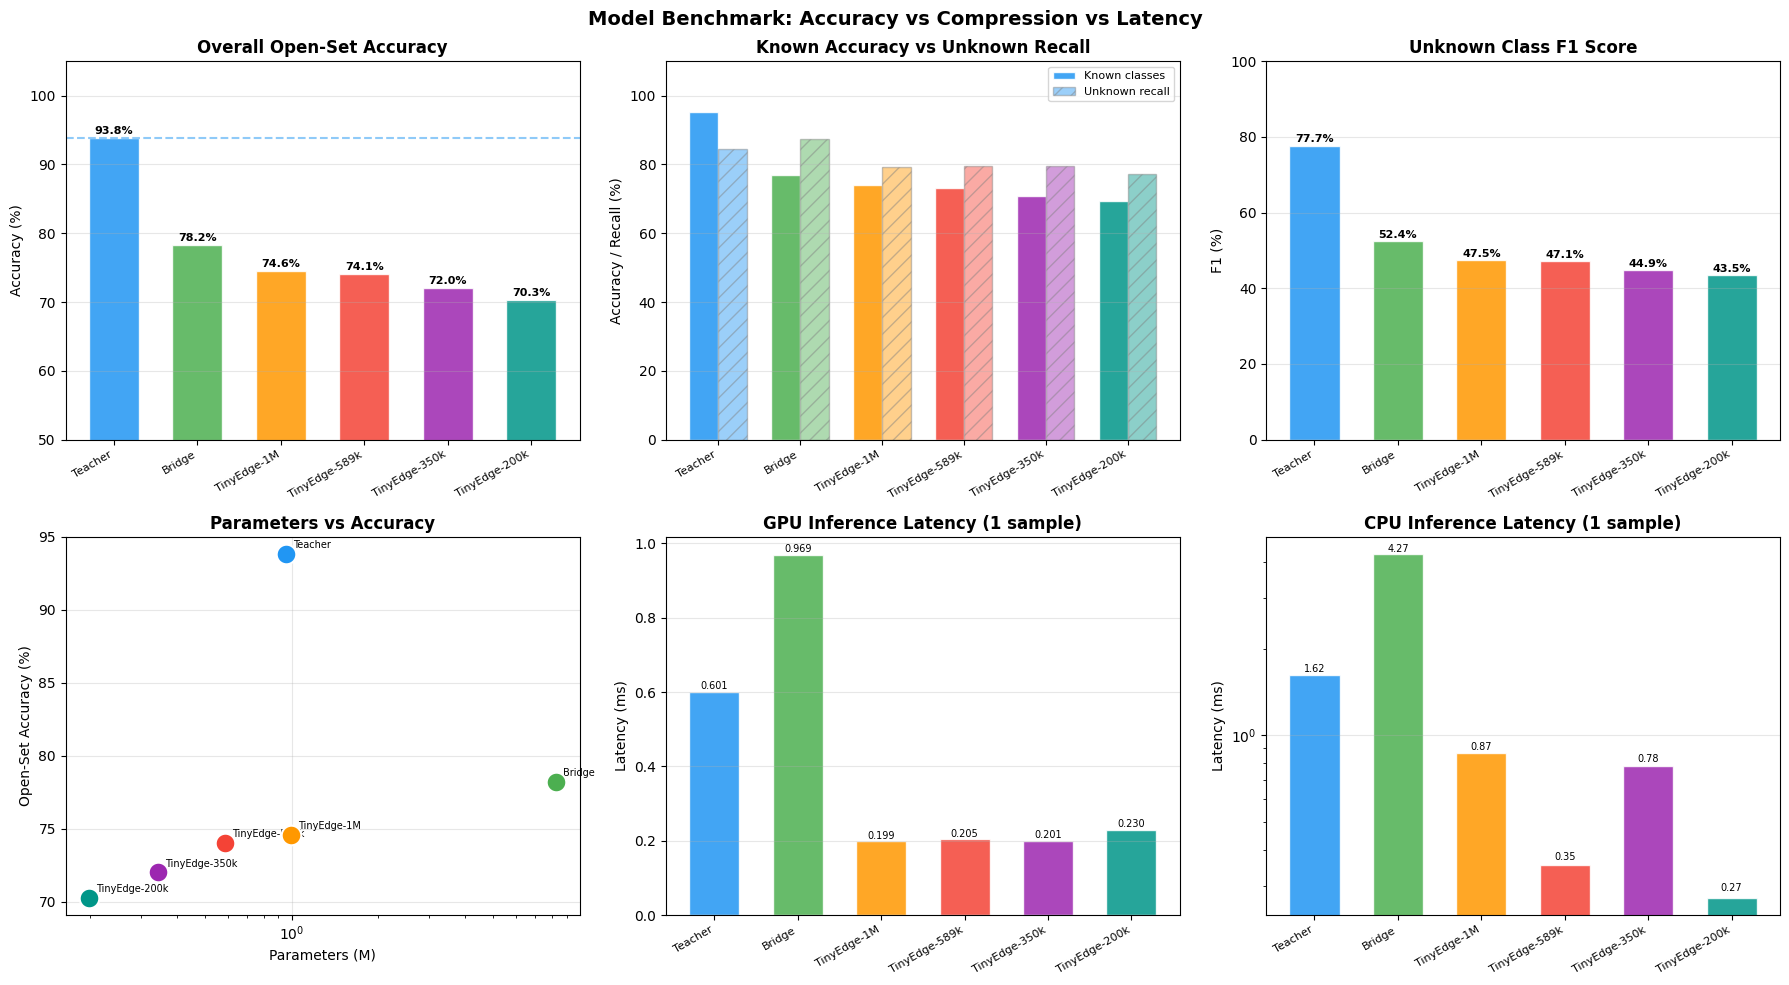

Plot saved → benchmark_comparison.png


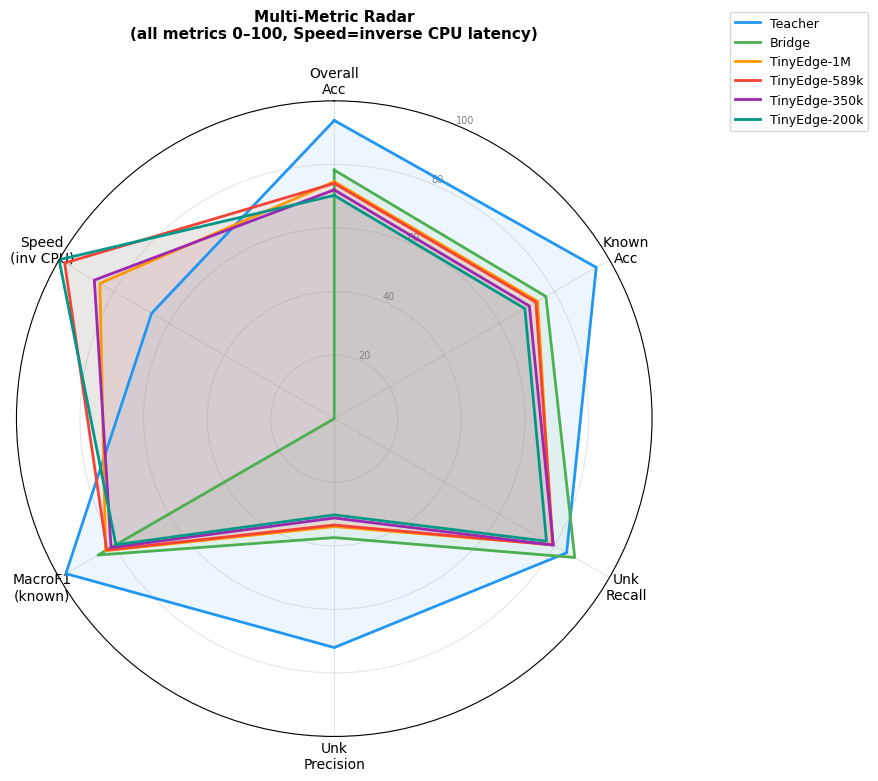

Radar chart saved → benchmark_radar.png


DEPLOYMENT RECOMMENDATION SUMMARY

  Criterion                    Winner                 Value
  -----------------------------------------------------------------
  Best overall accuracy        Teacher CNN            93.83%
  Best unknown detection       Teacher CNN            F1=77.7%
  Fastest CPU inference        TinyEdge-200k          0.272 ms/sample
  Best acc-per-param           TinyEdge-200k          3.5 acc/M params

  TRADE-OFF GUIDE:
  ─────────────────────────────────────────────────────────────────
  Edge MCU (< 256k params)  →  TinyEdge-200k
    No CNN needed at runtime. Flat spectrogram input only.
    CNN runs once offline to generate training signal.

  Edge SBC (< 600k params)  →  TinyEdge-589k
    Best balance of size and accuracy for Raspberry Pi / Jetson Nano.

  Mobile / Server           →  Bridge DNN
    Highest accuracy in flat-input family, full unknown detection.

  Reference / Offline       →  Teacher CNN
    Ground tr

In [ ]:
import time
import numpy as np
import torch
import torch.nn.functional as nnf
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
# FULL BENCHMARK — Teacher vs Bridge vs TinyEdge (4 sizes)
# Metrics per model:
#   • Overall accuracy (argmax, no threshold)
#   • Open-set accuracy (with tuned threshold)
#   • Per-class accuracy
#   • Unknown recall / precision / F1
#   • Inference latency (ms/sample, GPU and CPU)
#   • Parameter count & compression ratio
#   • Macro F1 on known classes only
# ══════════════════════════════════════════════════════════════════════════════

# ── Helper: run tune_threshold silently ──────────────────────────────────────
def _tune_T_silent(model, loader, unknown_idx, device, known_indices):
    """Tune threshold without verbose output."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch[1] if len(batch) == 3 else batch[0]
            labs = batch[-1]
            logits = model(x.to(device))
            kp = torch.softmax(logits[:, known_indices], dim=1).max(1).values
            all_probs.extend(kp.cpu().numpy())
            all_labels.extend(labs.numpy())
    probs = np.array(all_probs); labs = np.array(all_labels)
    unk_m = labs == unknown_idx; kno_m = ~unk_m
    best_T, best_h = 0.5, 0.0
    for T in np.arange(0.20, 0.96, 0.02):
        pu = probs < T
        ur = pu[unk_m].mean() if unk_m.any() else 0.0
        ka = (~pu[kno_m]).mean() if kno_m.any() else 0.0
        h  = 2 * ur * ka / (ur + ka + 1e-8)
        if h > best_h:
            best_h, best_T = h, float(T)
    return best_T


# ── Helper: full evaluation for one model ───────────────────────────────────
def _evaluate_model(model, loader_flat, loader_spatial,
                    unknown_idx, device, known_indices, class_names,
                    threshold, label):
    """
    Returns a dict with all metrics for one model.
    loader_flat    : DataLoader yielding (x_flat, labels)     — for bridge/student
    loader_spatial : DataLoader yielding (x_spatial, labels)  — for teacher only
    Pass None for the one that doesn't apply.
    """
    model.eval()
    all_preds_raw  = []   # argmax, no threshold
    all_preds_ths  = []   # threshold-based
    all_labels     = []
    all_confs      = []   # max known-class probability

    use_spatial = (loader_spatial is not None)
    loader = loader_spatial if use_spatial else loader_flat

    with torch.no_grad():
        for batch in loader:
            x      = batch[0].to(device)
            labels = batch[1]
            logits = model(x)

            # Raw argmax (includes unknown column for argmax)
            all_preds_raw.extend(logits.argmax(1).cpu().numpy())

            # Threshold-based
            known_logits = logits[:, known_indices]
            known_probs  = torch.softmax(known_logits, dim=1)
            max_prob, best_known = known_probs.max(dim=1)
            known_idx_t = torch.tensor(known_indices, device=device, dtype=torch.long)
            pred_known  = known_idx_t[best_known]
            final = torch.where(
                max_prob >= threshold,
                pred_known,
                torch.full_like(pred_known, unknown_idx)
            )
            all_preds_ths.extend(final.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_confs.extend(max_prob.cpu().numpy())

    preds_raw = np.array(all_preds_raw)
    preds_ths = np.array(all_preds_ths)
    labels    = np.array(all_labels)
    confs     = np.array(all_confs)

    n_total  = len(labels)
    unk_mask = labels == unknown_idx
    kno_mask = ~unk_mask

    # ── Accuracies ──────────────────────────────────────────────────────────
    acc_raw  = (preds_raw == labels).mean()
    acc_ths  = (preds_ths == labels).mean()
    known_acc_ths = (preds_ths[kno_mask] == labels[kno_mask]).mean() if kno_mask.any() else 0.0

    # ── Unknown metrics ──────────────────────────────────────────────────────
    if unk_mask.any():
        unk_recall    = (preds_ths[unk_mask] == unknown_idx).mean()
        unk_tp        = (preds_ths[unk_mask] == unknown_idx).sum()
        unk_fp        = ((preds_ths == unknown_idx) & kno_mask).sum()
        unk_precision = unk_tp / (unk_tp + unk_fp + 1e-8)
        unk_f1        = 2 * unk_recall * unk_precision / (unk_recall + unk_precision + 1e-8)
        false_reject  = unk_fp / kno_mask.sum()
    else:
        unk_recall = unk_precision = unk_f1 = false_reject = 0.0

    # ── Macro F1 on known classes only ───────────────────────────────────────
    known_true  = labels[kno_mask]
    known_pred  = preds_ths[kno_mask]
    macro_f1_known = f1_score(known_true, known_pred,
                               labels=[i for i in range(len(class_names)) if i != unknown_idx],
                               average='macro', zero_division=0)

    # ── Per-class accuracy ───────────────────────────────────────────────────
    per_class = {}
    for i, name in enumerate(class_names):
        mask = labels == i
        if mask.sum() > 0:
            per_class[name] = (preds_ths[mask] == i).mean()
        else:
            per_class[name] = float('nan')

    # ── Average confidence ───────────────────────────────────────────────────
    avg_conf_known   = confs[kno_mask].mean() if kno_mask.any() else 0.0
    avg_conf_unknown = confs[unk_mask].mean() if unk_mask.any() else 0.0

    return {
        'label'           : label,
        'acc_raw'         : acc_raw,
        'acc_ths'         : acc_ths,
        'known_acc'       : known_acc_ths,
        'unk_recall'      : unk_recall,
        'unk_precision'   : unk_precision,
        'unk_f1'          : unk_f1,
        'false_reject'    : false_reject,
        'macro_f1_known'  : macro_f1_known,
        'threshold'       : threshold,
        'per_class'       : per_class,
        'avg_conf_known'  : avg_conf_known,
        'avg_conf_unknown': avg_conf_unknown,
        'preds'           : preds_ths,
        'labels'          : labels,
    }


# ── Helper: measure latency ──────────────────────────────────────────────────
def _measure_latency(model, sample_input, device_str, n_warmup=50, n_runs=500):
    """Returns mean latency in ms per single sample."""
    dev = torch.device(device_str)
    model_dev = model.to(dev)
    x = sample_input.to(dev).contiguous()  # shape (1, flat_dim) or (1, C, H, W)
    model_dev.eval()

    # Warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model_dev(x)

    if device_str == 'cuda' and torch.cuda.is_available():
        torch.cuda.synchronize()
        start = torch.cuda.Event(enable_timing=True)
        end   = torch.cuda.Event(enable_timing=True)
        start.record()
        with torch.no_grad():
            for _ in range(n_runs):
                _ = model_dev(x)
        end.record()
        torch.cuda.synchronize()
        ms_total = start.elapsed_time(end)
    else:
        import time as _time
        with torch.no_grad():
            t0 = _time.perf_counter()
            for _ in range(n_runs):
                _ = model_dev(x)
            ms_total = (_time.perf_counter() - t0) * 1000.0

    model.to(device)   # move back to original device
    return ms_total / n_runs


# ══════════════════════════════════════════════════════════════════════════════
# BUILD LOADERS
# ══════════════════════════════════════════════════════════════════════════════

_flat_val_loader = DataLoader(
    TensorDataset(X_val_flat_torch, y_val_torch),
    batch_size=CONFIG['batch_size'], shuffle=False)

_flat_test_loader = DataLoader(
    TensorDataset(X_test_flat_torch, y_test_torch),
    batch_size=CONFIG['batch_size'], shuffle=False)

_spatial_test_loader = DataLoader(
    TensorDataset(X_test_torch, y_test_torch),
    batch_size=CONFIG['batch_size'], shuffle=False)

# Sample inputs for latency measurement
_flat_sample    = X_test_flat_torch[:1]                     # (1, flat_dim)
_spatial_sample = X_test_torch[:1]                          # (1, 1, 40, 40)

t_params = sum(p.numel() for p in build_teacher_cnn().parameters())

# ══════════════════════════════════════════════════════════════════════════════
# MODEL REGISTRY — teacher, bridge, 4 students
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("LOADING ALL MODELS FOR BENCHMARK")
print("="*70)

models_meta = []

# ── 1. Teacher CNN ───────────────────────────────────────────────────────────
_teacher = build_teacher_cnn().to(device)
_teacher.load_state_dict(torch.load(CONFIG['teacher_weights'], map_location=device))
_teacher.eval()
_T_teacher = _tune_T_silent(_teacher, _spatial_test_loader, unknown_idx, device, known_indices)
# Note: teacher uses spatial loader for latency but flat is irrelevant
models_meta.append({
    'model'    : _teacher,
    'name'     : 'Teacher CNN',
    'short'    : 'Teacher',
    'params'   : t_params,
    'spatial'  : True,
    'threshold': _T_teacher,
    'weights'  : CONFIG['teacher_weights'],
})
print(f"  Teacher CNN        : {t_params:>9,} params  T={_T_teacher:.2f}")

# ── 2. Bridge (Stage 2) ──────────────────────────────────────────────────────
_bridge = build_consistent_bridge().to(device)
_bridge.load_state_dict(torch.load(CONFIG['bridge_stage2_weights'], map_location=device))
_bridge.eval()
_b_params = sum(p.numel() for p in _bridge.parameters())
_T_bridge = _tune_T_silent(_bridge, _flat_val_loader, unknown_idx, device, known_indices)
models_meta.append({
    'model'    : _bridge,
    'name'     : 'Bridge DNN (Stage 2)',
    'short'    : 'Bridge',
    'params'   : _b_params,
    'spatial'  : False,
    'threshold': _T_bridge,
    'weights'  : CONFIG['bridge_stage2_weights'],
})
print(f"  Bridge DNN (S2)    : {_b_params:>9,} params  T={_T_bridge:.2f}")

# ── 3–6. TinyEdge students (4 budget levels) ─────────────────────────────────
_student_labels = {
    1_000_000 : 'TinyEdge-1M',
    589_000   : 'TinyEdge-589k',
    350_000   : 'TinyEdge-350k',
    200_000   : 'TinyEdge-200k',
}

for budget in CONFIG['stage3_curriculum']:
    _wpath = f"{budget}_{CONFIG['student_weights']}"
    _s = CompressibleEdgeMLP(
        CONFIG['flat_dim'], CONFIG['num_classes'], budget, dropout_rate=0.3
    ).to(device)
    _s.load_state_dict(torch.load(_wpath, map_location=device))
    _s.eval()
    _s_params = sum(p.numel() for p in _s.parameters())
    _T_s = _tune_T_silent(_s, _flat_val_loader, unknown_idx, device, known_indices)
    models_meta.append({
        'model'    : _s,
        'name'     : _student_labels[budget],
        'short'    : _student_labels[budget],
        'params'   : _s_params,
        'spatial'  : False,
        'threshold': _T_s,
        'weights'  : _wpath,
    })
    print(f"  {_student_labels[budget]:<18} : {_s_params:>9,} params  T={_T_s:.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# RUN EVALUATION & LATENCY FOR ALL MODELS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("RUNNING EVALUATIONS")
print("="*70)

results = []
for meta in models_meta:
    m = meta['model']
    print(f"  Evaluating {meta['name']} ...")

    if meta['spatial']:
        res = _evaluate_model(m, None, _spatial_test_loader,
                              unknown_idx, device, known_indices,
                              class_names, meta['threshold'], meta['name'])
        lat_gpu = _measure_latency(m, _spatial_sample, 'cuda' if torch.cuda.is_available() else 'cpu')
        lat_cpu = _measure_latency(m, _spatial_sample, 'cpu')
    else:
        res = _evaluate_model(m, _flat_test_loader, None,
                              unknown_idx, device, known_indices,
                              class_names, meta['threshold'], meta['name'])
        lat_gpu = _measure_latency(m, _flat_sample, 'cuda' if torch.cuda.is_available() else 'cpu')
        lat_cpu = _measure_latency(m, _flat_sample, 'cpu')

    res['params']    = meta['params']
    res['lat_gpu']   = lat_gpu
    res['lat_cpu']   = lat_cpu
    res['spatial']   = meta['spatial']
    res['short']     = meta['short']
    results.append(res)

# ══════════════════════════════════════════════════════════════════════════════
# PRINT MASTER COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════════

print("\n\n" + "="*110)
print("MASTER BENCHMARK TABLE")
print("="*110)
print(f"  {'Model':<22} {'Params':>9}  {'Compr':>7}  {'Overall':>8}  {'Known':>8}  {'Unk F1':>8}  "
      f"{'Unk Rec':>8}  {'Unk Pre':>8}  {'FalseRej':>9}  {'MacroF1':>8}  {'GPU ms':>7}  {'CPU ms':>7}")
print("  " + "-"*107)

for r in results:
    compr = f"{t_params / r['params']:.1f}×"
    print(
        f"  {r['label']:<22} {r['params']:>9,}  {compr:>7}  "
        f"{r['acc_ths']*100:>7.2f}%  {r['known_acc']*100:>7.2f}%  "
        f"{r['unk_f1']*100:>7.2f}%  {r['unk_recall']*100:>7.2f}%  "
        f"{r['unk_precision']*100:>7.2f}%  {r['false_reject']*100:>8.2f}%  "
        f"{r['macro_f1_known']*100:>7.2f}%  {r['lat_gpu']:>6.3f}ms  {r['lat_cpu']:>6.3f}ms"
    )

print("="*110)
print("  Columns: Overall=open-set acc | Known=acc on digit classes | Unk F1=harmonic(recall,prec)")
print("           FalseRej=known samples incorrectly rejected as unknown")
print("           MacroF1=macro F1 on 10 known classes only (ignores unknown)")

# ══════════════════════════════════════════════════════════════════════════════
# PER-CLASS BREAKDOWN TABLE
# ══════════════════════════════════════════════════════════════════════════════

print("\n\n" + "="*100)
print("PER-CLASS ACCURACY BREAKDOWN  (open-set, with threshold)")
print("="*100)

# Header
col_w = 10
hdr = f"  {'Class':<10}"
for r in results:
    hdr += f" {r['short'][:col_w]:>{col_w}}"
print(hdr)
print("  " + "-"*(10 + col_w * len(results) + len(results)))

for name in class_names:
    row = f"  {name:<10}"
    for r in results:
        v = r['per_class'].get(name, float('nan'))
        if np.isnan(v):
            row += f" {'n/a':>{col_w}}"
        else:
            tag = " ←" if name == class_names[unknown_idx] else ""
            row += f" {v*100:>{col_w-2}.1f}%{tag if len(tag) else ''}"
    print(row)

print("  " + "-"*(10 + col_w * len(results) + len(results)))
# Macro average row
avg_row = f"  {'MACRO AVG':<10}"
for r in results:
    vals = [v for k, v in r['per_class'].items() if not np.isnan(v)]
    avg_row += f" {np.mean(vals)*100:>{col_w-2}.1f}% "
print(avg_row)
print("="*100)

# ══════════════════════════════════════════════════════════════════════════════
# EFFICIENCY PLOT
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Benchmark: Accuracy vs Compression vs Latency', fontsize=14, fontweight='bold')

labels_plot  = [r['short'] for r in results]
params_k     = [r['params'] / 1000 for r in results]
acc_ths_list = [r['acc_ths'] * 100 for r in results]
known_list   = [r['known_acc'] * 100 for r in results]
unk_f1_list  = [r['unk_f1'] * 100 for r in results]
unk_rec_list = [r['unk_recall'] * 100 for r in results]
lat_gpu_list = [r['lat_gpu'] for r in results]
lat_cpu_list = [r['lat_cpu'] for r in results]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#009688'][:len(results)]
x = np.arange(len(results))
bar_w = 0.6

# ── Panel 1: Overall open-set accuracy ───────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(x, acc_ths_list, color=colors, width=bar_w, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, acc_ths_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Overall Open-Set Accuracy', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x); ax.set_xticklabels(labels_plot, rotation=30, ha='right', fontsize=8)
ax.set_ylim(50, 105)
ax.axhline(acc_ths_list[0], color='#2196F3', linestyle='--', alpha=0.5, label='Teacher')
ax.grid(axis='y', alpha=0.3)

# ── Panel 2: Known vs Unknown accuracy ───────────────────────────────────────
ax = axes[0, 1]
w = 0.35
ax.bar(x - w/2, known_list,  width=w, label='Known classes', color=colors, alpha=0.85, edgecolor='white')
ax.bar(x + w/2, unk_rec_list, width=w, label='Unknown recall', color=colors, alpha=0.45, edgecolor='grey', hatch='//')
ax.set_title('Known Accuracy vs Unknown Recall', fontweight='bold')
ax.set_ylabel('Accuracy / Recall (%)')
ax.set_xticks(x); ax.set_xticklabels(labels_plot, rotation=30, ha='right', fontsize=8)
ax.set_ylim(0, 110)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel 3: Unknown F1 ───────────────────────────────────────────────────────
ax = axes[0, 2]
bars = ax.bar(x, unk_f1_list, color=colors, width=bar_w, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, unk_f1_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Unknown Class F1 Score', fontweight='bold')
ax.set_ylabel('F1 (%)')
ax.set_xticks(x); ax.set_xticklabels(labels_plot, rotation=30, ha='right', fontsize=8)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# ── Panel 4: Params vs Accuracy (scatter) ────────────────────────────────────
ax = axes[1, 0]
for i, r in enumerate(results):
    ax.scatter(r['params']/1e6, r['acc_ths']*100,
               s=200, color=colors[i], zorder=5,
               edgecolors='white', linewidth=1.5, label=r['short'])
    ax.annotate(r['short'], (r['params']/1e6, r['acc_ths']*100),
                textcoords='offset points', xytext=(5, 4), fontsize=7)
ax.set_title('Parameters vs Accuracy', fontweight='bold')
ax.set_xlabel('Parameters (M)')
ax.set_ylabel('Open-Set Accuracy (%)')
ax.set_xscale('log')
ax.grid(alpha=0.3)

# ── Panel 5: GPU latency ──────────────────────────────────────────────────────
ax = axes[1, 1]
bars = ax.bar(x, lat_gpu_list, color=colors, width=bar_w, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, lat_gpu_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7)
ax.set_title('GPU Inference Latency (1 sample)', fontweight='bold')
ax.set_ylabel('Latency (ms)')
ax.set_xticks(x); ax.set_xticklabels(labels_plot, rotation=30, ha='right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel 6: CPU latency ──────────────────────────────────────────────────────
ax = axes[1, 2]
bars = ax.bar(x, lat_cpu_list, color=colors, width=bar_w, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, lat_cpu_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=7)
ax.set_title('CPU Inference Latency (1 sample)', fontweight='bold')
ax.set_ylabel('Latency (ms)')
ax.set_xticks(x); ax.set_xticklabels(labels_plot, rotation=30, ha='right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → benchmark_comparison.png")

# ══════════════════════════════════════════════════════════════════════════════
# RADAR / SPIDER CHART — multi-metric per model
# ══════════════════════════════════════════════════════════════════════════════

metrics_radar = ['Overall\nAcc', 'Known\nAcc', 'Unk\nRecall', 'Unk\nPrecision', 'MacroF1\n(known)', 'Speed\n(inv CPU)']
N = len(metrics_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig_r, ax_r = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax_r.set_theta_offset(np.pi / 2)
ax_r.set_theta_direction(-1)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(metrics_radar, size=10)
ax_r.set_ylim(0, 100)
ax_r.set_yticks([20, 40, 60, 80, 100])
ax_r.set_yticklabels(['20', '40', '60', '80', '100'], size=7, color='grey')
ax_r.grid(color='grey', alpha=0.2)

# Normalise CPU latency: fastest = 100, slowest = 0
max_lat = max(r['lat_cpu'] for r in results)
min_lat = min(r['lat_cpu'] for r in results)

for i, r in enumerate(results):
    speed_norm = 100 * (1 - (r['lat_cpu'] - min_lat) / (max_lat - min_lat + 1e-8))
    vals = [
        r['acc_ths']       * 100,
        r['known_acc']     * 100,
        r['unk_recall']    * 100,
        r['unk_precision'] * 100,
        r['macro_f1_known']* 100,
        speed_norm,
    ]
    vals += vals[:1]
    ax_r.plot(angles, vals, color=colors[i], linewidth=2, label=r['short'])
    ax_r.fill(angles, vals, color=colors[i], alpha=0.08)

ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax_r.set_title('Multi-Metric Radar\n(all metrics 0–100, Speed=inverse CPU latency)',
               size=11, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('benchmark_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Radar chart saved → benchmark_radar.png")

# ══════════════════════════════════════════════════════════════════════════════
# DEPLOYMENT RECOMMENDATION
# ══════════════════════════════════════════════════════════════════════════════

print("\n\n" + "="*70)
print("DEPLOYMENT RECOMMENDATION SUMMARY")
print("="*70)

# Rank by accuracy × (1/params) — accuracy-per-parameter efficiency
for r in results:
    r['efficiency'] = r['acc_ths'] / (r['params'] / 1e6)

best_overall  = max(results, key=lambda r: r['acc_ths'])
best_unk      = max(results, key=lambda r: r['unk_f1'])
best_speed    = min(results, key=lambda r: r['lat_cpu'])
best_eff      = max(results, key=lambda r: r['efficiency'])

print(f"\n  {'Criterion':<28} {'Winner':<22} {'Value'}")
print(f"  {'-'*65}")
print(f"  {'Best overall accuracy':<28} {best_overall['label']:<22} {best_overall['acc_ths']*100:.2f}%")
print(f"  {'Best unknown detection':<28} {best_unk['label']:<22} F1={best_unk['unk_f1']*100:.1f}%")
print(f"  {'Fastest CPU inference':<28} {best_speed['label']:<22} {best_speed['lat_cpu']:.3f} ms/sample")
print(f"  {'Best acc-per-param':<28} {best_eff['label']:<22} {best_eff['efficiency']:.1f} acc/M params")

print(f"""
  TRADE-OFF GUIDE:
  ─────────────────────────────────────────────────────────────────
  Edge MCU (< 256k params)  →  TinyEdge-200k
    No CNN needed at runtime. Flat spectrogram input only.
    CNN runs once offline to generate training signal.

  Edge SBC (< 600k params)  →  TinyEdge-589k
    Best balance of size and accuracy for Raspberry Pi / Jetson Nano.

  Mobile / Server           →  Bridge DNN
    Highest accuracy in flat-input family, full unknown detection.

  Reference / Offline       →  Teacher CNN
    Ground truth benchmark. Requires spatial convolutions.
  ─────────────────────────────────────────────────────────────────
  All models use open-set threshold tuned on validation set.
  Deploy with: evaluate_with_threshold(model, loader, class_names,
               unknown_idx, device, known_indices, threshold)
""")